# FLUX.1 [schnell] — DIMER E2E text-to-image QLoRA fine-tuning tutorial (standalone)

[![GitHub](https://img.shields.io/badge/GitHub-181717?style=flat&logo=github&logoColor=white)](https://github.com/kurtvalcorza/flux-schnell-generation-pipeline) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/flux-schnell-generation-pipeline/blob/main/tutorials/flux_schnell_generation_colab.ipynb) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-black--forest--labs%2FFLUX.1--schnell-ffcc4d?style=flat)](https://huggingface.co/black-forest-labs/FLUX.1-schnell) [![Upstream](https://img.shields.io/badge/Upstream-black--forest--labs%2Fflux-181717?style=flat&logo=github&logoColor=white)](https://github.com/black-forest-labs/flux) [![Licence](https://img.shields.io/badge/weights-Apache--2.0-blue.svg)](https://huggingface.co/black-forest-labs/FLUX.1-schnell/blob/main/LICENSE.md)

**Profile:** `E2E`  
**Mode:** `GUIDED`  
**Notebook specification:** DIMER Notebook Specification 2.2 — **standalone** (§4)  
**Capability:** few-step text-to-image generation with a 12 B-parameter rectified-flow transformer loaded 4-bit, held-out flow-matching-loss and CLIP-scored evaluation, and bounded QLoRA fine-tuning to a set of captioned photographs

**This notebook is standalone.** It carries the repository's package (3 modules under `src/flux_schnell_generation_pipeline/`, at revision `10a8ed527bd7`) verbatim in Section 2, the pinned model identity and the per-file SHA-256 manifest in Section 3, and the exact runtime pins in Section 1, so it keeps working after export even if the repository changes or disappears. Its only external dependencies are the pinned Python distributions and the Hugging Face Hub (the upstream identity is `black-forest-labs/FLUX.1-schnell`; the bytes are served by the ungated mirror `unsloth/FLUX.1-schnell` at `9df3faa7…`, see Section 3) at the immutable upstream revision `741f7c3ce8b383c54771c7003378a50191e9efe9` (~34335 MB, digest-verified before loading). It was generated by `tools/build_notebook.py` (build_notebook.py/2.1); edit the repository and regenerate rather than editing cells.

**Run all:** Selecting **Run all** in a fresh **GPU** runtime (a 15 GB T4 is enough; see the Prerequisites) builds an isolated environment from the hash-locked pins (torch, diffusers, transformers, peft, bitsandbytes, accelerate, sentencepiece, safetensors, huggingface-hub, numpy, pillow; the kernel's own packages are left alone, so no restart is needed), stages and digest-verifies two pinned snapshots — the 33.7 GB FLUX.1 [schnell] diffusers-layout snapshot (transformer, CLIP-L and T5-XXL encoders, tokenizers, VAE, scheduler), fetched from an ungated mirror and checked byte for byte against the manifest the repository committed, and a 0.6 GB CLIP scorer — fetches 60 CC0 iNaturalist bird photographs as digest-verified JPEGs (6 MB, no credential), validates them and splits them 36 / 12 / 12 by seed, encodes every prompt with the two text encoders and releases them, loads the 12 B transformer 4-bit (NF4) with an untrained LoRA adapter attached, scores the frozen model — the held-out flow-matching loss on the validation and test photographs, and six four-step generations scored by CLIP against their prompts and the held-out photographs, beside the same scores on the real photographs (a leave-one-out reference line) — runs a bounded QLoRA fine-tuning (3 epochs over 36 images), scores the adapted model on identical inputs, renders a new prompt, exports the adapter as safetensors with a manifest, releases the adapted transformer, reloads the artifact into a fresh 4-bit pipeline to verify parity, and releases that pipeline too. The default path needs no repository clone, no DIMER worker or service, no credential, no upload dialog and no configuration edit (NOTEBOOK_SPEC 2.2 §5). Measured times come from the previous notebook version, whose model stages are the same: a Kaggle Tesla T4 run took 2,912 s of cell time (2026-09-20) — 536 s staging the 34 GB of snapshots and about 36 minutes for Sections 4–9, 17 of them fine-tuning — with a pinned in-kernel install this version no longer does. Building the isolated environment (PyTorch with its CUDA libraries) comes on top and usually takes a few minutes (an estimate; no run of this version is recorded yet).

**Bring Your Own Data:** After the tutorial workflow completes, set `USE_BYOD = True` in Section 4, select that cell and choose **Runtime → Run after** to supply your own captioned photographs: a zip (or, with `BYOD_PATH`, a zip or a folder on any runtime) holding `captions.csv` (columns `id`, `file`, `caption`) and the image files (JPEG or PNG, shorter side 256..4096 px). **Minimum:** at least six distinct images, at least one caption with three or more images (it supplies the held-out records), and at least four records left for training — six images of one caption is the smallest dataset that works. Your records are split **stratified within each caption** (each caption with three or more images gives about 20 % to validation and test and keeps the rest for training) and flow through the same contract — validation, prompt encoding, frozen baseline, adaptation, held-out evaluation, generation, artifact export and reload parity. Section 5 first releases everything the previous pass left on the GPU (the transformer, the reloaded pipeline, the scorer), so the text encoders fit again, and Sections 6 and 7 start from the pretrained base. The expected schema, the limits and the privacy guidance are stated in the Prerequisites and in Section 4, and uploaded files stay inside this runtime. BYOD is optional and never part of the default path.

FLUX.1 [schnell] (Black Forest Labs, 2024) is a 12 B-parameter rectified-flow transformer distilled to render an image in one to four sampling steps with no classifier-free guidance. A CLIP-L encoder gives one pooled vector, a T5-XXL encoder gives 256 token embeddings, 19 double-stream and 38 single-stream transformer blocks predict the *velocity* of a 16-channel latent — the FLUX VAE's 8× compressed image, packed 2×2 into 64-channel tokens — and the VAE decodes the latent to pixels. Everything comes from one 33.7 GB snapshot in the diffusers layout, plus, for evaluation only, a CLIP ViT-B/32 scorer.

Three things about this row are handled in the open. **The transformer does not fit a 16 GB GPU in any 16-bit format** (23.8 GB as shipped), so it is loaded 4-bit — bitsandbytes NF4 with double quantisation, float16 compute — at about 6.6 GB, and the LoRA is trained over that quantised base (QLoRA); the frozen numbers are therefore the 4-bit model's numbers, not the bfloat16 checkpoint's. **The text encoders (9.7 GB in float16) do not fit beside it**, so Section 5 encodes every prompt the notebook will ever use once, keeps the embeddings, and releases both encoders before the transformer loads; the reloaded pipeline in Section 9 adopts the same embeddings rather than loading them again. **Generation has no ground truth**, so the notebook reads three kinds of number and says what each is: the held-out *flow-matching loss* (the training objective, measured on photographs the model never trained on, with identical noise for the frozen and the adapted model), CLIP scores of generated images (prompt alignment, which species CLIP thinks it sees, and closeness to the held-out real photographs), and the same CLIP scores on the real photographs themselves — a **reference line, not a ceiling**: each photo is compared with the other held-out photos of its species, never with itself, and generated images can score above it. None of these is a human judgement of image quality.

**Who this is for.** A learner who knows basic Python and PyTorch, has met the idea of a train/validation/test split, and wants to see how a large pretrained image generator is adapted to a narrow domain and measured honestly when there is no ground truth: a loss on held-out photographs, instrument readings from a second model, a reference line from real photos, and an adapter that reloads with verified parity. No prior experience with diffusion or flow models, quantisation or LoRA is assumed; each term is explained where it is first used and again in the **Glossary** at the end. A CUDA GPU of at least 15 GB is required.

**Input → Model → Output.**

| | Generation (Sections 6, 8, 9) | Adaptation (Section 7) |
|---|---|---|
| Input | a text prompt (a caption of 1..1000 characters) and a seed | captioned photographs `id`, `image`, `caption`, split into training, validation and test |
| Model | FLUX.1 [schnell], 4-bit transformer + VAE, prompts pre-encoded by CLIP-L and T5-XXL; four Euler steps, no guidance | the same 4-bit transformer with a rank-8 LoRA on the image-stream attention projections; only the LoRA is trained |
| Output | a 512 × 512 image, scored by a separate CLIP model: prompt similarity, nearest caption, similarity to the held-out photographs | the held-out flow-matching loss before and after, the same CLIP scores before and after, and a 37 MB safetensors adapter that reloads with identical results |

**How to use this notebook.** Choose a GPU runtime (Colab T4 or better), then **Runtime → Run all**. Sections 1–3 are **infrastructure** — the isolated environment, the carried code and the model verification — and can be run without study; their code is collapsed. The learning path starts in Section 4. Form fields (`# @param`) are the only values meant to be edited; the defaults reproduce the default path. Each learner section asks you to **predict** before it runs; the next section opens with **What to notice** and a collapsible **Check your reasoning** block with a worked answer from a recorded run. Each optional experiment names the field to change and the cell to re-run from (**Runtime → Run after**). Section 10 is a **change-one-thing activity**, off by default. **Troubleshooting**, a **Glossary** and a **Conclusion** template are at the end. Your notes are optional.

**Roadmap:** *core concepts* — 4 a captioned dataset and its split → 5 prompts become embeddings, and the encoders leave the GPU → 6 the frozen model: a held-out loss, CLIP readings and the real-photo reference line; *evaluation practice* — 7 bounded QLoRA fine-tuning → 8 the paired held-out comparison; *engineering* — 9 a new prompt, export, reload parity → 10 **change one thing: the number of sampling steps** → conclude.

**Learning objectives:** by the end you should be able to (1) explain why the text encoders and the 4-bit transformer take turns on a 16 GB GPU, from the memory figures Section 5 prints (Section 5); (2) say what the held-out flow-matching loss measures and why the frozen and adapted values are a paired comparison (Sections 6 and 8); (3) read a CLIP prompt similarity, a nearest-caption accuracy and a reference similarity, and say why the real photographs are a reference line, not a ceiling (Section 6); (4) state which parameters QLoRA trains and how the kept epoch is chosen (Section 7); (5) judge from the per-caption rows what six generated images per model do and do not show (Section 8); (6) check that an exported adapter reproduces the evaluated model (Section 9); and (7) predict, measure and explain how the number of sampling steps changes the CLIP readings (Section 10).

**This notebook does not demonstrate:** FLUX.1 [dev] or [pro], guidance-distillation or classifier-free guidance (schnell has none), ControlNet, inpainting or image-to-image conditioning, resolutions other than 512², full or 16-bit fine-tuning, DreamBooth identifiers, safety filtering of prompts or images, human preference or FID/KID benchmarks, prompt engineering, and any claim that a CLIP score or a flow-matching loss measures image quality. The repository exposes none of these.

## Prerequisites

- **Learner:** basic Python and PyTorch; what a train/validation/test split protects against. The notebook explains rectified flow, velocity, noise levels, the flow-matching loss, latents and the VAE, NF4 quantisation, LoRA and QLoRA, CLIP scores, the leave-one-out reference and reload parity where they are first used; the Glossary repeats them.
- **Runtime:** a fresh **Linux x86_64 GPU** runtime — Google Colab T4 or better, Kaggle, or a Linux Jupyter server with a CUDA GPU of at least 15 GB. Section 1 builds its own Python 3.12.12 environment from a hash-locked list of manylinux wheels, so the kernel's own Python version does not matter, and a Windows or macOS kernel is not supported (Section 1 stops with that message). The CLIP-L and T5-XXL encoders run in float16 (9.7 GB) while they encode prompts and are then released; the transformer is loaded 4-bit (NF4, about 6.6 GB) with float16 compute and the LoRA parameters in float32; the FLUX VAE stays in float32 (0.34 GB). CPU-only runtimes are not supported: bitsandbytes 4-bit needs CUDA and the 12 B transformer would need 48 GB of RAM in float32. **Disk:** about 36 GB for the two snapshots plus several GB for the isolated environment (PyTorch with its CUDA libraries). **Host RAM:** every model load streams its weights to the GPU one tensor at a time (`device_map`), so a standard Colab VM (12.7 GiB) is meant to be enough; this repository's capstone notebook ran the same loading pattern on such a VM, but this notebook has not yet been run on Colab.
- **Knowledge:** what a latent diffusion or flow-matching model does at inference (noise → latent → image), why a distilled few-step model uses no classifier-free guidance, what 4-bit weight quantisation changes, what a LoRA adapter changes and what it does not, and why a training loss is not a quality score. Each is explained again where it is used.
- **Weights:** the transformer, both text encoders, the VAE and the CLIP scorer are all safetensors; nothing is unpickled and no Hub-hosted code is executed — the model classes come from `diffusers`, `transformers`, `peft` and `bitsandbytes` on PyPI. FLUX.1 [schnell] is released under the Apache-2.0 licence; the scorer is MIT. The upstream Hub repository is gated by a click-through, so the bytes are fetched from an ungated, unmodified mirror and verified against the manifest committed in this repository (Section 3).
- **Data contract:** a record is `{id, image, caption}` — an RGB image with shorter side 256..4096 px (resized so the shorter side is 512 px and centre-cropped to 512 × 512; the crop is reported) and a caption of 1..1000 characters (truncated to 256 T5 tokens and 77 CLIP tokens; T5 truncations are reported). Validation is structural: nothing checks that a caption describes its image or that the model can render it.
- **BYOD file (Section 4):** a zip holding `captions.csv` (header `id,file,caption`, UTF-8) and the images; a `file` value is the image's path inside the zip (relative to the archive root or to the folder holding `captions.csv`) or, when unique, its file name. On Colab the upload dialog opens; on any runtime set `BYOD_PATH` to a zip or a folder instead. **Minimum:** six distinct images, at least one caption with three or more images, and four records left for training — six images of one caption is the smallest dataset that works. Pixel-identical duplicates are dropped and reported by id. Generation and scoring use one image per distinct training caption, capped by `MAX_GENERATION_PROMPTS` (12) in Section 6 with a printed warning. Your test captions are written to `outputs/flux_schnell_generation_byod_captions.csv` (the sample's to `outputs/flux_schnell_generation_sample_captions.csv`, which also shows the expected shape).
- **Privacy:** Do not upload confidential or restricted data to a hosted runtime unless you are authorized to process it there — photographs of identifiable people, licensed stock images or client material are exactly that. The default path uploads nothing.
- **External access (data):** besides the Hub, the default path fetches 60 pinned photographs (about 6 MB) from the public iNaturalist open-data bucket `inaturalist-open-data.s3.amazonaws.com` over HTTPS, digest-verified before decoding; every photo is CC0 and its observation page is recorded.
- **External access:** the Hugging Face Hub (the upstream identity is `black-forest-labs/FLUX.1-schnell`; the bytes are served by the ungated mirror `unsloth/FLUX.1-schnell` at `9df3faa7…`, see Section 3) only, to fetch the pinned `black-forest-labs/FLUX.1-schnell` snapshot (~34335 MB in total) at revision `741f7c3ce8b3…`. No repository access and no credentials are required; nothing is installed from this repository. The isolated environment also needs PyPI (`pypi.org`, `files.pythonhosted.org`) for the pinned `uv` wheel and the 69 hash-locked packages, and the managed CPython 3.12.12 build (python-build-standalone) that `uv` downloads.

## 1. Install the pinned runtime (isolated environment)

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

Hosted runtimes such as Colab import some packages, NumPy among them, before the first cell runs, and Python cannot swap a module that is already loaded. Installing the pins into the notebook's own Python would therefore leave mixed versions or require a manual restart. Instead, the next cell builds a separate environment (`dimer_isolated_env/`) and leaves the kernel's packages untouched: it downloads the pinned `uv` 0.12.15 wheel and refuses it unless its size and SHA-256 match, has `uv` install the managed CPython **3.12.12** (whatever Python the kernel itself runs), and installs the 69 packages of the carried hash-locked requirements (`tutorials/requirements-colab.lock.txt`, compiled from the pins below) with `--require-hashes --only-binary :all:`, so every package, direct or transitive, is the exact file that was locked. No repository code is installed. The lock holds manylinux x86_64 wheels, so the notebook supports **Linux x86_64 runtimes only** (Google Colab, Kaggle or Linux Jupyter); on any other platform the cell stops with that message. The printed dictionary names the isolated Python version and the kernel's.

In [ ]:
# @title Infrastructure: install the locked runtime into an isolated environment
# dimer: kernel cell (runs in the notebook kernel, not in the isolated environment)
import hashlib
import io
import os
import platform
import subprocess
import sys
import time
import urllib.error
import urllib.request
import zipfile
from pathlib import Path

PINS = [
    'torch==2.14.0',
    'torchvision==0.29.0',
    'torchaudio==2.11.0',
    'diffusers==0.40.0',
    'transformers==5.17.0',
    'peft==0.21.0',
    'bitsandbytes==0.50.2',
    'torchao==0.18.0',
    'accelerate==1.15.0',
    'tokenizers==0.23.2',
    'sentencepiece==0.2.2',
    'protobuf==7.36.2',
    'safetensors==0.8.0',
    'huggingface-hub==1.32.0',
    'numpy==2.5.3',
    'pillow==11.3.0',
]
MANAGED_PYTHON = '3.12.12'
UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_BYTES = 20081404
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
LOCK_NAME = 'requirements-colab.lock.txt'
LOCK_SHA256 = '6dc87c5f18d98092103e017d218c30c6b00c55a1bd99409c1c1df64ec5100c57'
LOCKED_PACKAGES = 69
# The hash-locked requirements, compiled from the PINS above with `uv pip compile --generate-hashes` for manylinux x86_64.
LOCK_TEXT = r'''# This file was autogenerated by uv via the following command:
#    uv pip compile pyproject.toml --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: -o tutorials/requirements-colab.lock.txt
accelerate==1.15.0 \
    --hash=sha256:5654f8c5eaa0d4fa68b33e287a97765da6849bf6d51dcac874e73fbbddfb6134 \
    --hash=sha256:97eacca0b73e45cb867dbf8c5d5d4dc32219544300e0c8992c7334dc2ef33cec
    # via
    #   flux-schnell-generation-pipeline (pyproject.toml)
    #   peft
annotated-doc==0.0.5 \
    --hash=sha256:117bac03a25ede5df5440e855b32d556049ca169ead221505badf432fed4b101 \
    --hash=sha256:c7e58ce09192557605d8bbd92836d7e1d520ac9580096042c0bfd197efacf1bb
    # via typer
anyio==4.15.1 \
    --hash=sha256:6152fdbbf9a77fdec97731721bebf7c4c44f7c29b424b0065826173efc7ed101 \
    --hash=sha256:9f28306018cbd6d329e64a36d58256edff76dd996fe423bc957326e578b82a94
    # via httpx
bitsandbytes==0.50.2 \
    --hash=sha256:4311f52a880b341bada639e4edd1a3c8d786830c9c93cdde29eaa1f062c8f8e5 \
    --hash=sha256:55348a9a4a21bfd99cf8c7b32fe67b4030ae5c2a05738e03c1747f65fa6ec283 \
    --hash=sha256:8437ab68a04ea56daf1d6ecb54230fb1d88be4b89fe2d79bc399bc0203b487cf \
    --hash=sha256:c697963c8fda3dcd0d7ebd9b5211ae4067feef7cd06e0350d4e816a434fe683d \
    --hash=sha256:d5772560dd94c4d9c57f50c9b017450a1707f7687bfd4b3dc86f7342aafe721e
    # via flux-schnell-generation-pipeline (pyproject.toml)
certifi==2026.7.22 \
    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \
    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55
    # via
    #   httpcore
    #   httpx
    #   requests
charset-normalizer==3.5.2 \
    --hash=sha256:01077390b03f7988f11d700a2194e69b119741a86b1a638b1db88891e3eced8e \
    --hash=sha256:01b0c0d2262a9e28e8484a278c7e1b5d650e3ac8cf2683d2967e25899f208bdf \
    --hash=sha256:04851f73ae72b8413dddadb16a49dfee95263553741fd42d546f7d66907e6be5 \
    --hash=sha256:0521c5665880b33d603717defa76c094048900010897909952397feb3039da56 \
    --hash=sha256:0774bf9bf620249fee3e0b8b9fd3065de213be30f3aa94ce2494b3b638949e26 \
    --hash=sha256:0891b9d3903c5571c03771ca669a4b0ec5618ca722a5c957d3d29cd4e5062848 \
    --hash=sha256:0c951d5e6dd9c2ff60609476752bee49da4206adde960ebc247766937f72e718 \
    --hash=sha256:0fed1d06615f022ee3b13caf5e8b180cfea32bb2c5aded8a9d44277afc040f93 \
    --hash=sha256:114e4d0c92d618409ed82a99e22b5c5e768fe995f2973f78265f4524f49d4640 \
    --hash=sha256:11912e4bb14baae7c5d8791aa55ba0a3a03ec6729073307b0f57270abaa713d3 \
    --hash=sha256:11a4d68a6ecda3292cb1e50239e111543ba5d709bb62a6b4ea1afcfa729d8875 \
    --hash=sha256:124fbf1a8ff966d87ae05bb8bd45a71f966055ed8bba320d0c7cf450bc5f4d0e \
    --hash=sha256:1461ac396c4fdb983a675f20aa555624f0ee18ac83d832b9244ffff3d8055275 \
    --hash=sha256:1503bccbeb36d5527790c3930327704c39af22de3112f1b1666a9f3ce15ee204 \
    --hash=sha256:15bb4005af6320d259dc7593ca84a38d7fe06a421dbcf7b910ae23979101e787 \
    --hash=sha256:15c44f7edfd477b06f517a5cc317fc1707edb9de2c865f43d4b6513907473234 \
    --hash=sha256:16fa0eccf81304b79c5cd87f9271c3b85dd9dd99245e4422ae9c0dd45e0f99d3 \
    --hash=sha256:183b88127acdb4fabe59d951ab424faf1af7b63cdbb5f776186c1ea2ffcaed98 \
    --hash=sha256:195c26fb65950f8fce54e26349852b7bdd7c5f120aeefbcc440b8a20faaed4a3 \
    --hash=sha256:1afb975bd5d68d5ce9f6b6d44fdf2f7e34b895a35e95708a7a91b20a3b51d187 \
    --hash=sha256:1b4cbc7c3491ccb4aa17fcd8165649d01cf39f76de1696da8631b5f71b85401d \
    --hash=sha256:1bc0baf5ef96b6ede57d47f4b8fe4d9d84019c3bfcbeb20a41edc6a6ee341f1f \
    --hash=sha256:1c50fe28bbc2ced33386f298650d91218076c05420e6cbd790b913adc41659e7 \
    --hash=sha256:1db38f4c5496827c1a501846d64d14c3b80c7e6714e406cd7dc36a9899fa1011 \
    --hash=sha256:211d5a3eb6af8f513b8d4ca19a8c1b7accab1b5f0d3175f9826b03c1a920dc1f \
    --hash=sha256:23851fb4e1b85ed3f6c2a27b777cdfe2e19fb5b38429a8faf38c7542b7665869 \
    --hash=sha256:254eb48b9fa5ee9898a3c445825a1f340fe53712a098904b39b0bddba8ea3cb1 \
    --hash=sha256:2625388c6c754520c37abaf3b41eb34d1cc4a373f457898f08606c8e362b891d \
    --hash=sha256:281cb91036248400f4cc957495cccd44c275c2e0c5854f7e45ac5cf7dc193847 \
    --hash=sha256:28a15fdad492a99b6eccfaaed66ef3f74050680545ea61ec8b2f4c538f1f1320 \
    --hash=sha256:28b4f0d66fb834ff90f28209ac7bce77868c45d8c93e26f906709d9b7c2e1af9 \
    --hash=sha256:2a925889534b3748302dae5dead07cc13480de1dac3aea80a941b729b471ef93 \
    --hash=sha256:2b7b3bbfb4fe8ef40600792d762fbaa9057559f9d3fad209525b7a22b99e91fd \
    --hash=sha256:2c9ad19a6cfcd5ea5c0d41161d22f9df1dcc277e9bef2751391334546a314c00 \
    --hash=sha256:2cc961b171b3f3440f410489ab3573e86aea8736134ebbb40ea1338b7f0831bc \
    --hash=sha256:2ce45c6627b22c47e390bc91a41c3d13032192e699fa0bea96e9671b373d69b0 \
    --hash=sha256:2e06a3a98f916dd41d27f3105e02e7a40181c98c94b9158733d03a6f80506c09 \
    --hash=sha256:304d5463e65a35d7bb0850550e0780395395f6fcf452f04db7d5ca7cecc425ac \
    --hash=sha256:304d8e4d493af723536393eee0c689eb7813f4a474c8b479dee63f1fdd98f621 \
    --hash=sha256:30fcd120b732aa79317f08dee04d7de0847822e4cf7ee0e9f445bb958832252c \
    --hash=sha256:31f3930700408d211f13378ccbe1c40845d8da54bd0681fac3a9b5aae81c7aa8 \
    --hash=sha256:34276fd796040bf0993ab33a369aa572e6979c7aab225a88893667ad8eac8f7a \
    --hash=sha256:355ad8011081dec5412240c087a9a0c9d4d5039f3ed11a3f13e18c2b29b56c51 \
    --hash=sha256:38a873987f3be698494da8b2e3085e29da02da7b633dce73e79c699a113d7bf0 \
    --hash=sha256:39de2a259fc954455c57274dc94c79d5842774e1247a016aff30bc0efed0f4ef \
    --hash=sha256:3d14b50de6bf4d0edf857a9386836846f982b8f524e188e2e68b96d702bcf4aa \
    --hash=sha256:3d21b8b13c7592db2ac5e544a6d83187b995257472b0c9e8351b6d507ae37ed6 \
    --hash=sha256:3d31298449090ab8d47b7b1b2a555ff73cac7ed438a08b7ac160980c7ebed649 \
    --hash=sha256:3ddacd27458c45bdacd6bd6db644bfb730efbf9e830310186e3045c9c5be8fb2 \
    --hash=sha256:3df041de8887954562c9b261cba85ca0e9ded74048daf125f45edcfaa4832229 \
    --hash=sha256:40ab6bffa02ae10a0581e6c198be7d2d8ca5c2a0c64e4ed3465d766df457573e \
    --hash=sha256:4275811936e2f06feff5e598fb42a1b7ae852da8e39605211892b56b81a34efd \
    --hash=sha256:443eae2bf318abeaf6f15d785138f71fd6de770e99a92158b8b814265e079115 \
    --hash=sha256:447441e76ec720b15e64418d32e092297340387053047c7c694f579efb0ee1d9 \
    --hash=sha256:4495c5002a7b28557e7e222e77e0b661183e432b7d6d2e788101e3f240e05b8c \
    --hash=sha256:44bd4fbb29dfbeba60e7d2bd000c59e4b21ddb3cc53912b14048d37092706d7c \
    --hash=sha256:4685902cf26edf013ed7a3da0f426ebba7a00ebb9541386d835afbf002c11cab \
    --hash=sha256:498dc3188ca05a68231ac3fdbfc7f57eb67e1343c30e0fea17f8218c1599b253 \
    --hash=sha256:4c2b5031f63e331e3839b40aed2dd6f191e9c07edbde303e7876846ea1946995 \
    --hash=sha256:4d48f2d08b9de5864e2c8744d4461b862fb149a18274abc8b698c45975573438 \
    --hash=sha256:4f87960d57feabfb618e4e0af6e7371645fa26a277860739d6e5d6e0012c92f0 \
    --hash=sha256:50e3adfb96fc189eb27b1cf62d3b598b89b4bb0420d93a3d3e42e137409011be \
    --hash=sha256:51cf45226a9b588d0d2b4880c62d686934b63ab0bd79ca23ab0e9762eb27441b \
    --hash=sha256:52aa6992700996af31f375de0c6bacd402b0097fe40b53c426b9f51a90ebabc7 \
    --hash=sha256:55ea99acb17b9325618de155a0cd6a2e8f5d10be008113e1d433bbb58db543b2 \
    --hash=sha256:56bc200a365efb37383b7852e4cc5898d3b2da5987289b543956cf8cad71018a \
    --hash=sha256:588461c2e8384d309bd63e5826019b6977bc66d629b99ac8737bb795d7b2cb5a \
    --hash=sha256:58ca3755ee7ff7f59b57789ec9833c9de9ea275405cdd240eda1f193112e398a \
    --hash=sha256:58f361dcbab699cf8f42db3f47c8e7fd1036f138c23a5d08de9fde5f425a730c \
    --hash=sha256:598a11a2c7ebaa5334bf698bf29568c9c390abac6a154d8170fedecd1cea38c5 \
    --hash=sha256:59f63901b0031c3136cf64704dcb21de0bbae62ce2c9529bc39d27665463de37 \
    --hash=sha256:5cde776b7cc66e4f6c99612cea4aa7269aa65863f7a15841b2c264f103822f4e \
    --hash=sha256:5e2b6b57e9733d39f0c9fd3185efa6b8e29652c4cd8fe94180272cf6ed9a78c4 \
    --hash=sha256:5fb29fb8cd1a46c27a1bf9613ad5ec2599310d46b4025d9556404a6b6a292800 \
    --hash=sha256:6045373d5a89a5ec71afde535db987ca28e76dfa276c2d4c818265b375d4b055 \
    --hash=sha256:619799369eeef6366ed3e8755a5670f4f2f0fb6b30a0fd7264dc0fdc2357058e \
    --hash=sha256:62588a277bfb59def052abd940703fa35107152bf479781a878617d60faf8fb5 \
    --hash=sha256:62603db9a7caa0802eaa28c1c46fecd7b3a263a774069c24c3c28c302448721c \
    --hash=sha256:65cd72beeeca9d3aaea1201e5923859f308f952f9c71de93f06063c79f0f7a3b \
    --hash=sha256:68eb192d85ab8e5f6ec69c2bc6ac0179fbf04a5ac1569d12fbef74883fe102d0 \
    --hash=sha256:6bd128f206a7752ae1f2ab6c61bf8a24ba28913a10df8b14c2637b973ff97a80 \
    --hash=sha256:6be488a102b8cf28d0391d8c4ba7748938ae28b78ad901f8585520fca33ead1a \
    --hash=sha256:7218e8f32b0956cfcd048fd42d9d5779809745ca1d86113ca56f66e7ae1549c4 \
    --hash=sha256:7441d755b7ab94f8d4eb3e43ec05482d760842fd263d003a99102d742cd835e2 \
    --hash=sha256:749e97e1b32313717a565abbe321bc2190bc8b35f1a67e4cdbc7c56c8d8ffe58 \
    --hash=sha256:75a3ceed0724d625d64b86ca20aba182e4df462e04c2414fc941c0f523f06aac \
    --hash=sha256:780fbe7cab297b81dad9fb8dc5eb003c0468ffb0d9e5f65068c53a34661a96bc \
    --hash=sha256:78456a747de8dc58360ffa581f30a002baf5aa28cb262536545e91f113ed7639 \
    --hash=sha256:7967d08cf06dee78443b874f98c98036f624f3a4e73e11f9f64f5be4d25393cf \
    --hash=sha256:7a881931aa470808df94a8c380eed2bbbc76cd9dc622310f99665658c821eb6d \
    --hash=sha256:7dcd882da75ef9adf94903b1e3b9419e8aa8fb4c7396822b834b9ef7fb96954f \
    --hash=sha256:7e841fb9010836c992c9f12fcbd43a831de93a5f726fc1ccd8ca1d0268c5014c \
    --hash=sha256:7fdde2c9fd9e3eca40631e024664cf2584272cc8f96308cbe5fdfc930f51d8bc \
    --hash=sha256:8024d00c3faf3fc0c16e07a69f4405e8eac7cc0ab15f65fe6cf43827c4cf72b4 \
    --hash=sha256:80d02b6f04e92601a081dd97b23d3128033098bff5d35d392ddcc0476ea11253 \
    --hash=sha256:838dcc90063569a0448120554591a1d6c4a4ffe11babf048908793154ab86ade \
    --hash=sha256:849df64e889b2e17230d58410a03dba311a65b163508fd33679b2b737d4b7858 \
    --hash=sha256:87475fabc8d9996fd9c27debb395e642e8c838d78a00b6e932227a0e06b81e26 \
    --hash=sha256:87e50a3e7cb90af586b6c5faf23e302a970415ac73bd7bd90a515a04b427ef96 \
    --hash=sha256:89b53f3cda69831909888e0494f4fa0bcd3537e3e138dabeb620bd6ad946bae8 \
    --hash=sha256:8a893cc101149f80a653f82062ebc95b34525a2614382e1da5458fe7c6997249 \
    --hash=sha256:8b2bfab86aa71ae13aa41a6a26aab338e0db2b8bc75434b05aea89e011ff35a4 \
    --hash=sha256:8d86d6fc60743dc916eb79e2eb1ec4818e21e427731543af40a3021851174a13 \
    --hash=sha256:915563965d418f986e7e145accc592eae9e1a1be3566ff98a05d7a9ec42a76e1 \
    --hash=sha256:92888bb3187c5ba50500b00b3b310c9f2c651709d28036077680cb5255450a03 \
    --hash=sha256:93223adc95033dd47133a46ccfc316a0139176fd79085762e27202ec56018f03 \
    --hash=sha256:9373ad13ef0d2c0fb761e04e55bfdee5a08b52cef2c882c8fbe9935b1517152e \
    --hash=sha256:9409a8bf35cf78353942504b24a57de3d75b708997a1e4bd8db71ac8633ce364 \
    --hash=sha256:9b7f416ff0978e2f2249330527f0ad6fa02f4932e6199692d3b52da2048c19e4 \
    --hash=sha256:9bde855991b7e362c146535e3136a50bfaffc0487d38b33ca7e5edefc6e23849 \
    --hash=sha256:9cae88599c7219005d879f98e5ed53341e9a122af585e1091200358a3003d2a0 \
    --hash=sha256:9cf9b1a857e25c4baceeb3624e92a56df3668f398c4acba74e174d81fb4d1d3a \
    --hash=sha256:9f56f72050826f63dcee7a7f55b0a77168cb3bfc553fd405e7f8f9ece75a4036 \
    --hash=sha256:a090bb2c68df85450502e3e20d665e3a5af9c65a84d6508ed477badd49166fd3 \
    --hash=sha256:a192e2c40070d92c3ccf777e3a5c4ff515573cd2bb7ed0c537fdadbbec5bbf21 \
    --hash=sha256:a19a731138fc27d5682277d3b9df22855cea1239bce7fcec5f78f42ef2d1f3c3 \
    --hash=sha256:a66c3bc5ab1f0ff2164fc9965ddd611ff0802173f4b9d24554c563f6ab7e1d6e \
    --hash=sha256:a815775b6c38d4e0ff7bcffbeba67feded90202bb6a226b8dd35f1c855217413 \
    --hash=sha256:a89012d6d5476ee112d20d998570ed58df2260a852afb1758809cd6900411d21 \
    --hash=sha256:ae4f5fea5b8b8ccff88238cc8569303e5ee95efae67fa62922a311397a71f346 \
    --hash=sha256:b6856554c4f44d79fc2307d5768854310a8f0096e501c75637542c82292b0429 \
    --hash=sha256:b6b751274acb69d77b3323d6b7dbaa3c7fdfc1eb829b7eb61d262f32e1af9685 \
    --hash=sha256:b736353c0a625bbd5fcec108576e2385db3496f4f771f785ff32e108d3c3bc45 \
    --hash=sha256:b7fd005a73d9e657273b7a10dc71a9e03c8fb9ee6999798d6918ce095b81ac7f \
    --hash=sha256:b91363207bd9dc966a691e959bb47f64b30f7ac4b072be9968b366982f7db77c \
    --hash=sha256:ba0b1d2620edf869789c3879223f52bf2afc5d31b3cb47cc57b3a12c05e2aa9d \
    --hash=sha256:bbbfc8e28816f19d7c0f1816664980c0a9875d01b27cdf8eedddb639d9e108ad \
    --hash=sha256:bd16aabe4a02a297c23417aa17ac6299dbd8c49f673bcd645b4929b11f5a4400 \
    --hash=sha256:c0afc6800ba57ccc350374c5bd6150419915d95ce93cdbab2d783d75eaf30ecb \
    --hash=sha256:c6708715abcf3c73b99508253e961a9967f02fe536532834149574eda6de0d1c \
    --hash=sha256:c7c9ab723cde841fefb34efbad91e87f00a674b1fe1cd0784fde742bf2c154dc \
    --hash=sha256:c8f3d67aeaf55f017982b73683f0e7342ba2f6635a78f69ce89ebb26aa411e5c \
    --hash=sha256:c9790464842f85f437dbbb54417eda1e0e6bfc52dd8d22d6fd1c994b73b2dc74 \
    --hash=sha256:ca403d7e4798f525fdfc78e258820419cbbd0f0ecbab9de7840e3c017cf6b8cf \
    --hash=sha256:d008d90a7f2471519aef0c90dfbe73b3e6e4d5e66ac48e19154c17e89e98b604 \
    --hash=sha256:d19fbd981a488e22cd04883659ca6b08f50b5974f9fd7c95655ef6a043e5893f \
    --hash=sha256:d1befeed746d247c81127bb14de9dc3d30edb6e5976d34f83f86ed262b1d9105 \
    --hash=sha256:d2374b62878abb00cd8309b32af6c0b715cd02dec0ca74ef12e5069bdc64144a \
    --hash=sha256:d376bbd28b3a8999db1a103b3b388aee6f1ddeb3e51bc2172993efdcd86e064d \
    --hash=sha256:d4a7319f304a774bed22115bc891618e45f85065ab44ea6acd07d274e750519a \
    --hash=sha256:d6734d2ef8a50fbf8445c139477da401f50d62a0606bf00e20ec6d87773fefb1 \
    --hash=sha256:d760fe2a4d7c3b226cb9026d6a842868d52a7901bd98420e1baf14e80da85cf5 \
    --hash=sha256:d913de495d90407cd859d263bee2e5d1a4ed3eb6573c04e70d9ec619a7cbed7f \
    --hash=sha256:db19d07e2e0129e974a0e65d0064fc222a446cd5122c2fd4184d2af9fc734a9e \
    --hash=sha256:dca9ab98072a5a54ebacebdc45f53e645336b320c667410b061be1ca588ae709 \
    --hash=sha256:ddc7dacc8ece3a182e7f15cb862d1fd616b46d076cb1ae9dd232b2c38b655874 \
    --hash=sha256:ddf19c062bea7a0cc80f519243d2c01dd091be0cf952a0750d4ad576709559f5 \
    --hash=sha256:def79fa35ef0cef8d2accec024f4fdc7ead3012ff02f5215c783f39f03ef8cfc \
    --hash=sha256:df29a0a7107f7011e77f4eebdddec4c7331e24d787a0b21a46d63bdf7445da95 \
    --hash=sha256:e09a3942ecbdee5cce73ea9d42da82b81b72ac1bf031ce069b93b5adf4eac8cd \
    --hash=sha256:e242bb1c5e76e97dfa9e7f209a71e93a01d7f19ffdd5cfbb2e2d55b4f08f8ab0 \
    --hash=sha256:e243bd13217235fc7290c621941c3f5cc8b66e4872495be821d7436ba2fb838d \
    --hash=sha256:e2af3aad578aa6bd1384bcf4750fc285e5a9de53f40b7d41e5a0bf748edeb2b3 \
    --hash=sha256:e4e81e09c1578b8df602e3db08b0b3ea0a6947ad612f52bf8dc5ea8d47691f0c \
    --hash=sha256:e54da4baf05720032d527874d40b65fa4d7e5c6c6a43d0c3adbeffcaf275a2b3 \
    --hash=sha256:e80e6c2f55656b4824d72065abb4ddd6a525c74bd78a0aab5d9fc2cf4fb5af50 \
    --hash=sha256:ed2a239c0ea213acc1908150a3037257083c7c083128f1a4cec2ec4b97dca491 \
    --hash=sha256:ed905975ab14056a2e5eb1c376cb2e1ebc5396baf84163939c518556fccde9f5 \
    --hash=sha256:ee21e28f0430bd6dc9086c6e525d5e818a44a5ad19720c8a0ef766792f3eb5e5 \
    --hash=sha256:ee43c17b173d46a3212baa6ead3ae258eeabdae48c263a01ccf0218c366dd655 \
    --hash=sha256:ef4fcbf3327382cd4c9f540babd61248208af7b93eec4de397b4d5f58a09e288 \
    --hash=sha256:eff0ac9dbe711a4aee69bf04a83896aa9b85f19641264053a9f6d48573abb7dd \
    --hash=sha256:f0aa869112ef88429ae17820d99c3dd9504c9e9c671d3c246f3d7442cb051084 \
    --hash=sha256:f3c96f633825733f735c5a9cf21d21a257d8e1edf0b1cee0a064b9c424ca0f7d \
    --hash=sha256:f5833ad231be5eb6553de524a70f48d71b2c8563101750531e0b80184e175cd4 \
    --hash=sha256:f5ec61164adcec446f8969a3358ec3f9b26bbda3b9213e5586d219afa8df2915 \
    --hash=sha256:f7d486c83842422badd511868fd8a9a20e9407ace71564b6af47ce7e60a336c1 \
    --hash=sha256:fb9e68df06293761f9fe66ade60a9bc6d0f5e42b8acf2939a9158af86ab0e5bd \
    --hash=sha256:fc14a032f813bf5fe624d991960ea83e9715adc27e4c1830a2361eb1d02ac341 \
    --hash=sha256:fcff63213e8e6e47770541a4607175404f47cbb3ebea7b6058cc82d524a0e424 \
    --hash=sha256:fd1fbe0f116b6e55da77aca2c6ddcddcfac2186cbf78bdebf40fc156efca389d \
    --hash=sha256:fe9753dfee015c570d73df76f899f18444d41388bffcde097deba51c4fadbb9f
    # via requests
click==8.5.0 \
    --hash=sha256:255bc9599cf7748b4b1a446ccc735421bd08a2ae529a8b88597d3de5664ee360 \
    --hash=sha256:ba0d2089de75ea0310e2dde03160e6ca10009947fb95a182f9b54021bb272e34
    # via huggingface-hub
cuda-bindings==13.4.3 \
    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \
    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \
    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \
    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \
    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \
    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \
    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \
    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \
    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \
    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \
    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \
    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \
    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \
    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \
    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \
    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \
    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \
    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \
    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \
    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \
    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \
    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \
    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368
    # via torch
cuda-pathfinder==1.8.3 \
    --hash=sha256:e29e59829c297a7a5233bd9cc71094fc5bddbd076951482670178f9eade39b1f
    # via cuda-bindings
cuda-toolkit==13.0.3.0 \
    --hash=sha256:d693caaa261214ddd7dbb60d68e71cbed884e68c2be7509778f3051da0b91c3f
    # via torch
diffusers==0.40.0 \
    --hash=sha256:49f112ce52ff6d332ab68afec01f79a53e6489b42cb69104444c98b4a2f64af8 \
    --hash=sha256:5b5da7c3ddb62152fa4afc577f02e050af688c797375c34fb2d01006da3f3541
    # via flux-schnell-generation-pipeline (pyproject.toml)
filelock==4.0.10 \
    --hash=sha256:00d6a81f976a6332551c2c10f39e12b4abb7e01c64d4c497b81a615bc9186f1f \
    --hash=sha256:698048d158dc3c9e18cc5e88b3efdd4bd0e77d76686b22adb4511cc4b2c2f0db
    # via
    #   diffusers
    #   huggingface-hub
    #   torch
fsspec==2026.9.0 \
    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \
    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f
    # via
    #   huggingface-hub
    #   torch
h11==0.16.0 \
    --hash=sha256:4e35b956cf45792e4caa5885e69fba00bdbc6ffafbfa020300e549b208ee5ff1 \
    --hash=sha256:63cf8bbe7522de3bf65932fda1d9c2772064ffb3dae62d55932da54b31cb6c86
    # via httpcore
hf-xet==1.6.0 \
    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \
    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \
    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \
    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \
    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \
    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \
    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \
    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \
    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \
    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \
    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \
    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \
    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \
    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \
    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \
    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \
    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b
    # via huggingface-hub
httpcore==1.0.9 \
    --hash=sha256:2d400746a40668fc9dec9810239072b40b4484b640a8c38fd654a024c7a1bf55 \
    --hash=sha256:6e34463af53fd2ab5d807f399a9b45ea31c3dfa2276f15a2c3f00afff6e176e8
    # via httpx
httpx==0.28.1 \
    --hash=sha256:75e98c5f16b0f35b567856f597f06ff2270a374470a5c2392242528e3e3e42fc \
    --hash=sha256:d909fcccc110f8c7faf814ca82a9a4d816bc5a6dbfea25d6591d6985b8ba59ad
    # via
    #   diffusers
    #   huggingface-hub
huggingface-hub==1.32.0 \
    --hash=sha256:b0c7c80561969d9cdacdd55fce67ba9584cca0b9d4ea80957a3a5c1445fac5c8 \
    --hash=sha256:ed70a45498abe86039df7c2f4e5f7575de524be908d3840e8f828d5525eafd6a
    # via
    #   flux-schnell-generation-pipeline (pyproject.toml)
    #   accelerate
    #   diffusers
    #   peft
    #   tokenizers
    #   transformers
idna==3.20 \
    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \
    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c
    # via
    #   anyio
    #   httpx
    #   requests
importlib-metadata==9.0.1 \
    --hash=sha256:ab830580bc0ef3db61ce8fae716389e5462b67e033018bab6d8f80ef17172f99 \
    --hash=sha256:bba5600596a7e21f3eef53281cf28d6a5195634d2f2b78ff9501a3272c6eaab0
    # via diffusers
jinja2==3.1.6 \
    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \
    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67
    # via torch
markdown-it-py==4.2.0 \
    --hash=sha256:04a21681d6fbb623de53f6f364d352309d4094dd4194040a10fd51833e418d49 \
    --hash=sha256:9f7ebbcd14fe59494226453aed97c1070d83f8d24b6fc3a3bcf9a38092641c4a
    # via rich
markupsafe==3.0.4 \
    --hash=sha256:007e1ffd9bf65bb6ee96df7b258fc632a4868dd5566037986c64781f35a36e98 \
    --hash=sha256:02fa4acbc6a3fc5c693c34d4dd8c1130b7fe99cc915181b0ddd6f72aeb296002 \
    --hash=sha256:03470d1a8268e692ecf79ecd565593e59d44219377a7ead61f1f1b94c1f7ff6b \
    --hash=sha256:04e7902ba80ee4bac1d50a549606527a1dcf0476cd81403db41099d3b60ec653 \
    --hash=sha256:051417f74bcaaefa316276e0ff723f541616ca51043d070da00249d9bddd3e3c \
    --hash=sha256:05295589e619b9bed252a86b532b8e27350abc372d18ba89b59375325e91ec1e \
    --hash=sha256:06de8ef6331f6e822c28d577dc8bf43fe398800477c49498f38fc38b67ff33fc \
    --hash=sha256:0764a13d34cae40db7bbf3a09b7e9b491bf4603e20b263a7a9d6b8e324975d0a \
    --hash=sha256:077293e425f28ec737dbcad442a71752e28f8ae27cde3d68acd1fb212091cd92 \
    --hash=sha256:0930db9bdc62d22944e10b066448bb65dc9abe9112880c7cab8da54db4284d5f \
    --hash=sha256:0cee7cb0f9a1b6892ea482237d9403b3d1b4603aee057d0ff01f0fac2d019a97 \
    --hash=sha256:0d9c47709875fdb321452056622e930c52afbc07a7d780762fbb8b4d91ce6fa4 \
    --hash=sha256:11935df9bf455ed0c04eb87bcd720f02b1fe5e02128a9430f23aed6f93336fc7 \
    --hash=sha256:12a606a492de952afcb43b59a14aaaaad120e708d3663dd0fdf2d738d427a691 \
    --hash=sha256:14bd2d845d62ab678eaf81da89d7b621b51756c72346745c1a594c09d49207a2 \
    --hash=sha256:15ba9e28640feef770374b116a6f019c21f52404aeabe516aa7f800587b98cfc \
    --hash=sha256:18a801868a884f216e784d7d14db2a4077143ce7610440aee2ce8f734e7cfcde \
    --hash=sha256:1c0df495a977d10460a94941799c72d5b5ab03d3858d949b55b5a66c8f371c99 \
    --hash=sha256:1caa2fa5a6184fb233153b35f654e6687bd555476f6170f29d8ee9be1a8b0af9 \
    --hash=sha256:1e1451fab512d1bcc3dc26988ec1edb0b82c2db909132872cd9356070a6b63df \
    --hash=sha256:1f1f9477e174582b0a1b583d60b66e1f2cf5d3fe12cee985e4aedf44766600e5 \
    --hash=sha256:2628d3a8cb648ecebb3c5d6b0a1052d400e4d8b7ac0fb786be8d285b50040d17 \
    --hash=sha256:26e9867520db70d37f7fb421a7f0d8adb40171011fb84ce869afa1a83370dfa8 \
    --hash=sha256:2a6ef68ae94aed8721934072b27a3b654ea2100b97e4ab864cf1489c90926fbc \
    --hash=sha256:2b2b1e18af909b448bb3cf9e3433366f7a8726271fc214e8b10e0f62a78c724b \
    --hash=sha256:2cb3dd71fc6be918ad4264346a8ed69485f9b7ed7bf35495d8e22807cd6b8bea \
    --hash=sha256:2d1b7d9308288661f56672b1b157d75fc536714d3638487bbea17b6318a78248 \
    --hash=sha256:2dad610540cb2e6272855c178f08ae9a1c7ac258a7fb71660553a5f104b42741 \
    --hash=sha256:2e5a7cd7fdd14fcb1ae5d7d8bf23d24fbd1daefd1fbca2580132e1ea75f098b5 \
    --hash=sha256:2e9ad7dd851bf45fab9f75cbff4cb493fee9979e8d8c7c9c3ee119022518edd6 \
    --hash=sha256:340cbb1957ba99929cbf19a75626d36ba1ae21d1730b287d1cf7f824a20c4fc7 \
    --hash=sha256:34bdde374c5932765d7dc685c4a1d191a3207852d67e8e0a9eb6ea85156181f1 \
    --hash=sha256:353bd63081912ab8cfa6a0c7d185934cdf8426f04c618bba6bc4b394f2069b67 \
    --hash=sha256:387d8cd30e69b3f0a72877b9ae717033396404e19095b17fe89753a981fda44f \
    --hash=sha256:3882fb412298575bae3b9c46868251f15cc69307359f87bb1b382e53d6e5a2c9 \
    --hash=sha256:38fc55594dab834470b6733dead2ee9e3f657fb0608c769dcafa0ba5ab52f45c \
    --hash=sha256:396ec4e65cc889f69786b3b89478b471cee5a3bcf468b9d9bb03e1a30fb291fc \
    --hash=sha256:39dbacefc411633db5b4378b066a9aca70a3d7e2922c9e578d825f844026eeba \
    --hash=sha256:3a93d9616ddecfb393727a0041a562cf0b15a244e20f2bd25efc7949be4c4f17 \
    --hash=sha256:3d23795802fc8bd72534836d64489bbf0f67c088959091bdb22e10735a5107bf \
    --hash=sha256:434139499bb20b502ed3baa1f169e618f924a97e7a777fea1a49446d80106cf6 \
    --hash=sha256:436e3ffc6310d3c41878c601db29098102fe5d8a467c49da4a4125254e0980f2 \
    --hash=sha256:489505b03f692c3f376394e49194fa7a7f9e8558d6e293a7056a0032b0c38163 \
    --hash=sha256:4a540e2d3192792fc84eced57bef37851ccb2b41f73291bb17408eea77bcd278 \
    --hash=sha256:4a7cdc2a420ca01058182da4253329764d4bfa055564d1eced90e6ba1e8b1d3d \
    --hash=sha256:4bced6e2a6dba6a28f7dd3c6ce14df1b2dd495923f16ea484cad03decd463b2b \
    --hash=sha256:4cf3468d5ec187ffffcaca8e61929a37448f215dafc1386a12c750a72fe53634 \
    --hash=sha256:4e2c4809c14559aa7ef426f27fb35afbb38104c349a903bf8f3600456764bb38 \
    --hash=sha256:4ed644d75aa94a2baf7ec3a96eaa160ea58c742eb9d27c6506053c5c40fc84ed \
    --hash=sha256:4f6e0852a0283b1b1fd776eeb7b766a5f440b3e2bd31ab51af3b400585f3965c \
    --hash=sha256:5066b244f576f91afc8ee3ba029a89f99d39c79b1853fe9d39bea9f0afbec148 \
    --hash=sha256:5086f9975abb1ab531ee6afca1761e4b59a19b446f3f6522ed776963228cfe5a \
    --hash=sha256:50b5bedc9ed8a94fc8857a42ef4f84a81ea88f8d4f05dc8705fb23ee6d8dcca7 \
    --hash=sha256:52704c5d36eb6dda8866493decd61111fff86244c9b1ad225ca01b9e91e5970f \
    --hash=sha256:55ffd6ce583d97dc71dc92e930324c8c0d25aea7e3ade6ae54ef77cedb096811 \
    --hash=sha256:569d65055d367e3dcdf30c3f41119467b73d9ee9faf332bdf40402644f5ac08e \
    --hash=sha256:57f9947a7e57a081c1e3e0a2dd0d2dcf290a4531450e6f611e30084c222a7295 \
    --hash=sha256:5989cb26b2e1efc6a42216a9f6b5ee495ce5ace2e5b352a9af489976b32d1ee2 \
    --hash=sha256:5c22873ad1f0532ba40fa1727f3c0fc1bbbaab6d373d4cbe3f0dc74b2e2521c7 \
    --hash=sha256:5e8b3d0b18fd623afa12ecb2ce8d8becef69f9b5440c6330c7972200e0bb84b0 \
    --hash=sha256:61631e08084be9e21a8967ec3139c7616ed7c5e9368e05c86d1b39562c8a57b6 \
    --hash=sha256:64511c54db4e4987aef4c41923235927428729e8174c5dba488429be70a998ed \
    --hash=sha256:6669c1bf34080161ce49c589cc512ef24d4c704ac9d2b2d3667f519c60418378 \
    --hash=sha256:672d207103e6b16ca098611b0f9efad6bc00afd47c03d6ef62186495ca677dc0 \
    --hash=sha256:6768d67d1bce64270e0fdc2e69309d68b9b18ae56ddf6c711d168e9d051c2cac \
    --hash=sha256:6a45c3d514f2436064db00d7fc8778d888f0236ebfed649b53d13a59e69ad51b \
    --hash=sha256:6bd9e1788e15bfcf6a9082de42e30387e7b85d211ab21e57a939bb8cfaaf8d96 \
    --hash=sha256:6d2a9efe686f9de00d0d1ea32a4a5a86d558a2277501bd78d964214eab625e59 \
    --hash=sha256:6da83a088f8ef93b2d483a8232a4dbf4d69d3d8496b568a03c56becac43e1808 \
    --hash=sha256:7018d4af1cd272e847aa5917983ab5e83e4f6579f9dbfecd4a79c0ca80b144c2 \
    --hash=sha256:71f88e749ea29f67f21f3b36433c1dc54c7729ed2a6d9e2da2e0d9e0d7b224eb \
    --hash=sha256:737c9c3981998eba27f11786f84fddcbabc74068b72a4a1f454ea02094b57b65 \
    --hash=sha256:73e77980c7207854f00fc4e71fb1626868d5740ab4012623d55c7a99ad122a72 \
    --hash=sha256:799c39bdf5e2f1292fedd3009f7b3c9e760f10b2420cb9638d56920840ff6db8 \
    --hash=sha256:7a83aa6e4805df46fed18e989d3d16f86ef60cb50bbc8d9ce3a6be89165fbf6e \
    --hash=sha256:7d3391b2188d18737cb2fa147028b1096236eaa7e156446c650a489fa2cadc91 \
    --hash=sha256:7e1636da3d8dfc220b6dd10264db5f2b165e4888c4518594898fbe381049af8a \
    --hash=sha256:805c8b84534fa10891890f0e4be39f3a99e94615d93e8836bf9fa1fdca2feeb2 \
    --hash=sha256:811d02d5122171c1941357efd8f9bf4ffe907b7f0a1a4e729a880e4be3f46e3e \
    --hash=sha256:8138eb83940ec7299024d92d4dee45f601b9e6c5ffde9d25f4e35e326203c707 \
    --hash=sha256:83b3944fea42a8400edf92fd1770fb8d0d4f7de651353bd2d8525a92dba69a21 \
    --hash=sha256:849dd2bb0e5e4ab2b71c7191726a4a8d5aa8a610daa584728cbee0b710ddc4ef \
    --hash=sha256:8698d70a8081ee8c090dbb394768b5789a1da8b131b5499f89d071dd3cfaf6be \
    --hash=sha256:8781a792a070cf2bd1b86d3aa943894115faaba6e88122a7bf32d62072742453 \
    --hash=sha256:88d59b473bfb03259722600839af9bbd7fa13a2eb514beefeedb95997882f69a \
    --hash=sha256:8909c2f1c6dd65e054ac4b573a91c8384d1492281e55d82d159d653f7a13adf6 \
    --hash=sha256:8965520ac587c94a4ac48b729be3d8b8de00af39699b17585dfb599babe77977 \
    --hash=sha256:8b5d563170ff8ba3181caa967c99a3c804d1dedb702c7cb93a6a7c32247da978 \
    --hash=sha256:8e124f974786f831d6043728e38296969d3579db8896fe004682f5758e613581 \
    --hash=sha256:8f0fac8b13d14bb06c68195f849371924ae53dd7b1c00fed24650f704383b692 \
    --hash=sha256:9240187afb63d2f9ddc3e032c670356fe941f6e20662ea168a5dc3f1f317e1b3 \
    --hash=sha256:925f929d6b59a8b3f8b8c6ac363cd0af7eecc81efb3071770b3c6717c450a369 \
    --hash=sha256:9348cbb300d224fe3b89793262cb093504d4ae927004468463f745188a193e4a \
    --hash=sha256:9388003072b95f2f1e3fd908604194d653ba21330d811961a78b7da1a77e9e36 \
    --hash=sha256:9438a2648b2195980cb2dd8e53ed7b8df91319e2d0b70ae61a9e1d1bc8d3bec9 \
    --hash=sha256:94e4c421742086aeee4c32a506eec8859d7634aad943f7e6aacf70f813478768 \
    --hash=sha256:94f5407f7bc64fa6463906b896f9904beeeb7dd8dc116ee8e9056c8714ff9916 \
    --hash=sha256:971a3bbb75d97ae4e2e8f7d4834236f86f85f0c85e04ab2e191db1123b04f80b \
    --hash=sha256:9e227f3dbe6bde7491cf0a9965d00b88c6b1a4a95d11480ddf88bb96d397c19f \
    --hash=sha256:9e25feb9e330b63edb0278a0acdf85e50d0cb0fbf49c3084abbe4e24ae195346 \
    --hash=sha256:9f098115c247e11d138ab83a28fa0323c77015007ea2df73ba5fd714dfefd67c \
    --hash=sha256:a18f38cafc329bac5e3c2b96c765b4c96d3d103421ed22ab7988c1e3fce27464 \
    --hash=sha256:a4bbd2d87dd233b9fc5812160c3d0ffbe42edc22a26ce0469f58479ede633fe9 \
    --hash=sha256:a5fcffb37e602b0b3c1638a97746b9b96125caa9bcf6fa41d337a9261de231ee \
    --hash=sha256:a8e9f292fcda89b324f2f5c91d13f1424a153e40fc2756f38ee23b15835ff300 \
    --hash=sha256:a9f54054101545a9a9cccefddf54316aa6e4491611fcbef9e91b3b6bebec04f6 \
    --hash=sha256:aa2c838cc024642cc04c6854232f32b43e5e22833dd11119c1766c7873b8370d \
    --hash=sha256:ac0c7c9f1609b0c4c114feb1d7a3409564c7fb77e360bed9e97e5d25dfeaf868 \
    --hash=sha256:add96447a86d205ab616665d53b2950ee81083757f56e6ea833c8b2917646b46 \
    --hash=sha256:ae9dcb8fbe244cb82f8a6458b455b927a03685e383d9bacf1ea5ce180b96dc97 \
    --hash=sha256:b4a635a0487774f841cb1fb62e907e7195cc95bc761e053184b8acc3ceb20733 \
    --hash=sha256:b4d12837e0203bbace818ff4a7461afdcd78bcd782351cea148139180d7bcffe \
    --hash=sha256:b61687d0828e72bf5cda24a2690188f37170bd31c9359ac97e4e66569f120a16 \
    --hash=sha256:b807e598953730f82e4eae3bd30f6a122cf6b31c398c6b504c0e04c13c170429 \
    --hash=sha256:b8cd1f918b26fd7b1832ece557cc18f2d8747309ff8b3f0ef9d4250c5ad67a39 \
    --hash=sha256:b91cc9d336957239ff200f30097e6fea2dc6d6fb3c81e853eaa09eac904fd894 \
    --hash=sha256:bd3ce56ae2cbae3ba82b683bc425cd7e48d2ed8b10f3e818186b6f5646d9271c \
    --hash=sha256:be6cb0c799abb0e2ba3e618e6d28ddddf7e485f6c2ce938dfa237daf3905072c \
    --hash=sha256:befb4158af32106b9a93db8d6d1d1cbbd418c0d5aca0cabb7b1780abf0c89169 \
    --hash=sha256:bf053da3c97a4bc5ecfbb218cdd2983febd91c617be8367d139882aa11e490aa \
    --hash=sha256:c02e8f18bdedba082cef725942ac823b9b60656db07f7e265cb31618dfd00d77 \
    --hash=sha256:c1bc67752d5f21013cfe430df4062441714eab79f65a6a05e01505957e9c35fe \
    --hash=sha256:c61750fadcd119d0825bcb7d7d675dd264dcc89cc05292aab5be68ebdbb374ad \
    --hash=sha256:c90d5b3d4e944e065a301d741b3c1d784f6bd1f503aa68b4967e32b2ba313d85 \
    --hash=sha256:c9a7f43c0b202b334cc9184af09bb8f21d3a209e038efaf106936fb69e6b026e \
    --hash=sha256:cb96e6e088d6cf71c1ea977510948320234824cf226e32f6f6e044f7a9c82b34 \
    --hash=sha256:cf63c214fe879a65e69a386f915e36104fc84254ab141240f8854602d8e0be2a \
    --hash=sha256:d1aca03ede943eb80ab3d63bb082c84b7aab85ea83bd0fd0c200260945fb49d9 \
    --hash=sha256:d2e56fd3b00222722abfb3f5f0759ddbae4b90811b5ad4343c64030ad1bde70c \
    --hash=sha256:d5f93ebbeb8032d47e349328ec8662d973d9b05a70b3c35df1f91fe419b84749 \
    --hash=sha256:d882a373d8093c2941e01291b7ced96e9cbe4781da9a7751ca7e6c70385e5214 \
    --hash=sha256:d920abdfa61279ba1a2ef9484aab07bf03331f8c08a10120fa332353d06e6932 \
    --hash=sha256:da2af0d7aebfc2074080d72efa6ab8317c62481ef1f896f65d9999c1c01f4494 \
    --hash=sha256:dd8ea6ebee7aedbf7c749fa80521d9ccf1ba473e0d1e14805caafbaad281c889 \
    --hash=sha256:de8b364c423ef0a4bad9069657d617f9a5d2b2062457a89b1fa16ee199c399c1 \
    --hash=sha256:df1ae86ff54725a01fa1a0510b914ca53a161b7050be74f6204e24aded5971d0 \
    --hash=sha256:dff05cb7016dff1e9fd68f4122c127b65dfc59de5306cfb7ad92f956f230bee2 \
    --hash=sha256:e1a622f13970d81f95d0c72f9dc090dce9085fccfa4c9f2174377ee32bd15786 \
    --hash=sha256:e49fb0d1ce92cfa0cb198cc5b1b11cdf9d0638658e2a2db2687e39db7c87fc78 \
    --hash=sha256:e5c802729725bd07e2bc3ab7b76dc7e0bbfc53129d8f1eb1c002c24cf774717e \
    --hash=sha256:e841068dc0be4cb6dfb5c890eb88cbdcff2f4a332393c7ec94e8e618bd32c1a8 \
    --hash=sha256:e916035e3e9930cbdfdd10abf48861340221857f45509565898e012263f7b289 \
    --hash=sha256:eba154571c16e032112afac0dc2dfe9e63c2ceb7aedd07bb7eecf2ce26d4dd4c \
    --hash=sha256:f03460ff076f70ab595bb45a0205ccea1971443575b6920c52e755dec2b3fbfe \
    --hash=sha256:f0ec3b750b59375eab5b0fb2b9254810c00a3375be6d789899f1055a1d556237 \
    --hash=sha256:f291bcf42ae98eb5107edb162c3c998b4a89648fd8e99ed4cbd12705292788cd \
    --hash=sha256:f61efe1d2fe0de16158a5fe1d1cf3c14bdb6aecd54d8938fd26512c525c1f624 \
    --hash=sha256:f68edfc67aabac33708941f26f22a7b8e9f81429bc0cf249fcf7d66b23af8d19 \
    --hash=sha256:fa95848c929b6a75f6848d3c9793e59db365ee436776e57db835cdbfa79ba977 \
    --hash=sha256:fd9f8797427910198f95bced71ddfed61130d7e349213bfb8466c9c99e2c46a8 \
    --hash=sha256:fdb4ca07ab75ffadab4a8b135ad59cdbb3156b99310f3d565370da74a15d6bd3
    # via jinja2
mdurl==0.1.2 \
    --hash=sha256:84008a41e51615a49fc9966191ff91509e3c40b939176e643fd50a5c2196b8f8 \
    --hash=sha256:bb413d29f5eea38f31dd4754dd7377d4465116fb207585f97bf925588687c1ba
    # via markdown-it-py
mpmath==1.3.0 \
    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \
    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c
    # via sympy
networkx==3.7 \
    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \
    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a
    # via torch
numpy==2.5.3 \
    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \
    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \
    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \
    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \
    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \
    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \
    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \
    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \
    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \
    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \
    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \
    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \
    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \
    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \
    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \
    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \
    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \
    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \
    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \
    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \
    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \
    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \
    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \
    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \
    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \
    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \
    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \
    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \
    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \
    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \
    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \
    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \
    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \
    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \
    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \
    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \
    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \
    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \
    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \
    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \
    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \
    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \
    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \
    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \
    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \
    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \
    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \
    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \
    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \
    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \
    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \
    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \
    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \
    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \
    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \
    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \
    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \
    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \
    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \
    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \
    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \
    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \
    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \
    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \
    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \
    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab
    # via
    #   flux-schnell-generation-pipeline (pyproject.toml)
    #   accelerate
    #   bitsandbytes
    #   diffusers
    #   peft
    #   torchvision
    #   transformers
nvidia-cublas==13.1.1.3 \
    --hash=sha256:37936a16db8fe4ac1f065c2139360608a543a09275cb1a1af612e08cfa065436 \
    --hash=sha256:b6cdce694e47ff6aadf0a69df1cab6628d696f5ff56e8d16af50309d855fa20f \
    --hash=sha256:b7a210458267ac818974c53038fbec2e969d5c99f305ab15c72522fa9f001dd5
    # via
    #   cuda-toolkit
    #   nvidia-cudnn-cu13
    #   nvidia-cusolver
nvidia-cuda-cupti==13.0.85 \
    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \
    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \
    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151
    # via cuda-toolkit
nvidia-cuda-nvrtc==13.0.88 \
    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \
    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \
    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b
    # via
    #   cuda-toolkit
    #   nvidia-cublas
nvidia-cuda-runtime==13.0.96 \
    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \
    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \
    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492
    # via cuda-toolkit
nvidia-cudnn-cu13==9.24.0.43 \
    --hash=sha256:67a7273b5cf062f9446fd76cf464351a1c0f66501e6cd78f6675c0d604d8ac87 \
    --hash=sha256:71f181cd810e90f9b6023b01186fe82d13d65f0ec098581ee201d39fad769e4b \
    --hash=sha256:a6812a554a1ff0413e9c52b84c26c050380649ab9615f9c16bded368ce9f421f
    # via torch
nvidia-cufft==12.0.0.61 \
    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \
    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \
    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3
    # via cuda-toolkit
nvidia-cufile==1.15.1.6 \
    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \
    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1
    # via cuda-toolkit
nvidia-curand==10.4.0.35 \
    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \
    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \
    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f
    # via cuda-toolkit
nvidia-cusolver==12.0.4.66 \
    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \
    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \
    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65
    # via cuda-toolkit
nvidia-cusparse==12.6.3.3 \
    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \
    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \
    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79
    # via
    #   cuda-toolkit
    #   nvidia-cusolver
nvidia-cusparselt-cu13==0.8.1 \
    --hash=sha256:4dca476c50bf4780d46cd0bfbd82e2bc10a08e4fef7950917ce8d7578d22a23f \
    --hash=sha256:786ce87568c303fadb5afcc7102d454cd3040d75f6f8626f5db460d1871f4dd0 \
    --hash=sha256:dccbd362f91a7b9024d1f55ee9f548ac065027ff15d8c8b0db889ab3a8f31215
    # via torch
nvidia-nccl-cu13==2.30.7 \
    --hash=sha256:ca786ffa5a647c75d4d1f5cc72a6c4f537947e2ba8823d7c8aaf768e7a7b9f77 \
    --hash=sha256:cefa7fdb9710efd0f39c5f1be1d61ff6fc9a996c451265bd7fbdcf9455ed4b50
    # via torch
nvidia-nvjitlink==13.4.92 \
    --hash=sha256:25f74fad0d654271c921ac4dca614bd6258bc21791242fc7b2289dad7ae9c099 \
    --hash=sha256:9e4a7ff4f0cafa8c624917055b863dc11f5c2912ead23c462889e166f3b0e57d \
    --hash=sha256:b286f3a4f227a9363efdec263c7b91788cef1478d2b8a5fa8bab7f3e82ff82fd \
    --hash=sha256:e0391f24ed94ec879b84e3da4d4ec320c879aff681f2c7a638462f7199284323
    # via
    #   cuda-toolkit
    #   nvidia-cufft
    #   nvidia-cusolver
    #   nvidia-cusparse
nvidia-nvshmem-cu13==3.4.5 \
    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \
    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9
    # via torch
nvidia-nvtx==13.0.85 \
    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \
    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \
    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519
    # via cuda-toolkit
packaging==26.3 \
    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \
    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c
    # via
    #   accelerate
    #   bitsandbytes
    #   huggingface-hub
    #   peft
    #   transformers
peft==0.21.0 \
    --hash=sha256:17f2b5a264439f4cd983c02e95954f2e948e3bcb85f75895ee307f94a55fd28f \
    --hash=sha256:b64eb75fd9dece7401c70e675b8d9de024993b70483691b41c62876f0c7809b7
    # via flux-schnell-generation-pipeline (pyproject.toml)
pillow==11.3.0 \
    --hash=sha256:023f6d2d11784a465f09fd09a34b150ea4672e85fb3d05931d89f373ab14abb2 \
    --hash=sha256:02a723e6bf909e7cea0dac1b0e0310be9d7650cd66222a5f1c571455c0a45214 \
    --hash=sha256:040a5b691b0713e1f6cbe222e0f4f74cd233421e105850ae3b3c0ceda520f42e \
    --hash=sha256:05f6ecbeff5005399bb48d198f098a9b4b6bdf27b8487c7f38ca16eeb070cd59 \
    --hash=sha256:068d9c39a2d1b358eb9f245ce7ab1b5c3246c7c8c7d9ba58cfa5b43146c06e50 \
    --hash=sha256:0743841cabd3dba6a83f38a92672cccbd69af56e3e91777b0ee7f4dba4385632 \
    --hash=sha256:092c80c76635f5ecb10f3f83d76716165c96f5229addbd1ec2bdbbda7d496e06 \
    --hash=sha256:0b275ff9b04df7b640c59ec5a3cb113eefd3795a8df80bac69646ef699c6981a \
    --hash=sha256:0bce5c4fd0921f99d2e858dc4d4d64193407e1b99478bc5cacecba2311abde51 \
    --hash=sha256:1019b04af07fc0163e2810167918cb5add8d74674b6267616021ab558dc98ced \
    --hash=sha256:106064daa23a745510dabce1d84f29137a37224831d88eb4ce94bb187b1d7e5f \
    --hash=sha256:118ca10c0d60b06d006be10a501fd6bbdfef559251ed31b794668ed569c87e12 \
    --hash=sha256:13f87d581e71d9189ab21fe0efb5a23e9f28552d5be6979e84001d3b8505abe8 \
    --hash=sha256:155658efb5e044669c08896c0c44231c5e9abcaadbc5cd3648df2f7c0b96b9a6 \
    --hash=sha256:1904e1264881f682f02b7f8167935cce37bc97db457f8e7849dc3a6a52b99580 \
    --hash=sha256:19d2ff547c75b8e3ff46f4d9ef969a06c30ab2d4263a9e287733aa8b2429ce8f \
    --hash=sha256:1a992e86b0dd7aeb1f053cd506508c0999d710a8f07b4c791c63843fc6a807ac \
    --hash=sha256:1b9c17fd4ace828b3003dfd1e30bff24863e0eb59b535e8f80194d9cc7ecf860 \
    --hash=sha256:1c627742b539bba4309df89171356fcb3cc5a9178355b2727d1b74a6cf155fbd \
    --hash=sha256:1cd110edf822773368b396281a2293aeb91c90a2db00d78ea43e7e861631b722 \
    --hash=sha256:1f85acb69adf2aaee8b7da124efebbdb959a104db34d3a2cb0f3793dbae422a8 \
    --hash=sha256:23cff760a9049c502721bdb743a7cb3e03365fafcdfc2ef9784610714166e5a4 \
    --hash=sha256:2465a69cf967b8b49ee1b96d76718cd98c4e925414ead59fdf75cf0fd07df673 \
    --hash=sha256:2a3117c06b8fb646639dce83694f2f9eac405472713fcb1ae887469c0d4f6788 \
    --hash=sha256:2aceea54f957dd4448264f9bf40875da0415c83eb85f55069d89c0ed436e3542 \
    --hash=sha256:2d6fcc902a24ac74495df63faad1884282239265c6839a0a6416d33faedfae7e \
    --hash=sha256:30807c931ff7c095620fe04448e2c2fc673fcbb1ffe2a7da3fb39613489b1ddd \
    --hash=sha256:30b7c02f3899d10f13d7a48163c8969e4e653f8b43416d23d13d1bbfdc93b9f8 \
    --hash=sha256:3828ee7586cd0b2091b6209e5ad53e20d0649bbe87164a459d0676e035e8f523 \
    --hash=sha256:3cee80663f29e3843b68199b9d6f4f54bd1d4a6b59bdd91bceefc51238bcb967 \
    --hash=sha256:3e184b2f26ff146363dd07bde8b711833d7b0202e27d13540bfe2e35a323a809 \
    --hash=sha256:41342b64afeba938edb034d122b2dda5db2139b9a4af999729ba8818e0056477 \
    --hash=sha256:41742638139424703b4d01665b807c6468e23e699e8e90cffefe291c5832b027 \
    --hash=sha256:4445fa62e15936a028672fd48c4c11a66d641d2c05726c7ec1f8ba6a572036ae \
    --hash=sha256:45dfc51ac5975b938e9809451c51734124e73b04d0f0ac621649821a63852e7b \
    --hash=sha256:465b9e8844e3c3519a983d58b80be3f668e2a7a5db97f2784e7079fbc9f9822c \
    --hash=sha256:48d254f8a4c776de343051023eb61ffe818299eeac478da55227d96e241de53f \
    --hash=sha256:4c834a3921375c48ee6b9624061076bc0a32a60b5532b322cc0ea64e639dd50e \
    --hash=sha256:4c96f993ab8c98460cd0c001447bff6194403e8b1d7e149ade5f00594918128b \
    --hash=sha256:504b6f59505f08ae014f724b6207ff6222662aab5cc9542577fb084ed0676ac7 \
    --hash=sha256:527b37216b6ac3a12d7838dc3bd75208ec57c1c6d11ef01902266a5a0c14fc27 \
    --hash=sha256:5418b53c0d59b3824d05e029669efa023bbef0f3e92e75ec8428f3799487f361 \
    --hash=sha256:59a03cdf019efbfeeed910bf79c7c93255c3d54bc45898ac2a4140071b02b4ae \
    --hash=sha256:5e05688ccef30ea69b9317a9ead994b93975104a677a36a8ed8106be9260aa6d \
    --hash=sha256:6359a3bc43f57d5b375d1ad54a0074318a0844d11b76abccf478c37c986d3cfc \
    --hash=sha256:643f189248837533073c405ec2f0bb250ba54598cf80e8c1e043381a60632f58 \
    --hash=sha256:65dc69160114cdd0ca0f35cb434633c75e8e7fad4cf855177a05bf38678f73ad \
    --hash=sha256:67172f2944ebba3d4a7b54f2e95c786a3a50c21b88456329314caaa28cda70f6 \
    --hash=sha256:676b2815362456b5b3216b4fd5bd89d362100dc6f4945154ff172e206a22c024 \
    --hash=sha256:6a418691000f2a418c9135a7cf0d797c1bb7d9a485e61fe8e7722845b95ef978 \
    --hash=sha256:6abdbfd3aea42be05702a8dd98832329c167ee84400a1d1f61ab11437f1717eb \
    --hash=sha256:6be31e3fc9a621e071bc17bb7de63b85cbe0bfae91bb0363c893cbe67247780d \
    --hash=sha256:7107195ddc914f656c7fc8e4a5e1c25f32e9236ea3ea860f257b0436011fddd0 \
    --hash=sha256:71f511f6b3b91dd543282477be45a033e4845a40278fa8dcdbfdb07109bf18f9 \
    --hash=sha256:7859a4cc7c9295f5838015d8cc0a9c215b77e43d07a25e460f35cf516df8626f \
    --hash=sha256:7966e38dcd0fa11ca390aed7c6f20454443581d758242023cf36fcb319b1a874 \
    --hash=sha256:79ea0d14d3ebad43ec77ad5272e6ff9bba5b679ef73375ea760261207fa8e0aa \
    --hash=sha256:7aee118e30a4cf54fdd873bd3a29de51e29105ab11f9aad8c32123f58c8f8081 \
    --hash=sha256:7b161756381f0918e05e7cb8a371fff367e807770f8fe92ecb20d905d0e1c149 \
    --hash=sha256:7c8ec7a017ad1bd562f93dbd8505763e688d388cde6e4a010ae1486916e713e6 \
    --hash=sha256:7d1aa4de119a0ecac0a34a9c8bde33f34022e2e8f99104e47a3ca392fd60e37d \
    --hash=sha256:7db51d222548ccfd274e4572fdbf3e810a5e66b00608862f947b163e613b67dd \
    --hash=sha256:819931d25e57b513242859ce1876c58c59dc31587847bf74cfe06b2e0cb22d2f \
    --hash=sha256:83e1b0161c9d148125083a35c1c5a89db5b7054834fd4387499e06552035236c \
    --hash=sha256:857844335c95bea93fb39e0fa2726b4d9d758850b34075a7e3ff4f4fa3aa3b31 \
    --hash=sha256:8797edc41f3e8536ae4b10897ee2f637235c94f27404cac7297f7b607dd0716e \
    --hash=sha256:8924748b688aa210d79883357d102cd64690e56b923a186f35a82cbc10f997db \
    --hash=sha256:89bd777bc6624fe4115e9fac3352c79ed60f3bb18651420635f26e643e3dd1f6 \
    --hash=sha256:8dc70ca24c110503e16918a658b869019126ecfe03109b754c402daff12b3d9f \
    --hash=sha256:91da1d88226663594e3f6b4b8c3c8d85bd504117d043740a8e0ec449087cc494 \
    --hash=sha256:921bd305b10e82b4d1f5e802b6850677f965d8394203d182f078873851dada69 \
    --hash=sha256:932c754c2d51ad2b2271fd01c3d121daaa35e27efae2a616f77bf164bc0b3e94 \
    --hash=sha256:93efb0b4de7e340d99057415c749175e24c8864302369e05914682ba642e5d77 \
    --hash=sha256:97afb3a00b65cc0804d1c7abddbf090a81eaac02768af58cbdcaaa0a931e0b6d \
    --hash=sha256:97f07ed9f56a3b9b5f49d3661dc9607484e85c67e27f3e8be2c7d28ca032fec7 \
    --hash=sha256:98a9afa7b9007c67ed84c57c9e0ad86a6000da96eaa638e4f8abe5b65ff83f0a \
    --hash=sha256:9ab6ae226de48019caa8074894544af5b53a117ccb9d3b3dcb2871464c829438 \
    --hash=sha256:9c412fddd1b77a75aa904615ebaa6001f169b26fd467b4be93aded278266b288 \
    --hash=sha256:a1bc6ba083b145187f648b667e05a2534ecc4b9f2784c2cbe3089e44868f2b9b \
    --hash=sha256:a418486160228f64dd9e9efcd132679b7a02a5f22c982c78b6fc7dab3fefb635 \
    --hash=sha256:a4d336baed65d50d37b88ca5b60c0fa9d81e3a87d4a7930d3880d1624d5b31f3 \
    --hash=sha256:a6444696fce635783440b7f7a9fc24b3ad10a9ea3f0ab66c5905be1c19ccf17d \
    --hash=sha256:a7bc6e6fd0395bc052f16b1a8670859964dbd7003bd0af2ff08342eb6e442cfe \
    --hash=sha256:b4b8f3efc8d530a1544e5962bd6b403d5f7fe8b9e08227c6b255f98ad82b4ba0 \
    --hash=sha256:b5f56c3f344f2ccaf0dd875d3e180f631dc60a51b314295a3e681fe8cf851fbe \
    --hash=sha256:be5463ac478b623b9dd3937afd7fb7ab3d79dd290a28e2b6df292dc75063eb8a \
    --hash=sha256:c37d8ba9411d6003bba9e518db0db0c58a680ab9fe5179f040b0463644bc9805 \
    --hash=sha256:c84d689db21a1c397d001aa08241044aa2069e7587b398c8cc63020390b1c1b8 \
    --hash=sha256:c96d333dcf42d01f47b37e0979b6bd73ec91eae18614864622d9b87bbd5bbf36 \
    --hash=sha256:cadc9e0ea0a2431124cde7e1697106471fc4c1da01530e679b2391c37d3fbb3a \
    --hash=sha256:cc3e831b563b3114baac7ec2ee86819eb03caa1a2cef0b481a5675b59c4fe23b \
    --hash=sha256:cd8ff254faf15591e724dc7c4ddb6bf4793efcbe13802a4ae3e863cd300b493e \
    --hash=sha256:d000f46e2917c705e9fb93a3606ee4a819d1e3aa7a9b442f6444f07e77cf5e25 \
    --hash=sha256:d9da3df5f9ea2a89b81bb6087177fb1f4d1c7146d583a3fe5c672c0d94e55e12 \
    --hash=sha256:e5c5858ad8ec655450a7c7df532e9842cf8df7cc349df7225c60d5d348c8aada \
    --hash=sha256:e67d793d180c9df62f1f40aee3accca4829d3794c95098887edc18af4b8b780c \
    --hash=sha256:ea944117a7974ae78059fcc1800e5d3295172bb97035c0c1d9345fca1419da71 \
    --hash=sha256:eb76541cba2f958032d79d143b98a3a6b3ea87f0959bbe256c0b5e416599fd5d \
    --hash=sha256:ec1ee50470b0d050984394423d96325b744d55c701a439d2bd66089bff963d3c \
    --hash=sha256:ee92f2fd10f4adc4b43d07ec5e779932b4eb3dbfbc34790ada5a6669bc095aa6 \
    --hash=sha256:f0f5d8f4a08090c6d6d578351a2b91acf519a54986c055af27e7a93feae6d3f1 \
    --hash=sha256:f1f182ebd2303acf8c380a54f615ec883322593320a9b00438eb842c1f37ae50 \
    --hash=sha256:f8a5827f84d973d8636e9dc5764af4f0cf2318d26744b3d902931701b0d46653 \
    --hash=sha256:f944255db153ebb2b19c51fe85dd99ef0ce494123f21b9db4877ffdfc5590c7c \
    --hash=sha256:fdae223722da47b024b867c1ea0be64e0df702c5e0a60e27daad39bf960dd1e4 \
    --hash=sha256:fe27fb049cdcca11f11a7bfda64043c37b30e6b91f10cb5bab275806c32f6ab3
    # via
    #   flux-schnell-generation-pipeline (pyproject.toml)
    #   diffusers
    #   torchvision
protobuf==7.36.2 \
    --hash=sha256:497d0463ff3316681da6c0b9e8d06cb465d61abce00b613ab42226175644d1bb \
    --hash=sha256:89f23aa53c24553a2416fd4fd1ec06f74fa42b14b546d8883128813f775bbfd2 \
    --hash=sha256:912c1221170e16c08d1f086762f563dd61ff83c18b5fa6652952dfaded66f728 \
    --hash=sha256:a300819d441e078a5608c0d3c709796bb548136058fda017ae51d425b44fd353 \
    --hash=sha256:bdb3a345d48db958e6ce1f18e508beb0cc981d64f24088427549c866cd039f1e \
    --hash=sha256:cbc70b17ee27e28894c7fee8bb04be1abead49e936bc70eb60052531eee2079e \
    --hash=sha256:e11e1f0180583a2af89db6a2ecd9e8dc40aa6d2988ca175bfd0e6d12ea72d74e \
    --hash=sha256:f4fee11ec330d238b34a05c9b675f693c20415d1c5bd7d5320cc2f8a798eb9cf
    # via flux-schnell-generation-pipeline (pyproject.toml)
psutil==7.2.2 \
    --hash=sha256:0746f5f8d406af344fd547f1c8daa5f5c33dbc293bb8d6a16d80b4bb88f59372 \
    --hash=sha256:076a2d2f923fd4821644f5ba89f059523da90dc9014e85f8e45a5774ca5bc6f9 \
    --hash=sha256:11fe5a4f613759764e79c65cf11ebdf26e33d6dd34336f8a337aa2996d71c841 \
    --hash=sha256:1a571f2330c966c62aeda00dd24620425d4b0cc86881c89861fbc04549e5dc63 \
    --hash=sha256:1a7b04c10f32cc88ab39cbf606e117fd74721c831c98a27dc04578deb0c16979 \
    --hash=sha256:1fa4ecf83bcdf6e6c8f4449aff98eefb5d0604bf88cb883d7da3d8d2d909546a \
    --hash=sha256:2edccc433cbfa046b980b0df0171cd25bcaeb3a68fe9022db0979e7aa74a826b \
    --hash=sha256:7b6d09433a10592ce39b13d7be5a54fbac1d1228ed29abc880fb23df7cb694c9 \
    --hash=sha256:8c233660f575a5a89e6d4cb65d9f938126312bca76d8fe087b947b3a1aaac9ee \
    --hash=sha256:917e891983ca3c1887b4ef36447b1e0873e70c933afc831c6b6da078ba474312 \
    --hash=sha256:ab486563df44c17f5173621c7b198955bd6b613fb87c71c161f827d3fb149a9b \
    --hash=sha256:ae0aefdd8796a7737eccea863f80f81e468a1e4cf14d926bd9b6f5f2d5f90ca9 \
    --hash=sha256:b0726cecd84f9474419d67252add4ac0cd9811b04d61123054b9fb6f57df6e9e \
    --hash=sha256:b58fabe35e80b264a4e3bb23e6b96f9e45a3df7fb7eed419ac0e5947c61e47cc \
    --hash=sha256:c7663d4e37f13e884d13994247449e9f8f574bc4655d509c3b95e9ec9e2b9dc1 \
    --hash=sha256:e452c464a02e7dc7822a05d25db4cde564444a67e58539a00f929c51eddda0cf \
    --hash=sha256:e78c8603dcd9a04c7364f1a3e670cea95d51ee865e4efb3556a3a63adef958ea \
    --hash=sha256:eb7e81434c8d223ec4a219b5fc1c47d0417b12be7ea866e24fb5ad6e84b3d988 \
    --hash=sha256:ed0cace939114f62738d808fdcecd4c869222507e266e574799e9c0faa17d486 \
    --hash=sha256:eed63d3b4d62449571547b60578c5b2c4bcccc5387148db46e0c2313dad0ee00 \
    --hash=sha256:fd04ef36b4a6d599bbdb225dd1d3f51e00105f6d48a28f006da7f9822f2606d8
    # via
    #   accelerate
    #   peft
pygments==2.21.0 \
    --hash=sha256:2363c69b61c4a97c838da3b130dcd6468f4848992b21a82f2a63ec34377137d9 \
    --hash=sha256:610ca751c9bc2492b38eb9a38a7fbc93edbbb2d7182edaf34e66ae493dee5c8c
    # via rich
pyyaml==6.0.3 \
    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \
    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \
    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \
    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \
    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \
    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \
    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \
    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \
    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \
    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \
    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \
    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \
    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \
    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \
    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \
    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \
    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \
    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \
    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \
    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \
    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \
    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \
    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \
    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \
    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \
    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \
    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \
    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \
    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \
    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \
    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \
    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \
    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \
    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \
    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \
    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \
    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \
    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \
    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \
    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \
    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \
    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \
    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \
    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \
    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \
    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \
    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \
    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \
    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \
    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \
    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \
    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \
    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \
    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \
    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \
    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \
    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \
    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \
    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \
    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \
    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \
    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \
    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \
    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \
    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \
    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \
    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \
    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \
    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \
    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \
    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \
    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \
    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0
    # via
    #   accelerate
    #   huggingface-hub
    #   peft
    #   transformers
regex==2026.9.29 \
    --hash=sha256:01000ddf0e3ffef97f2413ceb514f6313040106b6d18a03ee00a4fe35c1eb1db \
    --hash=sha256:0166844493626c5015c6088ee15c9ca2fd060ca15b7641d1657da6a58432ae33 \
    --hash=sha256:044265d77d94f5e3cb2fd72c76723807c429cb8c533e9d4672d0334a6f14f588 \
    --hash=sha256:0476e5bcbe6e1ba3d1c4cc7bbb1c3ba78e3b979b5c8a88d0a6a8cdd4992b8c84 \
    --hash=sha256:066d0e3dbfdd739bce2bf8c2a41dd16f73e3d8adc2eb06dd803a36a307f56075 \
    --hash=sha256:0b65c72739f981377c9c22e0c5c3cd7f42da7bd8a3c9209330fac772c7d893ed \
    --hash=sha256:0c992c19cd45058a4b92f68f139c93db168b48fb1f322c9a7cd620806afb6b51 \
    --hash=sha256:0cc63b5e47c12a48d90c7e9d7de6a035dd14f62868aaedbb4e0ff8ba2b8bfe7b \
    --hash=sha256:0dd8af32e9f7b56b7f95cc1fd79b23054c3bdc172392ae560acc24d57b7ffe71 \
    --hash=sha256:0def9fb6abac55492d6d51cddb7225d07d6f279e774e0adc08569a54a5fc8d46 \
    --hash=sha256:0fd2c901cc307a745ad4bc87f20060d7a0825a3371d1e93488af22e7a387f78f \
    --hash=sha256:1043aedf5917caa861bcb25a9c11460049656bdf0017a90a309fa8f255467725 \
    --hash=sha256:121a76a0985db80ceae9e171c337f8c927868e37d01b54e3ce87bc87f9c6a208 \
    --hash=sha256:143533cc4b6fbc5b95aca0a5b8d541088d374831593def000ec89322c220221d \
    --hash=sha256:14e953ff3607c92d7675bf79c4d4509ef6782aa8c08509f179f9b3d6d0679e86 \
    --hash=sha256:18ae8eed4526e35bdb754d61562b90bf5c00a67fdcf3cc1380dd59597486631b \
    --hash=sha256:19959129885356df0e97556856f77eb2888380dac18bed075a7c05c5128c618d \
    --hash=sha256:1ba8c6a416569ce0d37e83e28a254a61dc99a419084dfb6476cea02d997f74fa \
    --hash=sha256:1c2a0026062abcc321a53db4a185ceba0b59a66b5d37b0808917a88b55a5257f \
    --hash=sha256:1d9fe8091b2e89d470df68a9331111ed008ae8aae6bf1e8e1fba4086a495c84e \
    --hash=sha256:2089fe39c406784d90101c726755ffa1497bb74638fd434300d2b88006186de8 \
    --hash=sha256:23ae6fdad9e63e54038f5ef78aba2933faca61e24d432786589e737bc5522ebb \
    --hash=sha256:26ec4ccce55aa533fbd603d08911b01101a8fcfec987845ac3ae2c7087b2bde3 \
    --hash=sha256:2f7f7aa47b229f2b39a2ae2596d2ad5625d77b5eb9856fac2dab3eb506cdd0a0 \
    --hash=sha256:31b003f9a070335e2a8233ee9b14a3ca8e6d792012ae011f741bf0aaf11744c5 \
    --hash=sha256:32ab11df9677ca80bcbb5fe4eb1da9109a5019239a054836efc6fa1c64e683cf \
    --hash=sha256:33026515aebc0e70d1c89978e53e8d695d35d9e472f8d5b34465ba3c74028650 \
    --hash=sha256:34b6925af9853bf461950e6508910f179fd6e9b1a7ec8548e069606b7e51a26b \
    --hash=sha256:352cf115a810b357caa35193ab656ecf5ef41056855e82f292c99e8514f8d954 \
    --hash=sha256:39ab5894d971f9ac68baa6eca5c50387db579cfcacf36ae8df3feceb1815e6d0 \
    --hash=sha256:3a21a9509d0ee88e7a70e1ad228cd2f0e0fd1e187458db132e8a8d18c97daf9d \
    --hash=sha256:3c5c2ef13797466aa64170cbb66ad98a32351dd4127694cea7199f80f213750d \
    --hash=sha256:3e778bfccd63075167709136afbc251c1f683758d5bf49c803c60ac3f894ce6b \
    --hash=sha256:3f1e6cb402a89457582cd696f982559217d13484a193202c394015297968c86d \
    --hash=sha256:42e82e578c904445d4c8a35b8f28052cf567593215fa5db06266fbc6f77aaa2e \
    --hash=sha256:4408b2b27a95ca8cc48b7411945753773353b5c93b307754781086c99d3a576f \
    --hash=sha256:446654b29bfaa30500d80947eda42cef1449dc8a87f4e3cf061cc8485d3a1f0b \
    --hash=sha256:45010bcfe66df41522d56c9b6114e87ecc597a08970ff6a2ced24415c141ae5f \
    --hash=sha256:49ee178ca31c94621294bf9b8b676a92a2e6bba8af0529591753719e57edb621 \
    --hash=sha256:4d7d93613b01b0199961330e49cfc52d479b3d5776c56c691db31130c0a07d91 \
    --hash=sha256:4fb41211d2333eb930a51e0546a65999761cf1f572a4da56ef9b8a62966c06f2 \
    --hash=sha256:4fe97894d1b306c919b4e50def1e6f6c522f4d03a7283811f4d108f1ce5d3ac2 \
    --hash=sha256:554bffadcbcb6d5f4e5fb10a61cc52084b9a63d1dab5f10bcd2c4343972e8e2c \
    --hash=sha256:59b49507f47479e299a9e1bc41b5cb83a7afda0540625f1dbae886615978acbf \
    --hash=sha256:5eeb8edc6110d9194a4d0d54610f64c37a31c605b5dbb7e407fc6ec7fa34a4a1 \
    --hash=sha256:612b709381c0355b70d89cdb51b7f670591ed5cbbc0e3b5337488019dc667b65 \
    --hash=sha256:61956f074ecd123f55adca68ee3eab46e6a07ad3f8e64e6db95dfacb444f55c4 \
    --hash=sha256:6398d5145689503412cc1748895242598d8846b8967b851133b20dc2ed1e21e8 \
    --hash=sha256:65b408d8fcb273e3499e7ef2ce796810da1becd208c7fb4373692a242d79d461 \
    --hash=sha256:686ac5350fceae63830bb98805fcb8039325bf4c06d9f6f048ff65229d5bffa5 \
    --hash=sha256:6a1a824fbed817e0a891103886b68f063b1e83cc51bc97192a90a60195a9291f \
    --hash=sha256:6abb75ab16bc3281714a5b99548a2225db70dba1f995f6d7f7419b76eb5a8fbe \
    --hash=sha256:6f7121a8914ed13fcfe2099f895341bfb789f004d4c5a0bdece8fa667da10849 \
    --hash=sha256:7020ed44df30b3aa492c00ee3b52d0548c1f30c2c6c5bb13ae897680900d3413 \
    --hash=sha256:720537c7ea6f80dc61913184edb0ce2497a306b39ef19f28505b322553d52bdb \
    --hash=sha256:724184b4aafed865e4f13ca313fdcb43024300c028ec67319cfa16847d84685e \
    --hash=sha256:7c03031610e3e6ed1768a2b7a8fc84637c1257b50c5eacaf094c6e17a84fc563 \
    --hash=sha256:80a5ea3b4fd9d6a5b9a44f7976a9acaaab35aa3c1f6b29e5bd857dfabaded223 \
    --hash=sha256:80c7cadd3fd2bfde5df8aa0787e315812cad0c313a753095d02f4c2b6c01677b \
    --hash=sha256:80ea96f5c1a30bf09007d48466521d9c294bebe197c708c3359096e3e3691632 \
    --hash=sha256:864e9b87ac33c3fb9fb4ad48166d4fdb579c351d5c77deb0d34bccb36a775cd9 \
    --hash=sha256:87fb80cbe3557e27e7b28b995c2b2eedf689b8886f941ab93e0e288f0976518a \
    --hash=sha256:8873c4a11c50b9989168881aeb3f08859f469d809941866aa1feefd8be5431f6 \
    --hash=sha256:888d60953908dcf761aa320c3e390ab8556efbdb551ace63921de90f6ae0848d \
    --hash=sha256:8b5fcc4771732191b2b7d1dd68d8f0353f47f8d90b6150f6dce58bf1112442cb \
    --hash=sha256:8f39588af4731c8923c26810eb3b33f76f17633985e40f59c3cd45a33805a895 \
    --hash=sha256:9173db3be74a35cb6731701094b98120f7ee4876a287882a59cdea1fa7da342f \
    --hash=sha256:92f05c9c42bde5785dc48770bc2194d9f7442544156f951e19cd31b096cec562 \
    --hash=sha256:951733b1bbdb71e377cec567b409f1a7881b47cfcad84121aa74cb575fa425ea \
    --hash=sha256:957bb708e8057ab1649ba566456429d691ec9b90d1c9ad1af1ba7ffbbeaf05f2 \
    --hash=sha256:9916fda742cd4eede63b286f58c06718324265d727ce0856eb1aac86d0d150d6 \
    --hash=sha256:9e1d3a4cb7993b708f0ada8d0c84590efd853f169e7147d2202c9da503180242 \
    --hash=sha256:9e4482589065c8ecd761cff522dcd85f2d39e62f551e37e025d1c7d54772def3 \
    --hash=sha256:a5300757f8a68f5b6cc33f57338d72a0e3589c5cc9ad5f8504ea06f028be582a \
    --hash=sha256:a540abfab208e1b7ef2df231c40ef3b6cbb30a0aad6204e9b6a81c10a6794628 \
    --hash=sha256:a5758353650079898dc1b2b0e95aa51fa23a30d020e06f62c430dd08ee56cdd8 \
    --hash=sha256:a64b85a4760337cfefdb27d42da6ed8b58e8cde3f2d57b6ef43e76ef6ea9ef47 \
    --hash=sha256:a655d34b2a6943af32401f3d94f72e9d731f6ad16285815550bf2b4ee69d420a \
    --hash=sha256:a714befaacbd10092ffe4cea0d3c5f008fb9efe9bc322c715bcdfdee414b9a3d \
    --hash=sha256:a760da040b47767b4b873adfb7c3b691e9ba2fc60f113f9d0b88f1a62f323e85 \
    --hash=sha256:addd736a0547d553283adaf4e05d7104e7f2c7b0b092e9b4d28756825f14531f \
    --hash=sha256:ae4613d7d9dda60fcba95f846cc6f808017f1843f392cf9daad14a6534493d71 \
    --hash=sha256:b11b589e00095ec69cf79841a76360f9b079e95b0368a25b5ebb951ab0c157ff \
    --hash=sha256:b3e445b66c80b4eb4234e855ce94d9adc183eedbd632816228d89930b91b2c5b \
    --hash=sha256:b7b893976e7fe42053da64f2aa27239c24252fd2ec6df471e1be197c0addc3b1 \
    --hash=sha256:b84f186a7f0536fe4ff9a9fa12d06d007b9b71d4b5352ddcc41f59ad6522a312 \
    --hash=sha256:b89efc38431793d28b7cd91227e2f952ad7c48df19132b17f43a5fec3c14143b \
    --hash=sha256:b97a38fb4c732b6832db6bf108963adbcd82ef1268ba2025dce390f45af75efa \
    --hash=sha256:b9d74e4eee9ddb64c2e92d5d61472c59c21684c059eb7b68767be9628e977859 \
    --hash=sha256:bb90e7177944b6684738c1fc36aabd2dd00d1de3be7dbe09f91e196f1bc0dc81 \
    --hash=sha256:bec37990e3d6121f29ecfb594bd8f1bf009e9f7926daba2e50e3b27d3892a783 \
    --hash=sha256:bf3c49863c23a1ad6da9c30351aed6cff8d5ddbeb63c5c8420ae54e98c7d0138 \
    --hash=sha256:bf48516e35cf848390ea68850aba53e7c333720d2945b4d2c25b69fc5171723f \
    --hash=sha256:bfc71e6d970419c1309b3640305298643e2a734cad3f7cfb6d2ddee4175ab53d \
    --hash=sha256:c0094897d7d01f184b2d7fe8c56c66d64efe01b31f4b7d34205b391387df1111 \
    --hash=sha256:c03c6eb6ece86dfdcbb34799efaa339b093132e1aceed491ba5e08fe06cdf699 \
    --hash=sha256:c1a9a6651197fbed6f0212591418b9def774fc3f8324f78d1bf0e6a63e5f8aa1 \
    --hash=sha256:c3589f40749acce747510bf5d589d54e376cb0930ea58b35effac97e5312b0c1 \
    --hash=sha256:c4e38dd8f39c43a91d2410ad2b85610701b0979342c3df1d69eaf8e838c757d8 \
    --hash=sha256:c6c8fabf1dafc1f1ddcbb67896d3f93efb092e8c4b6322d7389b944e76a484e5 \
    --hash=sha256:c90fcf7804ea0a54b896ce0f2b9565350220b8d4890fd0db461a476a4c687963 \
    --hash=sha256:c9b602fae1e00b7c035d661ce85575365719192a7b46784bd71cf64c68053aa0 \
    --hash=sha256:ccb64d887a9db1cd76dbc0f92051a1a478a2a67e7f56c62d915cb881d7734704 \
    --hash=sha256:d06fcdecc10fc7954d7c8f27a03c96055fe525274dc84a7b0dbdc3d6b9e03dab \
    --hash=sha256:d0c3082bf79bcd6a614d55916590ad4b8f93200e10b97f463ea5d9d07c9b5f23 \
    --hash=sha256:d49c18f1ea294cf4adde2e5ac256e98c82ea9d708462ce4bf799dffa7cfe8a2c \
    --hash=sha256:d60030baaa7bfbb02d650c126cdcddcb6e33dbff14d819434c8fa2fdcaeeeba5 \
    --hash=sha256:d7cab119d0df0b9413f106b4d7fc34f2872d3574ed3806fb48959c830b1537da \
    --hash=sha256:d9b77b25b4f395f92de6099ab08e8ae2bc7e51dfe157f22900902243a5cc90c7 \
    --hash=sha256:dabee8f4935e731fb46b2a3091bdda0d3d94b3bbfb907d2b4f12eefce4009619 \
    --hash=sha256:db5e82ba15c142425b8406690032df89e39cca4a2e8afbbb9a3d84edc2373ac3 \
    --hash=sha256:dc79d36d0618752265f0d575915bdc5c5130ecb9c9f6b3bcefeae32e4bdfafcf \
    --hash=sha256:ddfa987262763c3c22a8367d2a49c244b018a74c3a8e3ab1a864119ad45c5633 \
    --hash=sha256:e1172147d28d8fbcf8cb8d26c41506169f5ad8fe9ec969cb116835a19d4d8eca \
    --hash=sha256:e11edba5bc344a32b029a7af9d4b3173982dd79eeafa0b9dbd787364414b0509 \
    --hash=sha256:e2c89e9b762c57f59d5e99ee8b20202adb892e35f8d3485741340999ca55058e \
    --hash=sha256:e31f72490b7c12f7790e1e25c3afffd20503ee1bfb43461d7838b871ff244b19 \
    --hash=sha256:e8c65ef3862a8ad6e86492b6ed9327805dd66904c012bd3649dc67d822ed6c34 \
    --hash=sha256:ebb8912f565b8cdbbf27debfe00df04202c20e2f651b9e32767930c5eace3621 \
    --hash=sha256:ed511a0708e2297e1d6431e7fb217e3402791e491e02da800658ace4973df1bb \
    --hash=sha256:edf06545875f3efa31560d94121e95c7fd70d98b1dfedc0157097d79b13b52ea \
    --hash=sha256:f0fe9834e5aeccaf19a0d8feb296d66a24be1a7c9922002f842a682cd5abb787 \
    --hash=sha256:f1a0d5117230dd46b399a30a38afa44f79c99f3168988fdc4f425c3f928b39df \
    --hash=sha256:f37964e4a5e993d2fd45147741e9dff7f34a2d8c00ab94c4ea0514a4677f959e \
    --hash=sha256:f57dc6b8fef170f105d2cf5cdce254f47b137d7755086cf7050f47e16582abba \
    --hash=sha256:f93bc1c3486ef3747e07c9d7c1d0a147b8fbaab975f80e348aed6f71309dfaca \
    --hash=sha256:fb00027a09a8f9f08028b40dce4c933cf73e4833240ed356583fdc9cfa721566 \
    --hash=sha256:fb99cc9d45f48895d9d67f6a0b8a57f08d39c174d9f25ad97a313e0470267b1c \
    --hash=sha256:fdd88ed5e20b1bcdd234421e454962c971aa44b653bdb7f1ea9ef683e90fb649 \
    --hash=sha256:fe3fa1dd453ed5c7f5ea23a26218329790ed7197a99b90e94330e313959a7f52
    # via
    #   diffusers
    #   transformers
requests==2.34.2 \
    --hash=sha256:2a0d60c172f83ac6ab31e4554906c0f3b3588d37b5cb939b1c061f4907e278e0 \
    --hash=sha256:f288924cae4e29463698d6d60bc6a4da69c89185ad1e0bcc4104f584e960b9ed
    # via diffusers
rich==15.0.0 \
    --hash=sha256:33bd4ef74232fb73fe9279a257718407f169c09b78a87ad3d296f548e27de0bb \
    --hash=sha256:edd07a4824c6b40189fb7ac9bc4c52536e9780fbbfbddf6f1e2502c31b068c36
    # via typer
safetensors==0.8.0 \
    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \
    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \
    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \
    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \
    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \
    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \
    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \
    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \
    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \
    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \
    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \
    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \
    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \
    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \
    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \
    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \
    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774
    # via
    #   flux-schnell-generation-pipeline (pyproject.toml)
    #   accelerate
    #   diffusers
    #   peft
    #   transformers
sentencepiece==0.2.2 \
    --hash=sha256:046b15ea22d8042e2e173561d464ec3b64a9c2081324df70ebce7bf7ebb3e497 \
    --hash=sha256:0e2aae42960392d6dcb9a72d8e1e65a97294c965071b43c7b3429a42f350250e \
    --hash=sha256:1120e0791540615e650b2e9bea835bf38a7362455d8ab62dee7968219c2d79a0 \
    --hash=sha256:1402d8ee36f0d851cea8eee4dbb85fea14643b7503cf4d00d102eec0fe3ca719 \
    --hash=sha256:1416b92f2f010333786fe6306ed2631121d5ea492219b0841e967b6765e64107 \
    --hash=sha256:16c84ddef8d3084a8af37208acd365b08092ca089080f1a71fbfdd911adda9b3 \
    --hash=sha256:1edb10e520e4bddf74d85b0f5ae74cc2d60c2b448885080bfb618bc2b3a49f6b \
    --hash=sha256:201a8e0f55501a76e08dbf2c54bc45f4642b379271e89c667d517bfbc2191f2a \
    --hash=sha256:252908153eeec06c3ca3a32077e64a49d572e3d89881475b4e0f02d99d9fcc7c \
    --hash=sha256:38111ed1f79268f399c505028023d5eaaf0ab4e5eafceb709468b0d3323e7838 \
    --hash=sha256:3ab3f1ae98970b5590e2209341522718900ba19bcc2c207ffaa6bd417ad960c5 \
    --hash=sha256:3d2b5e824b5622038dc7b490897efe05ebbbb9e7350fc142f3ecc8789ef9bdf6 \
    --hash=sha256:3ec27c152a1f1b24bc9168b55a5880f3c16e2334e697da6f55a1046a22405a3d \
    --hash=sha256:3f5851441ab1ef8634963a5100b733a8bbeefe623e0c5c005b1f1f3880e574cf \
    --hash=sha256:3fd9ce2ab4460c713cfdeb4aca693ca6732a11538e05fb332d5af42e3d7fde25 \
    --hash=sha256:44284adc6fbe9d5bdd480541431a3d93f674fa44736714d3ad4bcee8283ace7d \
    --hash=sha256:443ac618c7a2a1377cf5c82581fbb849591d14e656d5e5a3e4682d4e36a34e4e \
    --hash=sha256:46ba07b543add034de0ff47ac5f907e9a06682f91d85121a972764628933be6b \
    --hash=sha256:4f0603267cd15b92b68c2c0e852a441507614b70dc7773659baa6b8c214a91fd \
    --hash=sha256:524e2a85c028a0d2f9935191fa751e5ef9d9bcc39616f70ab14b28d0369c9936 \
    --hash=sha256:54a83df9260a89c1734256e620fe1f1a6bfedd7547139d4dc1384efac11a3a85 \
    --hash=sha256:59d6588712101ccfcae9b03692be3aaae1514c2078666d7b05f15ba3a702e41b \
    --hash=sha256:63250cfab8b80a1ef82a614eb2b3cadfec2c405f870cedc139d08e2f063eb708 \
    --hash=sha256:64b656f025355cf8c51abe9fbe3848540756c6d7ca5e6791b1afa664bc24c7cb \
    --hash=sha256:65d84ec36888de4a848eee5f910e67fbc79b064685ef1e10a502e14520ead9c9 \
    --hash=sha256:69e9dc8078e128286ed3b975e37c837ba96e215a50c3ef9f3f8b7ab9e5a832a0 \
    --hash=sha256:6dd76f3e5c8b2eb8a3a3efee787bbf5b9a66e52a048fe09cab85eca33fec6790 \
    --hash=sha256:70d4ca6f4d06df7f0ccab6fe4f49c8a712c8c8b6847b4f0af9a0e1dbb0e0337e \
    --hash=sha256:72b7825b331b1b7e7c45be2e674b3e3c65af608fa376bad2d851b20aaf0cdc78 \
    --hash=sha256:741b4b367140e9b5c36b5a14c72179f2c946d991ea9a7c031a2a1ee6ad097b99 \
    --hash=sha256:74f0ee601047c0c12a783088b51be4e6214a62ecd9e02278c477433cd16e0ed9 \
    --hash=sha256:76ff5814db72e7462dece042d7593cdf102b8ec82c2b1cc201a2add34ee3050d \
    --hash=sha256:77c3ce990b23441e5ecfa5bce181fd6f408b564aeb6d7e1d1e7de9c5612501c8 \
    --hash=sha256:79bac5a251f23a7341e28fda9ce0d5319edf45328239ce037c0682936f137906 \
    --hash=sha256:7c6e7bf684dc12145bfa685d3060beaea55139134ba848289bee514ed42e7383 \
    --hash=sha256:7fc14c1585139fa6b68775e616a6b90cf622ebf219f9558c0aeaf5d253ee6c9b \
    --hash=sha256:89625fb43765cccaa1443b9adb61f283e5fe4cb1536728205d06bada730caa53 \
    --hash=sha256:8b2db2056c97224e122054fd794543cde5d24b7cae28424f6e3eb79bbe08e42b \
    --hash=sha256:8d44b20234905ff022b7d535f79d1f823ad7670c9851cc4f03cdc34787cdb3ab \
    --hash=sha256:8eed98514bffe5ecac37f493f91869c351fbb05629328bfdbc08502c6c094dc0 \
    --hash=sha256:8f1f61592e7cabd45d49ce8cc0ef42ca655c091e037153754fb3fa59725b5914 \
    --hash=sha256:b23fe17779834d3c27aaf2edac9486d04cca1a7deb8f5facda35150ac6263a91 \
    --hash=sha256:bc7b0b1da20f856bfac5f84b2673fe534b167e41980b27442ca8f78c2b7eb77e \
    --hash=sha256:c62bd361cec1f5b556eb8210264ecfff37486cd990c3386cc00310f26c54090a \
    --hash=sha256:c76c9b3324efd79029eeb0fd2ced1964bdbeca7d45e030b46fa3ef3cf74f8032 \
    --hash=sha256:c798f0b327bac10dc95cdac77b9a197ab2bd7dd1e60ebd7586a12d918d4be711 \
    --hash=sha256:c8a168b040bc61681293f79a949b5d911c8e25086f4260285b8d97ab5f1195da \
    --hash=sha256:caad9566e2ef0e5640d36032c69b0edc7ac6028277b93d93815898804fac450c \
    --hash=sha256:cbce24284f51f71d10a42b7b9c964dcb9048b28f1c8e5db40bcbcb6f428cba6a \
    --hash=sha256:cd810878180a52950e5a61f25ada5248a453bbdbafe474f89514135fbc1f633d \
    --hash=sha256:d254c98ca6387655400b3959c33c83efd807f5edeb608e3aca45800ceaa77151 \
    --hash=sha256:d795c4ac689a57f9d4ba2288126ec7901d389ad5827d2f8b8533c883974fe563 \
    --hash=sha256:df88b0c34f2fa909d322f7b06b1398e1e81af4b2f42a7b8e3556f928b25d1811 \
    --hash=sha256:eb8da9d9a9b418422c21a07fd19b9d9228692b7a7468a45eec6b11642d3c808b \
    --hash=sha256:f7c06c751c19d923435a54bff4f7e66e728fad160e8da28254f133abc9725820 \
    --hash=sha256:fa9f5ef0e2a82233dd0b8b32ea3f5710e0c44afbc07ed3620219f32601e56090 \
    --hash=sha256:fd523c4992041faa5c2b3cde62253d11a96c30d73a34afe48a486e8e2254cd1c
    # via flux-schnell-generation-pipeline (pyproject.toml)
setuptools==84.0.0 \
    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \
    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73
    # via torch
shellingham==1.5.4 \
    --hash=sha256:7ecfff8f2fd72616f7481040475a65b2bf8af90a56c89140852d1120324e8686 \
    --hash=sha256:8dbca0739d487e5bd35ab3ca4b36e11c4078f3a234bfce294b0a0291363404de
    # via typer
sympy==1.14.0 \
    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \
    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5
    # via torch
tokenizers==0.23.2 \
    --hash=sha256:12f0835dc2ee694746a76adf7b1567d4346a4a502ebe93fb1f5f80ea49799b78 \
    --hash=sha256:2e96f5699d5249c9c64aa8412e044f727aae3a4098cf830f9901ec1afc361cde \
    --hash=sha256:325fee2e0418a9dc6c9ecf736a5f5f0db7875183ace9549ae339da76f7a1fbb7 \
    --hash=sha256:41c2f84d172449b4dadb9cdc508e3e364076613c35b16e76ecfe47a60d1e3305 \
    --hash=sha256:43e4f2071e3cc8d5d86421c874aebc82659bb51a68bcdef5a0da75ee89511ccb \
    --hash=sha256:5c56bda1511921587789163e524d196ed8284174ac23abd7685d5ea8da6c4718 \
    --hash=sha256:7b7e37ba198f24150f523e1242e83c4970de4a525480586be5dcc24d9add32c5 \
    --hash=sha256:7f0f085686b9de0d0079e6f874ae053600db64c5d13049e0bbc0119926d25aac \
    --hash=sha256:85a9a357a3764aecc904ee76bdaf8cf1ad8e5a67a1b929a487c4a39b49ed0e90 \
    --hash=sha256:950d7c9426fa72406a0ffeacdbc0bb9985f5db20eb8b263f29c79aaf83105703 \
    --hash=sha256:986670e43691469dcee610ea0f846f91a8f84e91fc6f7a48d4c064414c0ec2bf \
    --hash=sha256:a37039b5dfc4af84eb3ef0a92f4307e28936c8f9adccba2629d36f652e9bf7a2 \
    --hash=sha256:bef235815a067b2648caf6dcc7a71091b0b0fff9ee8057f6451eb9335fae52ef \
    --hash=sha256:debf978920d93ba9c219bd67cc4bbfaf912c9039e41e7a28b91ec15e3728c95a \
    --hash=sha256:e49c394456dd9985787fec76132438ba3fb8911f857b1bf3d40119f9292d41aa \
    --hash=sha256:eb2f9c8a24da020ea8c11a01a19c1c2547912d92121ae4a01cfbca46125dee40 \
    --hash=sha256:f486f402f6f9abee5bb032553736813af0c710a86b2e0ca592634c55cea1f835
    # via
    #   flux-schnell-generation-pipeline (pyproject.toml)
    #   transformers
torch==2.14.0 \
    --hash=sha256:0e7cf18cb0d8bd666b6120932e29c7aef3502b61a08b44da4839580c539a7cdb \
    --hash=sha256:2fb30099be1fec9d163a6dd05ace176305ce8cf914b4d7a5f4f6d7a326aa4b60 \
    --hash=sha256:44b044b9f6f633d982839422a57433d6a1da520037fd88e0c8a47efde589b3b8 \
    --hash=sha256:4dbea8a10d80b10dff2be1ed467d2617b704fe6bf76bbfad4194774c8f6d886b \
    --hash=sha256:553aec938d37d77b783bcf801e638cad068870e7643c47eadac21eb180f551ed \
    --hash=sha256:6981872df75eb5409c439050d36b67cb57d88b4e11080516e2aa7410f6730705 \
    --hash=sha256:731784e3914843c6bcc7aba3987ff7610ac57dbbc816a5d6b9b62e04c240a641 \
    --hash=sha256:731b9ebdea402b8b1996d4c2ae613b16660e559b19e47bdc45d970568bc91c53 \
    --hash=sha256:84bf384779a10c02fc3c6bdbab71a9cb66b0dd93c652d1ed5d6dfc0cb37e5962 \
    --hash=sha256:860423e970f2ce02c4476e8e2d1350131b1c5c5a5e4912180e78b50b53241efa \
    --hash=sha256:8d9e232b6376c62f3090237889fb1cb6887c0ece9f73e6c1052e80fc1481f999 \
    --hash=sha256:96383c62423c3f2767023c4a94774b6435e2c006691daf396e9ddb55d412fbc6 \
    --hash=sha256:9d4b1022a5d9b71282ec67ad0d9e7235870096b8a246dc1c32d6ea1fc83dc998 \
    --hash=sha256:ada340e62591d06a2bcc2d68170f20f45f0b0665d372dc510a8ed7eb3b1d609a \
    --hash=sha256:ae530ddd3f3b94248b77f1fd3313c4f3405bd0d17283d505b81574816767133a \
    --hash=sha256:b2cd92bce63d40bf6fc2e5d840fc2f0063bd180a242daa761cb6088cc2f46e27 \
    --hash=sha256:b985c7defeb8d28691b7513ebaecc64946c5f68ec770e9f4ddba39688864f46a \
    --hash=sha256:c1f844f1c750e87df4b68bc3afbc0e2b0c7ef19d7b8f666e48bdcf6a0c4f0056 \
    --hash=sha256:cad84f41bbdf3dcf333ce394aeeaf25237c4d94fd6b659ba5eb813c829978823 \
    --hash=sha256:cd8cd8f714d511ccdca907282d1da3d9be8322d4e1520b9c3bce39a5c1318a4b \
    --hash=sha256:d2526f71e6638133b97b3cd2881ece3df521460a4727030e8ae2a72a7d3ae31d \
    --hash=sha256:d30207cb89e713dfd6afb5d592b30d9ef252acf80407c5543157ea7b07c4d9a0 \
    --hash=sha256:d70c2b41bde81efde59fcefb147b9247fd062497e778677661b7de1bee5c8c99 \
    --hash=sha256:fecffb58f51fd643d213acd68da21cc3fc19bea05a3bc64b4ee55128f47a4963
    # via
    #   flux-schnell-generation-pipeline (pyproject.toml)
    #   accelerate
    #   bitsandbytes
    #   peft
    #   torchvision
torchao==0.18.0 \
    --hash=sha256:5c2b4485341bf28b7fed2c4fc95b9f298e209f41685350f067de85527a05585e \
    --hash=sha256:6540b148e40ba81cbd4de86392225a076a1591146e9cebb099b3b234ba9feebe
    # via flux-schnell-generation-pipeline (pyproject.toml)
torchaudio==2.11.0 \
    --hash=sha256:00e9f71ab9c656f0abdb40c515bd65d4658ab0ad380dee27a2efd7d51dabd3d6 \
    --hash=sha256:13cff988697ccbad539987599f9dc672f40c417bed67570b365e4e5002bbd096 \
    --hash=sha256:1424638adb8bb40087bc7b6eb103e8e4fe398210f09076f33b7b5e61501b5d66 \
    --hash=sha256:1a07ec72fd6f26a588c39b5f029e0130d16bb40bc4221635580bf8fb18fcbc80 \
    --hash=sha256:1be3767064364ae82705bdf2b15c1e8b41fea82c4cd04d47428a8684b634b6ed \
    --hash=sha256:1c1101c1243ef0e4063ec63298977e2d3655c15cf88d9eb0a1bd4fe2db9f47ea \
    --hash=sha256:478110f981e5d40a8d82221732c57a56c85a1d5895fb8fe646e86ee15eded3bd \
    --hash=sha256:492dd64645e9d0bb843e94f1d9a4d1e31426262ffc594fafecc1697df9df5eb9 \
    --hash=sha256:5847fe2022b17c6580aeb39c8797a443411cc09edfd9183cd50ac1a3b8ccf97c \
    --hash=sha256:6503c0bdb29daf2e6281bb70ea2dfe2c3553b782b619eb5d73bdadd8a3f7cecf \
    --hash=sha256:67f6edac29ed004652c11db5c19d9debb5d835695930574f564efc8bdd061bba \
    --hash=sha256:6ebb59c694909eccb5d61b7cc199d297692012c43286e36d92983aa7bad7586d \
    --hash=sha256:73dab4841f94d888bc7c2aed7b5547c643edc974306919fe1adfb65d57cccf4b \
    --hash=sha256:79fb3cb99169fd41bd9719647261402a164da0d105a4d81f42a3260844ec5e79 \
    --hash=sha256:7e2da1df4f6fe885c46db350a0dc90a0dff4b54541dff8846faa904d255e2bfe \
    --hash=sha256:88fb5e29f670a33d9bac6aabb1d2734460cf6e461bde5cdc352826035851b16d \
    --hash=sha256:986f4df5ed17b003dc52489468601720090e65f964f8bebccf90eb45bba75744 \
    --hash=sha256:9fe3083c62e035646483a14e180d33561bdc2eed436c9ab1259c137fb7120b4a \
    --hash=sha256:a1cf1acc883bee9cb906a933572fed6a8a933f86ef34e9ea7d803f72317e8c1b \
    --hash=sha256:b034d7672f1c415434f48ef17807f2cce47f29e8795338c751d4e596c9fbe8b5 \
    --hash=sha256:bb59ba4452bbbe95d75ad3ef18df9824955625f36698ce9a5998a4a9f3c1ba1d \
    --hash=sha256:bc653defca1c16154398517a1adc98d0fb7f1dd08e58ced217558d213c2c6e29 \
    --hash=sha256:bda09ea630ae7207384fb0f28c35e4f8c0d82dd6eba020b6b335ad0caa9fed49 \
    --hash=sha256:be7ad472acb16d16e98c005f0219b0db06a47dfe8f7b4d177062e1638f871e3b \
    --hash=sha256:cc09cd1f6015b8549e7fe255fb1be5346b57e7fee06541d3f3dbb012d8c4715f \
    --hash=sha256:da2725e250866da42a12934c9a6552f65a18b7187fd7a6221387f0e605fb3b96 \
    --hash=sha256:e3f9696a9ef1d49acc452159b052370c636406d072e9d8f10895fda87b591ea9 \
    --hash=sha256:ed404c4399ad7f172c86a47c1b25293d322d1d58e26b10b0456a86cf67d37d84
    # via flux-schnell-generation-pipeline (pyproject.toml)
torchvision==0.29.0 \
    --hash=sha256:01a029fa1b2eacac27e1e4f9e0dba24d112bcbd523261b294e4b4a1c7f8330bc \
    --hash=sha256:0e3b99c62f7f095153887330c2c60c9ebc2da84dfbe08eea564a41ec361629cf \
    --hash=sha256:0e631a2f8b24732672d35224d2574ff89a78d56bef5364ef6094a625fa5f1771 \
    --hash=sha256:2428a13706a354ee3901fd63e3f1ef8c2a59f6e20d24cce13210b4e61be08f7a \
    --hash=sha256:28a3964a9e6db34354d4ca440d2c2038deeef24e7219e8d6f49d9d174f44830c \
    --hash=sha256:710df2c4f03ab6da161520c10d9467f4c0201ca314fd1432499a48c9d7a5818f \
    --hash=sha256:784c8b8de9e81e02dea093373bc35040791378df2daec0017e657985183bf862 \
    --hash=sha256:80789f9b50f5277302e7020c8128344e0269b12f6e3b5855034e56bb7081b874 \
    --hash=sha256:83db0299170502b038640444214c99d7b54bad72db447f0554deb8d2c4f02f94 \
    --hash=sha256:85fa54bec1f7d9227b5e4e201ed4bac92247ee10fb19148d92f9836e3e91d5c3 \
    --hash=sha256:942a3b3fb4e981e1abb7846679ee3882dfc733533a30b68df0dadf6c06f238a9 \
    --hash=sha256:994687b818cac0e6d34cb407a41458e2c3262cb7db927465841c9522ba7ebb92 \
    --hash=sha256:9b99a7385da8d706f2dc14cacffb8cbf653d48fc37013a38c41a36659acc3731 \
    --hash=sha256:a292ca7044236a2702ec3d4664de135e01fc9fb3ae9422db3fecc819546e831c \
    --hash=sha256:add88479361b2bf08790338fce4ba11a11fdc1ae508e80a3a013daf1c0d2893d \
    --hash=sha256:b7a736eaa6b2e22476c95ceb62986d195f3e600cdd7d196d7329aa2dfc951994 \
    --hash=sha256:bb74d08d65785b51c61d4d4ec167bfa50a5ea644b57555a33ba2f4435b0d05dd \
    --hash=sha256:bbe15455b59a6c9d822584fd3faaaac50ee972101d7bb7e2887da456e148a3ea \
    --hash=sha256:bd12e152640d1024fca15deaf6f39c53702e12eb398db4b2b038a5a97ab85f7f \
    --hash=sha256:ce3b58631f0b7c8828e8675301bff5cb0623aaed704e3ac91079e89607753205 \
    --hash=sha256:dc5717feef9a0b430b052895db71f1d695939575b74344da981120e9f4da7620 \
    --hash=sha256:e8fdf234d76dca6fc47bc5f4af86ecf1ef57fab6285a7b21681bdcbb494e4c1b \
    --hash=sha256:ebf54f6744556ebd8d7b5f9b6515e2060e5d3156723970dc257bf093f63b2170 \
    --hash=sha256:f9e9627d5036cac8e6de76aeb2f1acc67841ff5ff4b63c4cf78ff954efeb073e
    # via flux-schnell-generation-pipeline (pyproject.toml)
tqdm==4.70.1 \
    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \
    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4
    # via
    #   huggingface-hub
    #   peft
    #   transformers
transformers==5.17.0 \
    --hash=sha256:78ec1ce21579b38dfb83950a0658cd119f87212a2fcfdff478096ce9d6c03801 \
    --hash=sha256:a153be279169b55b92d8000bf4af294aed684503d091cca7804da2dd8a9de000
    # via
    #   flux-schnell-generation-pipeline (pyproject.toml)
    #   peft
triton==3.8.0 \
    --hash=sha256:1b84e7d512490ba529111260fa6f7cad8b254a6bb5fbdf41d5ef9a5e57f52d0a \
    --hash=sha256:1f0497218e26b7d79773ad9c2a3fa3b539ee69f587a13fac2e552b1d322a8015 \
    --hash=sha256:1f6b48d0591929a3867973acac3dccd4e058585f91bfb41022de496c9ffab304 \
    --hash=sha256:372285307d4c44ee74cee32de0b4f04bd157e071427e38c6f4ee3e3beb2194f4 \
    --hash=sha256:387dae4cb0089a7b6ba1a428ae0782b65c4c58f57d94617cb22ca8593d8ccbca \
    --hash=sha256:398f4b009c7ab08ed9aeb1d1282dee822945b53f399a5e12a4fecb643cf2007d \
    --hash=sha256:68988ac85d5e7086baeda0ddc175af9667db7529b3c5e11a5c0601b8bef2200a \
    --hash=sha256:6d914c52f89dc942b1819db959e7c07a5999f678ec760f677625c706b7e0d743 \
    --hash=sha256:74217bb56ed8692759227758e4c4b3bd2d608a209c1a7a081bf361fb4c2c1bf9 \
    --hash=sha256:a9c404c69ed4a39e8ec632eaf6b9fe058a060bf98979c177f6ef666f06bb8d50 \
    --hash=sha256:b7004666652f500ed854a86988e4b3d69d247188b5d2092b5df1e44f4a954099 \
    --hash=sha256:e91ffa46d095b252248297292dd22bcbacd53a125a0c2eefbbbf74925a320bc3
    # via torch
typer==0.27.2 \
    --hash=sha256:269b7eb9d3c202ca84b4bc9618cb04ebb43d3d4d1e567e4c768607232c05f945 \
    --hash=sha256:b3a5fc4342d5fc8fda8fc3010b1cf117e9249aab7fae800c2eff62fd3842d97d
    # via transformers
typing-extensions==4.16.0 \
    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \
    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5
    # via
    #   anyio
    #   huggingface-hub
    #   torch
urllib3==2.8.0 \
    --hash=sha256:0cf3cae568d36aa9576b28dfb35f11328f1cb974ca7647d9475ebb86c75ac6e3 \
    --hash=sha256:63bf2ead4c879426ebf22ef2a781eeb4aa3b4ae798a0435506f8687fd5bb9b63
    # via requests
zipp==4.1.1 \
    --hash=sha256:7ebb7a44c021b29fd8dbd7cce6812d0d7b5b454521f93cc71af6ccd155aaa70b \
    --hash=sha256:8979f52d874162f485ff2981e3891f3a3317b7a3dd43ff1e1775b9304f307a9c
    # via importlib-metadata
'''

SKIP_INSTALL = os.environ.get("DIMER_NOTEBOOK_CI_PREINSTALLED") == "1"
ISOLATED_ENV = Path(os.environ.get("DIMER_ISOLATED_ENV", "dimer_isolated_env")).resolve()
ISOLATED_PYTHON = ISOLATED_ENV / "bin" / "python"
ISOLATED_TOOLS = ISOLATED_ENV.with_name(ISOLATED_ENV.name + "_tools")

if SKIP_INSTALL:
    print("DIMER_NOTEBOOK_CI_PREINSTALLED=1: the pins are already installed; the notebook runs in this kernel.")
else:
    if platform.system() != "Linux" or platform.machine() != "x86_64":
        raise RuntimeError("This notebook needs a Linux x86_64 runtime (Google Colab, Kaggle or Linux Jupyter): its locked environment is built for manylinux x86_64.")
    setup_started = time.perf_counter()
    if hashlib.sha256(LOCK_TEXT.encode("utf-8")).hexdigest() != LOCK_SHA256:
        raise RuntimeError("The carried lock does not match its digest: regenerate the notebook from the repository instead of editing this cell.")
    ISOLATED_TOOLS.mkdir(parents=True, exist_ok=True)
    lock_path = ISOLATED_TOOLS / LOCK_NAME
    lock_path.write_text(LOCK_TEXT, encoding="utf-8", newline="\n")
    for attempt in range(3):
        try:
            with urllib.request.urlopen(UV_URL, timeout=90) as response:
                wheel = response.read(UV_BYTES + 1)
            break
        except (urllib.error.URLError, TimeoutError, ConnectionError):
            if attempt == 2:
                raise
            time.sleep(2**attempt)
    if len(wheel) != UV_BYTES or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
        raise RuntimeError("The pinned uv wheel failed its size/SHA-256 check: refusing to run it. Run this cell again; if it repeats, the download is being altered.")
    with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
        member = next(name for name in archive.namelist() if name.endswith(".data/scripts/uv"))
        uv = ISOLATED_TOOLS / "uv"
        uv.write_bytes(archive.read(member))
    uv.chmod(0o700)
    # uv gets no kernel Python path; the managed interpreter is downloaded once and reused on a re-run.
    uv_env = dict(os.environ)
    for name in ("PYTHONPATH", "PYTHONHOME", "PYTHONSTARTUP"):
        uv_env.pop(name, None)
    if not ISOLATED_PYTHON.is_file():
        subprocess.run([str(uv), "venv", "--quiet", "--managed-python", "--python", MANAGED_PYTHON, str(ISOLATED_ENV)], env=uv_env, check=True)
    isolated_version = subprocess.run([str(ISOLATED_PYTHON), "-c", "import platform; print(platform.python_version())"], env=uv_env, check=True, capture_output=True, text=True).stdout.strip()
    if isolated_version != MANAGED_PYTHON:
        raise RuntimeError(f"{ISOLATED_ENV} holds Python {isolated_version}, not {MANAGED_PYTHON}: delete that folder (or start a fresh runtime) and run this cell again.")
    subprocess.run([str(uv), "pip", "install", "--quiet", "--python", str(ISOLATED_PYTHON), "--require-hashes", "--only-binary", ":all:", "--index-url", "https://pypi.org/simple", "-r", str(lock_path)], env=uv_env, check=True)
    print({"isolated_environment": str(ISOLATED_ENV), "isolated_python": isolated_version, "kernel_python": platform.python_version(), "locked_packages": LOCKED_PACKAGES, "setup_seconds": round(time.perf_counter() - setup_started)})

{'isolated_environment': '/content/dimer_isolated_env', 'isolated_python': '3.12.12', 'kernel_python': '3.13.15', 'locked_packages': 69, 'setup_seconds': 60}


The next cell starts one Python process in that environment and routes **every later code cell** to it. Printed output comes back to the notebook as usual, variables persist from cell to cell, and an error stops **Run all** as it would in the kernel. These two cells are marked `# dimer: kernel cell` and are the only cells that run in the kernel. If you re-run a single cell later, it still runs in the isolated environment with the variables created so far; to start over, restart the session and choose **Run all**. `DIMER_NOTEBOOK_CI_PREINSTALLED=1` lets an executor that has already installed exactly these pins run every cell in its own kernel instead.

In [ ]:
# @title Infrastructure: route the remaining cells to the isolated environment
# dimer: kernel cell (runs in the notebook kernel, not in the isolated environment)
import signal
from multiprocessing.connection import Connection

# The worker runs in the isolated environment. It executes each routed cell in one persistent namespace and sends
# back printed text, displayed objects and matplotlib figures, so every cell behaves as it would in the kernel.
_WORKER_SOURCE = r"""
import ast, base64, builtins, io, linecache, os, signal, sys, traceback, types
from multiprocessing.connection import Connection

_send = Connection(int(sys.argv[1]), readable=False)
_recv = Connection(int(sys.argv[2]), writable=False)


class _Stream(io.TextIOBase):
    def __init__(self, name):
        self._name = name

    @property
    def encoding(self):
        return "utf-8"

    def writable(self):
        return True

    def isatty(self):
        return False

    def write(self, text):
        if text:
            _send.send(("stream", self._name, str(text)))
        return len(text)


sys.stdout, sys.stderr = _Stream("stdout"), _Stream("stderr")


def _figure_bundle(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight")
    return {"image/png": base64.b64encode(buffer.getvalue()).decode("ascii"), "text/plain": repr(fig)}


def _flush_figures():
    plt = sys.modules.get("matplotlib.pyplot")
    if plt is None:
        return
    for number in plt.get_fignums():
        _send.send(("display", _figure_bundle(plt.figure(number))))
    plt.close("all")


def _mimebundle(obj):
    if hasattr(obj, "savefig"):
        return _figure_bundle(obj)
    data = {"text/plain": repr(obj)}
    for method, mime in (("_repr_html_", "text/html"), ("_repr_markdown_", "text/markdown"), ("_repr_png_", "image/png")):
        render = getattr(obj, method, None)
        if callable(render):
            try:
                value = render()
            except Exception:
                value = None
            if isinstance(value, bytes):
                value = base64.b64encode(value).decode("ascii")
            if value is not None:
                data[mime] = value
    return data


def display(*objects, **kwargs):
    for obj in objects:
        _send.send(("display", _mimebundle(obj)))


try:
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot

    matplotlib.pyplot.show = lambda *args, **kwargs: _flush_figures()
except ImportError:
    pass

if os.environ.get("DIMER_KERNEL_IS_COLAB") == "1":
    # google.colab only exists in the kernel; forward the BYOD upload dialog to it.
    def _upload():
        _send.send(("upload",))
        reply = _recv.recv()
        if reply[1] is None:
            raise RuntimeError("The notebook kernel could not open the upload dialog.")
        return reply[1]

    import importlib.machinery

    def _stub(name, package):
        # A spec on every stub: importlib.util.find_spec("google.colab") (accelerate does this) raises on a None __spec__.
        module = types.ModuleType(name)
        module.__spec__ = importlib.machinery.ModuleSpec(name, None, is_package=package)
        if package:
            module.__path__ = []
        return module

    try:
        import google
    except ImportError:
        google = _stub("google", True)
        sys.modules["google"] = google
    _colab = _stub("google.colab", True)
    _files = _stub("google.colab.files", False)
    _files.upload = _upload
    _colab.files = _files
    google.colab = _colab
    sys.modules["google.colab"] = _colab
    sys.modules["google.colab.files"] = _files

_main = types.ModuleType("__main__")
_main.__dict__.update(__builtins__=builtins, display=display)
sys.modules["__main__"] = _main
_count = 0
while True:
    # An interrupt only lands inside a running cell; between cells it is ignored.
    signal.signal(signal.SIGINT, signal.SIG_IGN)
    try:
        message = _recv.recv()
    except EOFError:
        break
    if message[0] != "run":
        continue
    _count += 1
    filename = f"<isolated cell {_count}>"
    source = message[1]
    linecache.cache[filename] = (len(source), None, source.splitlines(True), filename)
    try:
        signal.signal(signal.SIGINT, signal.default_int_handler)
        tree = ast.parse(source, filename)
        tail = ast.Expression(tree.body.pop().value) if tree.body and isinstance(tree.body[-1], ast.Expr) else None
        exec(compile(tree, filename, "exec"), _main.__dict__)
        if tail is not None:
            value = eval(compile(tail, filename, "eval"), _main.__dict__)
            if value is not None:
                display(value)
        _flush_figures()
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        _send.send(("done",))
    except BaseException as exc:
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        frames = exc.__traceback__.tb_next if exc.__traceback__ is not None else None
        _send.send(("error", "".join(traceback.format_exception(type(exc), exc, frames)), f"{type(exc).__name__}: {exc}"))
"""


class IsolatedCellError(RuntimeError):
    """A routed cell raised inside the isolated environment; its traceback is printed above."""


class IsolatedRuntime:
    """One persistent worker process in the isolated environment, fed one cell at a time."""

    def __init__(self, python, display=None):
        to_kernel_r, to_kernel_w = os.pipe()
        to_worker_r, to_worker_w = os.pipe()
        env = dict(os.environ, MPLBACKEND="Agg", PYTHONUNBUFFERED="1", DIMER_NOTEBOOK_CI_PREINSTALLED="1", HF_HUB_DISABLE_IMPLICIT_TOKEN="1")
        for name in ("PYTHONPATH", "PYTHONHOME", "PYTHONSTARTUP", "HF_TOKEN", "HUGGING_FACE_HUB_TOKEN"):
            env.pop(name, None)
        env["DIMER_KERNEL_IS_COLAB"] = "1" if "google.colab" in sys.modules else "0"
        self.proc = subprocess.Popen(
            [str(python), "-c", _WORKER_SOURCE, str(to_kernel_w), str(to_worker_r)],
            pass_fds=(to_kernel_w, to_worker_r),
            env=env,
            start_new_session=True,  # interrupts reach the worker only through run(), exactly once
        )
        os.close(to_kernel_w)
        os.close(to_worker_r)
        self._recv = Connection(to_kernel_r, writable=False)
        self._send = Connection(to_worker_w, readable=False)
        if display is None:
            from IPython.display import display
        self._display = display

    def _exited(self):
        return RuntimeError(
            f"The isolated environment's Python process exited (code {self.proc.wait()}); a crash of this kind is "
            "usually running out of memory. Restart the session and choose Run all again."
        )

    def run(self, source):
        try:
            self._send.send(("run", source))
        except OSError:
            raise self._exited() from None
        while True:
            try:
                message = self._recv.recv()
            except EOFError:
                raise self._exited() from None
            except KeyboardInterrupt:
                self.proc.send_signal(signal.SIGINT)
                continue
            kind = message[0]
            if kind == "stream":
                (sys.stdout if message[1] == "stdout" else sys.stderr).write(message[2])
            elif kind == "display":
                self._display(message[1], raw=True)
            elif kind == "upload":
                self._send.send(("upload", self._colab_upload()))
            elif kind == "error":
                sys.stderr.write(message[1])
                raise IsolatedCellError(message[2]) from None
            elif kind == "done":
                return

    @staticmethod
    def _colab_upload():
        try:
            from google.colab import files
        except ImportError:
            return None
        return files.upload()

    def close(self):
        self._send.close()
        self.proc.wait(timeout=30)


def _is_user_cell():
    # ipykernel transforms a cell before executing it; its caller knows whether this is a silent frontend request.
    frame = sys._getframe(2)
    while frame is not None:
        local = frame.f_locals
        if "silent" in local and "store_history" in local:
            return bool(local["store_history"]) and not bool(local["silent"])
        frame = frame.f_back
    return True


def _route_to_isolated_runtime(lines):
    source = "".join(lines)
    if not source.strip() or "# dimer: kernel cell" in source or not _is_user_cell():
        return lines
    return [f"_DIMER_ISOLATED_RUNTIME.run({source!r})\n"]


if SKIP_INSTALL:
    print("Routing disabled: the notebook runs in this kernel.")
else:
    from IPython import get_ipython as _kernel_shell

    _ip = _kernel_shell()
    _ip.input_transformers_cleanup[:] = [
        t for t in _ip.input_transformers_cleanup if getattr(t, "__name__", "") != "_route_to_isolated_runtime"
    ]
    if isinstance(globals().get("_DIMER_ISOLATED_RUNTIME"), IsolatedRuntime):
        _DIMER_ISOLATED_RUNTIME.close()
    _DIMER_ISOLATED_RUNTIME = IsolatedRuntime(ISOLATED_PYTHON)
    _ip.input_transformers_cleanup.append(_route_to_isolated_runtime)
    print(f"Every later code cell now runs in {ISOLATED_PYTHON} (pid {_DIMER_ISOLATED_RUNTIME.proc.pid}).")

Every later code cell now runs in /content/dimer_isolated_env/bin/python (pid 4347).


### Record the runtime

This is the first cell that runs in the isolated environment. Nothing is installed here: the locked environment already holds the pins listed in the cell. It records the notebook's source revision and the versions actually imported. Look for a dictionary reporting the notebook's source revision, the isolated Python (3.12.12), `torch`, `diffusers`, `transformers`, `peft`, `bitsandbytes` versions, and whether CUDA is available. (The pip install and stale-import guard in the cell are skipped: the isolated worker, like an executor that has pre-installed exactly these pins, sets `DIMER_NOTEBOOK_CI_PREINSTALLED=1`.)

In [ ]:
# @title Infrastructure: record the runtime
import importlib
import importlib.metadata
import os
import platform
import subprocess
import sys

PINS = [
    'torch==2.14.0',
    'torchvision==0.29.0',
    'torchaudio==2.11.0',
    'diffusers==0.40.0',
    'transformers==5.17.0',
    'peft==0.21.0',
    'bitsandbytes==0.50.2',
    'torchao==0.18.0',
    'accelerate==1.15.0',
    'tokenizers==0.23.2',
    'sentencepiece==0.2.2',
    'protobuf==7.36.2',
    'safetensors==0.8.0',
    'huggingface-hub==1.32.0',
    'numpy==2.5.3',
    'pillow==11.3.0',
]
NOTEBOOK_SOURCE = {
    'repository': 'flux-schnell-generation-pipeline',
    'repository_revision': '10a8ed527bd7fad90fa20a7ba7ad031a9f437746',
    'embedded_module': 'src/flux_schnell_generation_pipeline/pipeline.py',
    'embedded_modules': ['src/flux_schnell_generation_pipeline/pipeline.py', 'src/flux_schnell_generation_pipeline/metrics.py', 'src/flux_schnell_generation_pipeline/samples.py'],
    'module_sha256': 'aec9968593a581c91a335e73236ba24eb9a0de78c264bbf622102df523cb0edc',
    'module_sha256_per_file': {'src/flux_schnell_generation_pipeline/pipeline.py': '93a6fc5324522895692c4967a0c8ac1ad373e6375a4b1fa6ea65dc594c0984ff', 'src/flux_schnell_generation_pipeline/metrics.py': '7a133f49ab09cd8fe7a88b74f93baef1b277878b3281e7853819ab5e88bfb7b0', 'src/flux_schnell_generation_pipeline/samples.py': '498f017aa16edaedafb6f0bad81cec0551267ac2c4e8336f72fe1a991f2be303'},
    'generator': 'build_notebook.py/2.1',
    'notebook_spec': '2.2',
}
SKIP_INSTALL = os.environ.get('DIMER_NOTEBOOK_CI_PREINSTALLED') == '1'

def _installed_version(distribution):
    try:
        return importlib.metadata.version(distribution)
    except importlib.metadata.PackageNotFoundError:
        return None

if not SKIP_INSTALL:
    # Capture every distribution already imported in this runtime, whatever its module name
    # (PIL -> pillow), so a pinned install that replaces a loaded package is detected and the
    # notebook stops with a restart instruction instead of continuing with mixed versions.
    _module_dists = importlib.metadata.packages_distributions()
    _loaded = sorted({d for m in list(sys.modules) for d in _module_dists.get(m.partition('.')[0], ())})
    loaded = {distribution: _installed_version(distribution) for distribution in _loaded}
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *PINS], check=True)
    importlib.invalidate_caches()
    stale = []
    for distribution, before in loaded.items():
        installed = _installed_version(distribution)
        if before is not None and before != installed:
            stale.append(f'{distribution}: loaded={before}, installed={installed}')
    if stale:
        raise RuntimeError('Core dependencies changed while older modules were loaded: ' + '; '.join(stale) + '. Restart the runtime, then rerun from the top.')

import torch, diffusers, transformers, peft, bitsandbytes
print({'notebook_source': NOTEBOOK_SOURCE, 'python': platform.python_version(), 'torch': torch.__version__, 'diffusers': diffusers.__version__, 'transformers': transformers.__version__, 'peft': peft.__version__, 'bitsandbytes': bitsandbytes.__version__, 'cuda': torch.cuda.is_available()})

/content/dimer_isolated_env/lib/python3.12/site-packages/torchao/quantization/quant_api.py:1558: SyntaxWarning: invalid escape sequence '\.'
  * regex for parameter names, must start with `re:`, e.g. `re:language\.layers\..+\.q_proj.weight`.


W1004 11:56:18.103000 4347 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W1004 11:56:18.220000 4347 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


{'notebook_source': {'repository': 'flux-schnell-generation-pipeline', 'repository_revision': '10a8ed527bd7fad90fa20a7ba7ad031a9f437746', 'embedded_module': 'src/flux_schnell_generation_pipeline/pipeline.py', 'embedded_modules': ['src/flux_schnell_generation_pipeline/pipeline.py', 'src/flux_schnell_generation_pipeline/metrics.py', 'src/flux_schnell_generation_pipeline/samples.py'], 'module_sha256': 'aec9968593a581c91a335e73236ba24eb9a0de78c264bbf622102df523cb0edc', 'module_sha256_per_file': {'src/flux_schnell_generation_pipeline/pipeline.py': '93a6fc5324522895692c4967a0c8ac1ad373e6375a4b1fa6ea65dc594c0984ff', 'src/flux_schnell_generation_pipeline/metrics.py': '7a133f49ab09cd8fe7a88b74f93baef1b277878b3281e7853819ab5e88bfb7b0', 'src/flux_schnell_generation_pipeline/samples.py': '498f017aa16edaedafb6f0bad81cec0551267ac2c4e8336f72fe1a991f2be303'}, 'generator': 'build_notebook.py/2.1', 'notebook_spec': '2.2'}, 'python': '3.12.12', 'torch': '2.14.0+cu130', 'diffusers': '0.40.0', 'transformer

## 2. Pipeline code (carried verbatim from `src/flux_schnell_generation_pipeline/` @ `10a8ed527bd7`)

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

The next 3 cell(s) **are** the repository's package, module by module in dependency order: the pinned identity constants, snapshot verification (`verify_snapshot`), staged download (`stage_missing_files`), the named operational ceilings, the public validation and evaluation helpers, and the pipeline class. The text is the modules', byte for byte, except for the rewrite rules listed in `tools/build_notebook.py` (1 rule(s), plus the removal of package-relative `from .x import` lines, whose names are already defined by the preceding cells). The repository's parity test (`tests/test_notebook_parity.py`) fails whenever these cells and the modules diverge, so what you run here is what the repository tests. Nothing in these cells runs a model yet.

**Module 1/3:** `src/flux_schnell_generation_pipeline/pipeline.py`

In [ ]:
# @title Infrastructure: carried module `src/flux_schnell_generation_pipeline/pipeline.py` (you may run it without reading it)
"""FLUX.1 [schnell] (`black-forest-labs/FLUX.1-schnell`) DIMER pipeline: a verified snapshot, few-step text-to-image
generation, held-out flow-matching-loss evaluation, and bounded QLoRA fine-tuning of the 4-bit diffusion transformer to
a user's captioned images with a portable adapter.

FLUX.1 [schnell] (Black Forest Labs, 2024) is a 12 B-parameter rectified-flow transformer distilled to generate in one to
four sampling steps without classifier-free guidance. A CLIP-L encoder gives one pooled vector, a T5-XXL encoder gives
256 token embeddings, 19 double-stream and 38 single-stream transformer blocks predict the flow velocity of a 16-channel
latent (the FLUX VAE's 8× downsampled image, packed 2×2 into 64-channel tokens), and the VAE decodes the latent to
pixels. Everything comes from **one pinned snapshot** in the diffusers layout (23 files, 33.7 GB, bfloat16 as shipped):

* the identity of record is the upstream repository `MODEL_ID` at `MODEL_REVISION` (Apache-2.0), whose Hub page is
  gated behind a click-through; the files are **staged from the ungated mirror** `STAGING_ID` at `STAGING_REVISION`,
  whose 23 diffusers-layout files match the upstream tree file for file and byte for byte in size (upstream LFS
  digests are hidden behind the gate; see `docs/WEIGHTS.md` for the state of the byte-identity proof);
* the transformer (23.8 GB) is too large for a 16 GB GPU in any 16-bit format, so it is **always loaded 4-bit**
  (bitsandbytes NF4 with double quantisation; about 6.6 GB) with `COMPUTE_DTYPE` compute — a GPU is required;
* the text encoders (9.7 GB in 16-bit) are loaded only to encode prompts and released before the transformer loads;
* the **scorer** used only by evaluation (`SCORER_ID`, an MIT-licensed CLIP ViT-B/32, 605 MB) is a second snapshot.

Every file is safetensors or plain JSON/text: nothing is unpickled and no Hub-hosted code is executed (the model
classes come from `diffusers` and `transformers` on PyPI).

The adaptation contract is LoRA (rank 8) on the image-stream query/key/value/output projections of all 57 blocks
(380 tensors, 9,338,880 parameters) over the frozen 4-bit base — QLoRA; the VAE and text encoders stay frozen.
Training minimises the rectified-flow velocity MSE on the user's images; the held-out metric is the same MSE at fixed
noise levels and fixed noise, so the frozen and adapted models are compared on identical inputs. Everything
model-related is imported lazily so that snapshot verification and input validation run (and can refuse) before
`torch`, `diffusers`, `transformers` or `bitsandbytes` are imported (fleet RTM-001).
"""

from __future__ import annotations

import contextlib
import gc
import hashlib
import json
import math
import time
import warnings
from collections.abc import Callable, Mapping, Sequence
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

MODEL_ID = "black-forest-labs/FLUX.1-schnell"
MODEL_REVISION = "741f7c3ce8b383c54771c7003378a50191e9efe9"
MODEL_LICENSE = "apache-2.0"
MODEL_KEY = "flux1-schnell"
# The upstream repository is gated (click-through); the files are fetched from this unmodified, ungated mirror.
STAGING_ID = "unsloth/FLUX.1-schnell"
STAGING_REVISION = "9df3faa7ae3b6ddf0b2b69bb78616372897cc65c"
ARTIFACT_FORMAT = "org.valcorza.flux-schnell-generation.adapter.v1"
ARTIFACT_FORMAT_VERSION = "1.0"
ARTIFACT_WEIGHTS_NAME = "adapter.safetensors"
ARTIFACT_MANIFEST_NAME = "manifest.json"
_WEIGHTS_ROOT = Path.cwd() / "weights"  # standalone rewrite (build_notebook.py): working-directory-relative
DEFAULT_WEIGHTS_DIR = _WEIGHTS_ROOT / MODEL_KEY
MANIFEST_NAME = "dimer-base-manifest.json"
# Evaluation-only scorer (never trained, never part of generation): a CLIP ViT-B/32 served as safetensors.
SCORER_ID = "laion/CLIP-ViT-B-32-laion2B-s34B-b79K"
SCORER_REVISION = "1a25a446712ba5ee05982a381eed697ef9b435cf"
SCORER_LICENSE = "mit"
SCORER_KEY = "clip-vit-b-32-laion2b"
SCORER_WEIGHTS_DIR = _WEIGHTS_ROOT / SCORER_KEY

# Architecture and contract facts (transformer/config.json and the safetensors headers of the pinned snapshot).
TRANSFORMER_PARAMETERS = 11_891_178_560
TRANSFORMER_TENSORS = 1_156
NUM_DOUBLE_BLOCKS = 19
NUM_SINGLE_BLOCKS = 38
HIDDEN_SIZE = 3072
T5_HIDDEN = 4096
POOLED_DIM = 768
RESOLUTION = 512  # generation and training resolution here (the model was trained at up to 2 MP); centre-cropped
LATENT_CHANNELS = 16
VAE_SCALE = 8
PACKED_CHANNELS = LATENT_CHANNELS * 4  # 2×2 latent patches -> 64-channel tokens
MAX_PROMPT_TOKENS = 256  # the T5 sequence length FLUX.1 [schnell] was distilled with
MAX_CAPTION_CHARS = 1_000
MIN_IMAGE_SIDE = 256
MAX_IMAGE_SIDE = 4_096
MIN_TRAIN_RECORDS = 4
MAX_RECORDS = 2_000
DEFAULT_STEPS = 4
MAX_STEPS = 8  # schnell is distilled for 1-4 steps; more is allowed for inspection only
GUIDANCE_SCALE = 0.0  # guidance-distilled: `guidance_embeds` is false and classifier-free guidance is not used
EVAL_SIGMAS: tuple[float, ...] = (0.1, 0.3, 0.5, 0.7, 0.9)  # fixed noise levels of the held-out flow-matching loss
QUANTIZATION = "nf4"  # bitsandbytes 4-bit NormalFloat, double quantisation; the only way a 12 B transformer fits 16 GB
COMPUTE_DTYPES: tuple[str, ...] = ("float16", "bfloat16")
COMPUTE_DTYPE = "float16"  # default compute/activation dtype; the T4 has no native bfloat16 (see docs/WEIGHTS.md)
LORA_RANK = 8
LORA_ALPHA = 8
LORA_TARGETS: tuple[str, ...] = ("to_q", "to_k", "to_v", "to_out.0")
LORA_MODULES = 3 * (NUM_DOUBLE_BLOCKS + NUM_SINGLE_BLOCKS) + NUM_DOUBLE_BLOCKS  # single blocks have no to_out.0
LORA_TENSORS = 2 * LORA_MODULES  # 380: (A, B) per module
LORA_PARAMETERS = LORA_MODULES * 2 * LORA_RANK * HIDDEN_SIZE  # 9,338,880
SNAPSHOT_FILE_SUFFIXES = (".safetensors", ".json", ".model", ".txt", ".md")  # the scorer snapshot carries its README


# --------------------------------------------------------------------------------------------------
# manifests and staging (the model snapshot, staged from the mirror, and the scorer snapshot)
# --------------------------------------------------------------------------------------------------


def _sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


def _verify_manifest(root: Path, model_id: str, revision: str) -> dict[str, Any]:
    manifest_path = root / MANIFEST_NAME
    if not manifest_path.is_file():
        raise FileNotFoundError(f"no snapshot manifest at {manifest_path}")
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    if manifest.get("modelId") != model_id:
        raise ValueError(f"manifest modelId {manifest.get('modelId')!r} != {model_id!r}")
    if manifest.get("revision") != revision:
        raise ValueError(f"manifest revision {manifest.get('revision')!r} != {revision!r}")
    for entry in manifest["files"]:
        file_path = root / entry["path"]
        if not file_path.is_file():
            raise FileNotFoundError(f"snapshot file missing: {file_path}")
        size = file_path.stat().st_size
        if size != entry["bytes"]:
            raise ValueError(f"{entry['path']}: size {size} != manifest {entry['bytes']}")
        digest = _sha256_file(file_path)
        if digest != entry["sha256"]:
            raise ValueError(f"{entry['path']}: sha256 {digest} != manifest {entry['sha256']}")
        if not entry["path"].endswith(SNAPSHOT_FILE_SUFFIXES):
            raise ValueError(f"{entry['path']}: unexpected file type in a code-free snapshot")
    return manifest


def verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:
    """Check the model snapshot against its DIMER manifest (size + SHA-256 of every listed file). The manifest names
    the upstream identity (`MODEL_ID`@`MODEL_REVISION`) and the mirror the bytes were staged from."""
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    manifest = _verify_manifest(root, MODEL_ID, MODEL_REVISION)
    staging = manifest.get("staging", {})
    if (staging.get("repo"), staging.get("revision")) != (STAGING_ID, STAGING_REVISION):
        raise ValueError(f"manifest staging {staging!r} != {STAGING_ID}@{STAGING_REVISION}")
    return manifest


def verify_scorer_snapshot(path: str | Path | None = None) -> dict[str, Any]:
    """Check the CLIP scorer snapshot against its own manifest."""
    root = Path(path) if path is not None else SCORER_WEIGHTS_DIR
    return _verify_manifest(root, SCORER_ID, SCORER_REVISION)


def _hub_download(relative_path: str, root: Path, repo_id: str, revision: str) -> None:
    """Fetch one manifest-listed file at the pinned revision straight into the snapshot directory."""
    from huggingface_hub import hf_hub_download

    hf_hub_download(repo_id, relative_path, revision=revision, local_dir=str(root))


def _stage_missing(
    root: Path,
    model_id: str,
    revision: str,
    allow_download: bool,
    downloader: Callable[[str, Path], None] | None,
    *,
    source: tuple[str, str] | None = None,
) -> list[str]:
    manifest_path = root / MANIFEST_NAME
    if not manifest_path.is_file():
        raise FileNotFoundError(f"manifest not found: {manifest_path}")
    with open(manifest_path, encoding="utf-8") as fh:
        manifest = json.load(fh)
    if manifest.get("modelId") != model_id or manifest.get("revision") != revision:
        raise ValueError(
            f"manifest names {manifest.get('modelId')}@{manifest.get('revision')}, "
            f"package pins {model_id}@{revision}; refusing to stage"
        )
    missing = [entry["path"] for entry in manifest["files"] if not (root / entry["path"]).is_file()]
    if not missing:
        return []
    if not allow_download:
        raise FileNotFoundError(
            f"snapshot at {root} is missing {missing}; pass allow_download=True to fetch them at {revision}"
        )
    repo_id, repo_revision = source or (model_id, revision)
    fetch = downloader or (lambda rel, dst: _hub_download(rel, dst, repo_id, repo_revision))
    for relative_path in missing:
        fetch(relative_path, root)
    return missing


def stage_missing_files(
    path: str | Path | None = None,
    *,
    allow_download: bool = False,
    downloader: Callable[[str, Path], None] | None = None,
) -> list[str]:
    """Fetch manifest entries that are absent locally from the ungated mirror `STAGING_ID`@`STAGING_REVISION` (a
    fresh clone commits the manifest and the small JSON/tokenizer files and git-ignores the 33.6 GB of safetensors).
    `verify_snapshot` then checks every byte against the manifest, so which host served a file cannot change what
    is loaded."""
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    return _stage_missing(
        root, MODEL_ID, MODEL_REVISION, allow_download, downloader, source=(STAGING_ID, STAGING_REVISION)
    )


def stage_missing_scorer_files(
    path: str | Path | None = None,
    *,
    allow_download: bool = False,
    downloader: Callable[[str, Path], None] | None = None,
) -> list[str]:
    """Same for the CLIP scorer snapshot at SCORER_REVISION."""
    root = Path(path) if path is not None else SCORER_WEIGHTS_DIR
    return _stage_missing(root, SCORER_ID, SCORER_REVISION, allow_download, downloader)


# --------------------------------------------------------------------------------------------------
# captioned-image records and validation (no model import)
# --------------------------------------------------------------------------------------------------

INPUT_SCHEMA: dict[str, Any] = {
    "record": "{id, image, caption}: a PIL image (or a path to one) and the caption used to generate it",
    "image_side": [MIN_IMAGE_SIDE, MAX_IMAGE_SIDE],
    "resolution": RESOLUTION,
    "preprocessing": (
        f"each image is resized so its shorter side is {RESOLUTION} px and centre-cropped to {RESOLUTION}×{RESOLUTION}; "
        "the crop is reported per record (VAL7). Nothing else is changed"
    ),
    "caption_chars": [1, MAX_CAPTION_CHARS],
    "prompt_tokens": MAX_PROMPT_TOKENS,
    "records": [MIN_TRAIN_RECORDS, MAX_RECORDS],
    "generation": {"steps": [1, MAX_STEPS], "guidance_scale": GUIDANCE_SCALE, "size": RESOLUTION},
    "validation": (
        "record shape, image decodability and side limits, caption length and duplicate ids only. Nothing checks "
        "that a caption describes its image, that the images are photographs, or that the prompt is one the model "
        "can render -- any RGB image with any string is accepted"
    ),
}


def _check_record(record: Any, index: int) -> dict[str, Any]:
    from PIL import Image

    label = f"records[{index}]"
    if not isinstance(record, Mapping):
        raise ValueError(f"{label} must be a mapping with id/image/caption")
    for key in ("id", "image", "caption"):
        if key not in record:
            raise ValueError(f"{label} is missing {key!r}")
    rid, image, caption = record["id"], record["image"], record["caption"]
    if not isinstance(rid, str) or not rid or len(rid) > 64:
        raise ValueError(f"{label}: id must be a non-empty string of at most 64 characters")
    if isinstance(image, str | Path):
        path = Path(image)
        if not path.is_file():
            raise ValueError(f"{label}: image file not found: {path}")
        image = Image.open(path)
        image.load()
    if not isinstance(image, Image.Image):
        raise ValueError(f"{label}: image must be a PIL.Image.Image or a file path")
    width, height = image.size
    if min(width, height) < MIN_IMAGE_SIDE or max(width, height) > MAX_IMAGE_SIDE:
        raise ValueError(f"{label}: image sides must be within {MIN_IMAGE_SIDE}..{MAX_IMAGE_SIDE} px, got {image.size}")
    if not isinstance(caption, str) or not caption.strip() or len(caption) > MAX_CAPTION_CHARS:
        raise ValueError(f"{label}: caption must be a non-empty string of at most {MAX_CAPTION_CHARS} characters")
    item = {"id": rid, "image": image.convert("RGB"), "caption": caption.strip()}
    for key in ("label", "common_name", "scientific_name", "observer", "inat_photo_id", "inat_observation_url", "source_id"):
        if key in record:
            item[key] = record[key]
    return item


def image_digest(image: Any) -> str:
    """SHA-256 of the decoded RGB pixels (size + bytes), so a re-encoded copy of the same photo matches."""
    rgb = image.convert("RGB")
    return hashlib.sha256(f"{rgb.size[0]}x{rgb.size[1]}:".encode() + rgb.tobytes()).hexdigest()


def dataset_digest(records: Sequence[Mapping[str, Any]]) -> str:
    payload = [[r["id"], image_digest(r["image"]), r["caption"]] for r in records]
    return hashlib.sha256(json.dumps(payload, ensure_ascii=False, separators=(",", ":")).encode("utf-8")).hexdigest()


def validate_dataset(
    records: Sequence[Mapping[str, Any]], *, min_records: int = MIN_TRAIN_RECORDS, max_records: int = MAX_RECORDS
) -> dict[str, Any]:
    """Structural validation of a captioned-image dataset; raises ValueError before any model import."""
    if isinstance(records, Mapping) or not isinstance(records, Sequence) or isinstance(records, str | bytes):
        raise ValueError("records must be a list of {id, image, caption} mappings")
    if not min_records <= len(records) <= max_records:
        raise ValueError(f"{len(records)} records; {min_records}..{max_records} are required")
    checked = []
    ids: set[str] = set()
    crops = 0
    for index, record in enumerate(records):
        item = _check_record(record, index)
        if item["id"] in ids:
            raise ValueError(f"duplicate id {item['id']!r}")
        ids.add(item["id"])
        width, height = item["image"].size
        if width != height:
            crops += 1
        checked.append(item)
    sides = [min(r["image"].size) for r in checked]
    return {
        "records": checked,
        "n_records": len(checked),
        "n_captions": len({r["caption"] for r in checked}),
        "shorter_side": {"min": min(sides), "max": max(sides)},
        "centre_cropped": crops,
        "resolution": RESOLUTION,
        "digest": dataset_digest(checked),
        "model_id": MODEL_ID,
    }


def validate_inputs(record: Mapping[str, Any]) -> dict[str, Any]:
    """Validate one record; returns its id, size, the crop it will get and the caption length."""
    item = _check_record(record, 0)
    width, height = item["image"].size
    short = min(width, height)
    scale = RESOLUTION / short
    return {
        "id": item["id"],
        "size": (width, height),
        "resized_to": (round(width * scale), round(height * scale)),
        "centre_crop": (RESOLUTION, RESOLUTION),
        "caption_chars": len(item["caption"]),
    }


def validate_prompts(prompts: Sequence[str]) -> list[str]:
    """Generation prompts: non-empty strings within the caption limit; duplicates are allowed."""
    if isinstance(prompts, str) or not isinstance(prompts, Sequence) or not prompts:
        raise ValueError("prompts must be a non-empty list of strings")
    out = []
    for index, prompt in enumerate(prompts):
        if not isinstance(prompt, str) or not prompt.strip() or len(prompt) > MAX_CAPTION_CHARS:
            raise ValueError(f"prompts[{index}] must be a non-empty string of at most {MAX_CAPTION_CHARS} characters")
        out.append(prompt.strip())
    return out


def preprocess_image(image: Any) -> Any:
    """Resize the shorter side to RESOLUTION and centre-crop; returns a PIL RGB image of RESOLUTION²."""
    from PIL import Image

    rgb = image.convert("RGB")
    width, height = rgb.size
    scale = RESOLUTION / min(width, height)
    new = (max(RESOLUTION, round(width * scale)), max(RESOLUTION, round(height * scale)))
    resized = rgb.resize(new, Image.Resampling.BICUBIC)
    left = (new[0] - RESOLUTION) // 2
    top = (new[1] - RESOLUTION) // 2
    return resized.crop((left, top, left + RESOLUTION, top + RESOLUTION))


# --------------------------------------------------------------------------------------------------
# model construction
# --------------------------------------------------------------------------------------------------


def _preload_nvidia_libs() -> None:
    """Preload the pip-bundled NVIDIA runtime libraries so bitsandbytes resolves libnvJitLink etc. on hosted images
    whose system CUDA is older than the one torch was built against (fleet trap F8)."""
    import ctypes
    import os
    import sys

    for site_pkg in sys.path:
        nvidia_dir = Path(site_pkg) / "nvidia"
        if nvidia_dir.is_dir():
            libs = [str(p) for p in nvidia_dir.glob("*/lib")]
            if libs:
                existing = os.environ.get("LD_LIBRARY_PATH", "")
                prefix = ":".join(libs)
                os.environ["LD_LIBRARY_PATH"] = f"{prefix}:{existing}" if existing else prefix
            for so in nvidia_dir.rglob("lib*.so*"):
                with contextlib.suppress(Exception):
                    ctypes.CDLL(str(so), mode=getattr(ctypes, "RTLD_GLOBAL", 0))


def _torch_dtype(name: str) -> Any:
    import torch

    if name not in COMPUTE_DTYPES:
        raise ValueError(f"compute_dtype must be one of {COMPUTE_DTYPES}")
    return getattr(torch, name)


def _lora_config() -> Any:
    from peft import LoraConfig

    return LoraConfig(r=LORA_RANK, lora_alpha=LORA_ALPHA, init_lora_weights="gaussian", target_modules=list(LORA_TARGETS))


def lora_parameter_names(transformer: Any) -> list[str]:
    """The exact tensor set the adaptation contract may change on a transformer built with the adapter."""
    return sorted(name for name, _param in transformer.named_parameters() if ".lora_A." in name or ".lora_B." in name)


def count_parameters(model: Any) -> int:
    """Parameters as the checkpoint counts them: a 4-bit packed tensor counts the elements of its original shape."""
    total = 0
    for param in model.parameters():
        quant_state = getattr(param, "quant_state", None)
        total += math.prod(quant_state.shape) if quant_state is not None else param.numel()
    return total


def build_transformer(weights_dir: Path, *, dtype: Any, use_lora: bool, device: str = "cuda") -> Any:
    """Load the pinned transformer 4-bit (NF4, double quantisation, `dtype` compute) from the verified snapshot onto
    `device`, check the parameter count against the checkpoint, freeze it, and optionally attach the (untrained) LoRA."""
    _preload_nvidia_libs()
    import torch
    from diffusers import BitsAndBytesConfig, FluxTransformer2DModel

    quant = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type=QUANTIZATION, bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=dtype
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # device_map streams the bfloat16 shards to the GPU one tensor at a time (a Colab VM has 12.7 GiB of host RAM).
        model = FluxTransformer2DModel.from_pretrained(
            str(weights_dir), subfolder="transformer", quantization_config=quant, torch_dtype=dtype, device_map=device
        )
    n_params = count_parameters(model)
    if n_params != TRANSFORMER_PARAMETERS:
        raise ValueError(f"transformer has {n_params} parameters; expected {TRANSFORMER_PARAMETERS}")
    for param in model.parameters():
        param.requires_grad_(False)
    if use_lora:
        from peft import inject_adapter_in_model

        inject_adapter_in_model(_lora_config(), model, adapter_name="default")
        names = lora_parameter_names(model)
        if len(names) != LORA_TENSORS:
            raise ValueError(f"adapter attached {len(names)} LoRA tensors, expected {LORA_TENSORS}")
        name_set = set(names)
        for name, param in model.named_parameters():
            if name in name_set:
                param.data = param.data.to(torch.float32)  # trained in float32 under autocast
                param.requires_grad_(False)
    model.eval()
    return model


def _select_device(device: str | None) -> str:
    import torch

    if device is None:
        if not torch.cuda.is_available():
            raise ValueError(
                "FLUX.1 [schnell] is loaded 4-bit with bitsandbytes and needs a CUDA GPU; validation, staging and "
                "verification work without one"
            )
        return "cuda"
    if not device.startswith("cuda"):
        raise ValueError("only CUDA devices are supported: the 12 B transformer is loaded 4-bit with bitsandbytes")
    if not torch.cuda.is_available():
        raise ValueError("device='cuda' requested but CUDA is not available")
    return device


def pack_latents(latents: Any) -> Any:
    """(B, 16, H, W) latents -> (B, H/2 · W/2, 64) tokens: each 2×2 latent patch becomes one token."""
    batch, channels, height, width = latents.shape
    x = latents.view(batch, channels, height // 2, 2, width // 2, 2)
    return x.permute(0, 2, 4, 1, 3, 5).reshape(batch, (height // 2) * (width // 2), channels * 4)


def unpack_latents(tokens: Any, height: int, width: int) -> Any:
    """Inverse of `pack_latents` for a (height, width) latent grid."""
    batch = tokens.shape[0]
    x = tokens.view(batch, height // 2, width // 2, LATENT_CHANNELS, 2, 2)
    return x.permute(0, 3, 1, 4, 2, 5).reshape(batch, LATENT_CHANNELS, height, width)


def latent_image_ids(height: int, width: int, device: Any, dtype: Any) -> Any:
    """Rotary position ids of the packed latent tokens: (H/2 · W/2, 3) rows of (0, row, column)."""
    import torch

    ids = torch.zeros(height // 2, width // 2, 3)
    ids[..., 1] += torch.arange(height // 2)[:, None]
    ids[..., 2] += torch.arange(width // 2)[None, :]
    return ids.reshape(-1, 3).to(device=device, dtype=dtype)


@dataclass
class FluxSchnellPipeline:
    """Few-step text-to-image generation and bounded QLoRA fine-tuning on top of the verified FLUX.1 [schnell]
    snapshot. The transformer (4-bit) and the text encoders (16-bit) do not fit a 16 GB GPU together, so prompts
    are encoded first (`encode_prompts`, which loads CLIP-L and T5-XXL) and the transformer is loaded on first use
    by `generate` / `evaluate` / `adapt`, which release the text encoders if they are still resident."""

    vae: Any
    scheduler_config: dict[str, Any]
    tokenizer: Any
    tokenizer_2: Any
    device: str
    dtype: Any
    compute_dtype: str
    weights_dir: Path
    source: str
    use_lora: bool
    transformer: Any = None
    adapter: dict[str, Any] | None = None
    _text_encoder: Any = field(default=None, repr=False)
    _text_encoder_2: Any = field(default=None, repr=False)
    _prompt_cache: dict[str, Any] = field(default_factory=dict, repr=False)

    @classmethod
    def from_pretrained(
        cls,
        *,
        device: str | None = None,
        weights_dir: str | Path | None = None,
        allow_download: bool = False,
        use_lora: bool = False,
        compute_dtype: str = COMPUTE_DTYPE,
        load_transformer: bool = False,
    ) -> FluxSchnellPipeline:
        """Stage (when allowed) and verify the snapshot, then load the VAE, both tokenizers and the scheduler
        config. The transformer loads lazily (or now, with `load_transformer=True`) and the text encoders only
        inside `encode_prompts`, because 6.6 GB (4-bit transformer) + 9.7 GB (16-bit encoders) exceed 16 GB."""
        root = Path(weights_dir) if weights_dir is not None else DEFAULT_WEIGHTS_DIR
        stage_missing_files(root, allow_download=allow_download)
        verify_snapshot(root)
        import torch
        from diffusers import AutoencoderKL, FlowMatchEulerDiscreteScheduler
        from transformers import AutoTokenizer

        chosen = _select_device(device)
        dtype = _torch_dtype(compute_dtype)
        # The FLUX VAE declares `force_upcast`; it is small (168 MB) and kept in float32 throughout.
        vae = AutoencoderKL.from_pretrained(str(root), subfolder="vae", torch_dtype=torch.float32, device_map=chosen).eval()
        for param in vae.parameters():
            param.requires_grad_(False)
        scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained(str(root), subfolder="scheduler")
        pipeline = cls(
            vae=vae,
            scheduler_config=dict(scheduler.config),
            tokenizer=AutoTokenizer.from_pretrained(str(root / "tokenizer")),
            tokenizer_2=AutoTokenizer.from_pretrained(str(root / "tokenizer_2")),
            device=chosen,
            dtype=dtype,
            compute_dtype=compute_dtype,
            weights_dir=root,
            source=f"local-snapshot (manifest verified; safetensors only; staged from {STAGING_ID})",
            use_lora=use_lora,
        )
        if load_transformer:
            pipeline.load_transformer()
        return pipeline

    # ---- residency --------------------------------------------------------------------------------------

    def load_transformer(self) -> dict[str, Any]:
        """Load the 4-bit transformer onto the device, releasing the text encoders first if they are resident."""
        released = self.release_text_encoder()
        if self.transformer is not None:
            return {"loaded": False, "released_text_encoders": released}
        started = time.perf_counter()
        self.transformer = build_transformer(self.weights_dir, dtype=self.dtype, use_lora=self.use_lora, device=self.device)
        return {"loaded": True, "released_text_encoders": released, "load_seconds": round(time.perf_counter() - started, 1)}

    def release_transformer(self) -> bool:
        """Drop the transformer (and any adapter state it carries) so the text encoders can be loaded again."""
        import torch

        had = self.transformer is not None
        self.transformer = None
        self.adapter = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return had

    def _require_transformer(self) -> Any:
        if self.transformer is None:
            self.load_transformer()
        return self.transformer

    # ---- prompts ---------------------------------------------------------------------------------------

    def encode_prompts(self, prompts: Sequence[str]) -> dict[str, Any]:
        """Encode every distinct prompt with CLIP-L (pooled vector) and T5-XXL (256 token embeddings) into the
        pipeline's prompt cache. The encoders are loaded on first use in the compute dtype and stay loaded until
        `release_text_encoder` (or until the transformer loads). Refused while the transformer is resident: the
        two do not fit one 16 GB GPU together — encode every prompt first, or `release_transformer()`."""
        import torch
        from transformers import CLIPTextModel, T5EncoderModel

        wanted = [p for p in dict.fromkeys(validate_prompts(list(prompts))) if p not in self._prompt_cache]
        if not wanted:
            return {"encoded": 0, "cached": len(self._prompt_cache)}
        if self.transformer is not None:
            raise ValueError(
                "the transformer is resident; encode all prompts before generate/evaluate/adapt or call "
                "release_transformer() first (text encoders and the 4-bit transformer do not fit 16 GB together)"
            )
        if self._text_encoder is None:
            started = time.perf_counter()
            # The checkpoints are bfloat16. Without device_map, from_pretrained converts the whole T5-XXL to the compute
            # dtype in host RAM first (about 9.5 GB), which exhausts a 12.7 GiB Colab VM; device_map converts and moves
            # one tensor at a time.
            self._text_encoder = CLIPTextModel.from_pretrained(
                str(self.weights_dir), subfolder="text_encoder", torch_dtype=self.dtype, device_map=self.device
            ).eval()
            self._text_encoder_2 = T5EncoderModel.from_pretrained(
                str(self.weights_dir), subfolder="text_encoder_2", torch_dtype=self.dtype, device_map=self.device
            ).eval()
            load_seconds = round(time.perf_counter() - started, 1)
        else:
            load_seconds = 0.0
        started = time.perf_counter()
        with torch.inference_mode():
            for prompt in wanted:
                clip_tokens = self.tokenizer(
                    prompt, padding="max_length", max_length=self.tokenizer.model_max_length, truncation=True, return_tensors="pt"
                )
                pooled = self._text_encoder(clip_tokens.input_ids.to(self.device), output_hidden_states=False).pooler_output
                t5_tokens = self.tokenizer_2(
                    prompt,
                    padding="max_length",
                    max_length=MAX_PROMPT_TOKENS,
                    truncation=True,
                    return_length=False,
                    return_overflowing_tokens=False,
                    return_tensors="pt",
                )
                n_tokens = int(t5_tokens.attention_mask.sum())
                embeds = self._text_encoder_2(t5_tokens.input_ids.to(self.device), output_hidden_states=False)[0]
                self._prompt_cache[prompt] = {
                    "embeds": embeds[0].to("cpu", self.dtype),
                    "pooled": pooled[0].to("cpu", self.dtype),
                    "tokens": n_tokens,
                }
        return {
            "encoded": len(wanted),
            "cached": len(self._prompt_cache),
            "encoder_dtype": self.compute_dtype,
            "load_seconds": load_seconds,
            "encode_seconds": round(time.perf_counter() - started, 1),
            "truncated": [p[:40] for p in wanted if self._prompt_cache[p]["tokens"] >= MAX_PROMPT_TOKENS],
        }

    def export_prompt_cache(self) -> dict[str, Any]:
        """The encoded prompts (CPU tensors keyed by prompt), so a second pipeline can reuse them without loading
        the 9.7 GB text encoders again (the notebook's fresh-reload step)."""
        return {
            k: {"embeds": v["embeds"].clone(), "pooled": v["pooled"].clone(), "tokens": v["tokens"]}
            for k, v in self._prompt_cache.items()
        }

    def import_prompt_cache(self, cache: Mapping[str, Mapping[str, Any]]) -> int:
        """Adopt prompt embeddings exported by `export_prompt_cache` from a pipeline of the same identity."""
        for prompt, entry in cache.items():
            if tuple(entry["embeds"].shape) != (MAX_PROMPT_TOKENS, T5_HIDDEN) or tuple(entry["pooled"].shape) != (POOLED_DIM,):
                raise ValueError(f"prompt cache entry for {prompt[:40]!r} has an unexpected shape")
            self._prompt_cache[prompt] = {
                "embeds": entry["embeds"].to(self.dtype),
                "pooled": entry["pooled"].to(self.dtype),
                "tokens": int(entry["tokens"]),
            }
        return len(self._prompt_cache)

    def release_text_encoder(self) -> bool:
        """Drop both text encoders (the cached embeddings remain). Returns whether anything was released."""
        import torch

        had = self._text_encoder is not None or self._text_encoder_2 is not None
        self._text_encoder = None
        self._text_encoder_2 = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return had

    def _embeds(self, prompt: str) -> tuple[Any, Any]:
        if prompt not in self._prompt_cache:
            raise ValueError(f"prompt not encoded; call encode_prompts([...]) first: {prompt[:60]!r}")
        entry = self._prompt_cache[prompt]
        return entry["embeds"].to(self.device, self.dtype), entry["pooled"].to(self.device, self.dtype)

    def _batch_embeds(self, prompts: Sequence[str]) -> tuple[Any, Any]:
        import torch

        pairs = [self._embeds(p) for p in prompts]
        return torch.stack([e for e, _ in pairs]), torch.stack([p for _, p in pairs])

    # ---- generation ------------------------------------------------------------------------------------

    def _diffusers_pipeline(self) -> Any:
        from diffusers import FlowMatchEulerDiscreteScheduler
        from diffusers import FluxPipeline as _Upstream

        return _Upstream(
            scheduler=FlowMatchEulerDiscreteScheduler.from_config(self.scheduler_config),
            vae=self.vae,
            text_encoder=None,
            tokenizer=self.tokenizer,
            text_encoder_2=None,
            tokenizer_2=self.tokenizer_2,
            transformer=self._require_transformer(),
        )

    def generate(self, prompts: Sequence[str], *, seed: int = 0, steps: int = DEFAULT_STEPS) -> dict[str, Any]:
        """Generate one RESOLUTION² image per prompt in `steps` Euler steps without guidance; image i uses seed + i.
        Every prompt must already be encoded (`encode_prompts`)."""
        import numpy as np
        import torch

        prompts = validate_prompts(prompts)
        if not isinstance(steps, int) or not 1 <= steps <= MAX_STEPS:
            raise ValueError(f"steps must be an int in 1..{MAX_STEPS}")
        for prompt in prompts:
            self._embeds(prompt)
        pipe = self._diffusers_pipeline()
        pipe.set_progress_bar_config(disable=True)
        started = time.perf_counter()
        images = []
        for index, prompt in enumerate(prompts):
            embeds, pooled = self._embeds(prompt)
            generator = torch.Generator(device="cpu").manual_seed(seed + index)
            with torch.inference_mode():
                out = pipe(
                    prompt=None,
                    prompt_embeds=embeds[None],
                    pooled_prompt_embeds=pooled[None],
                    num_inference_steps=steps,
                    guidance_scale=GUIDANCE_SCALE,
                    height=RESOLUTION,
                    width=RESOLUTION,
                    max_sequence_length=MAX_PROMPT_TOKENS,
                    generator=generator,
                    output_type="latent",
                )
                image = self._decode(out.images)[0]
            array = np.asarray(image)
            images.append({"prompt": prompt, "seed": seed + index, "image": image, "pixel_mean": round(float(array.mean()), 3)})
        return {
            "model": {"id": MODEL_ID, "revision": MODEL_REVISION, "key": MODEL_KEY, "adapted": self.adapter is not None},
            "steps": steps,
            "guidance_scale": GUIDANCE_SCALE,
            "size": (RESOLUTION, RESOLUTION),
            "scheduler": "FlowMatchEulerDiscreteScheduler (upstream config)",
            "precision": f"{QUANTIZATION} weights, {self.compute_dtype} compute",
            "images": images,
            "seconds": round(time.perf_counter() - started, 2),
        }

    # ---- latents and the flow-matching loss -------------------------------------------------------------

    def _decode(self, tokens: Any) -> list[Any]:
        """Packed latent tokens -> PIL images through the float32 VAE (undoing the shift/scale of `_latents`)."""
        import numpy as np
        import torch
        from PIL import Image

        grid = RESOLUTION // VAE_SCALE
        latents = unpack_latents(tokens.float(), grid, grid) / self.vae.config.scaling_factor + self.vae.config.shift_factor
        pixels = self.vae.decode(latents, return_dict=False)[0]
        arrays = ((pixels.float().clamp(-1, 1) + 1) * 127.5).round().permute(0, 2, 3, 1).to("cpu", torch.uint8).numpy()
        return [Image.fromarray(np.ascontiguousarray(a)) for a in arrays]

    def _latents(self, records: Sequence[Mapping[str, Any]], *, seed: int) -> Any:
        """VAE-encode preprocessed images to shifted, scaled latents (B, 16, 64, 64); the posterior sample is seeded."""
        import numpy as np
        import torch

        arrays = [np.asarray(preprocess_image(r["image"]), dtype=np.float32) / 127.5 - 1.0 for r in records]
        pixels = torch.from_numpy(np.stack(arrays)).permute(0, 3, 1, 2).to(self.device, torch.float32)
        generator = torch.Generator(device="cpu").manual_seed(seed)
        with torch.no_grad():
            posterior = self.vae.encode(pixels).latent_dist
            latents = (posterior.sample(generator=generator) - self.vae.config.shift_factor) * self.vae.config.scaling_factor
        return latents.to(self.dtype)

    def _autocast(self) -> Any:
        """Mixed precision for the compute dtype (a no-op for the float32 stubs of the offline tests)."""
        import torch

        return torch.autocast(device_type=self.device.split(":")[0], dtype=self.dtype, enabled=self.dtype != torch.float32)

    def _predict_velocity(self, noisy_tokens: Any, sigmas: Any, embeds: Any, pooled: Any) -> Any:
        """One transformer call on packed tokens; `sigmas` in (0, 1) is the model's timestep conditioning."""
        import torch

        transformer = self._require_transformer()
        grid = RESOLUTION // VAE_SCALE
        img_ids = latent_image_ids(grid, grid, self.device, self.dtype)
        txt_ids = torch.zeros(embeds.shape[1], 3, device=self.device, dtype=self.dtype)
        return transformer(
            hidden_states=noisy_tokens,
            timestep=sigmas,
            guidance=None,
            pooled_projections=pooled,
            encoder_hidden_states=embeds,
            txt_ids=txt_ids,
            img_ids=img_ids,
            return_dict=False,
        )[0]

    def evaluate(self, records: Sequence[Mapping[str, Any]], *, seed: int = 0, batch_size: int = 2) -> dict[str, Any]:
        """Held-out flow-matching MSE: every record is VAE-encoded, mixed with a seeded noise tensor at each of
        EVAL_SIGMAS (x_σ = (1 − σ)·x₀ + σ·ε), and the transformer's velocity prediction is scored against the
        rectified-flow target ε − x₀. The same seed gives the same latents, noise and noise levels for the frozen
        and the adapted model, so the numbers are paired."""
        import torch

        checked = validate_dataset(records, min_records=1)["records"]
        if not isinstance(batch_size, int) or not 1 <= batch_size <= 16:
            raise ValueError("batch_size must be an int in 1..16")
        for record in checked:
            self._embeds(record["caption"])
        transformer = self._require_transformer()
        started = time.perf_counter()
        per_sigma: dict[float, list[float]] = {s: [] for s in EVAL_SIGMAS}
        per_record: dict[str, float] = {}
        transformer.eval()
        for start in range(0, len(checked), batch_size):
            batch = checked[start : start + batch_size]
            latents = self._latents(batch, seed=seed + start)
            tokens = pack_latents(latents)
            embeds, pooled = self._batch_embeds([r["caption"] for r in batch])
            record_losses = [0.0] * len(batch)
            for sigma in EVAL_SIGMAS:
                generator = torch.Generator(device="cpu").manual_seed(seed * 1_000 + int(sigma * 1_000) + start)
                noise = torch.randn(tokens.shape, generator=generator).to(self.device, self.dtype)
                sigmas = torch.full((len(batch),), sigma, device=self.device, dtype=self.dtype)
                noisy = ((1.0 - sigma) * tokens.float() + sigma * noise.float()).to(self.dtype)
                with torch.inference_mode(), self._autocast():
                    pred = self._predict_velocity(noisy, sigmas, embeds, pooled)
                target = noise.float() - tokens.float()
                loss = ((pred.float() - target) ** 2).mean(dim=(1, 2))
                for i, value in enumerate(loss.tolist()):
                    per_sigma[sigma].append(value)
                    record_losses[i] += value / len(EVAL_SIGMAS)
            for record, value in zip(batch, record_losses, strict=True):
                per_record[record["id"]] = round(value, 6)
        by_sigma = {str(s): round(sum(v) / len(v), 6) for s, v in per_sigma.items()}
        mean = sum(per_record.values()) / len(per_record)
        return {
            "metric": "flow_matching_mse (velocity-prediction MSE over the packed latent, mean over records and EVAL_SIGMAS)",
            "n_records": len(checked),
            "sigmas": list(EVAL_SIGMAS),
            "seed": seed,
            "flow_matching_mse": round(mean, 6),
            "by_sigma": by_sigma,
            "per_record": per_record,
            "adapted": self.adapter is not None,
            "seconds": round(time.perf_counter() - started, 2),
        }

    # ---- adaptation ------------------------------------------------------------------------------------

    def adapt(
        self,
        train: Sequence[Mapping[str, Any]],
        val: Sequence[Mapping[str, Any]] | None = None,
        *,
        epochs: int = 4,
        lr: float = 1e-4,
        batch_size: int = 1,
        seed: int = 0,
        progress: Callable[[dict[str, Any]], None] | None = None,
    ) -> dict[str, Any]:
        """Bounded QLoRA fine-tuning on the rectified-flow objective: every step draws one noise level per image
        uniformly from (0, 1) and one noise tensor (both seeded), mixes x_σ = (1 − σ)·x₀ + σ·ε, and minimises the
        MSE between the transformer's velocity prediction and ε − x₀. AdamW at a fixed learning rate on the 380 LoRA
        tensors only, over the frozen 4-bit base, with gradient checkpointing and autocast (loss scaling in
        float16). Epoch 0 records the frozen model; the epoch with the lowest validation loss is kept."""
        if not self.use_lora:
            raise ValueError("adapt() needs a pipeline built with use_lora=True")
        if self.adapter is not None:
            raise ValueError(
                "this pipeline already carries a trained adapter, and adapt() would continue from it and record the adapted "
                "model as epoch 0; call release_transformer() first so the next load starts from the pretrained base"
            )
        if not isinstance(epochs, int) or not 1 <= epochs <= 50:
            raise ValueError("epochs must be an int in 1..50")
        if not (0.0 < lr <= 1e-2):
            raise ValueError("lr must be in (0, 1e-2]")
        if not isinstance(batch_size, int) or not 1 <= batch_size <= 4:
            raise ValueError("batch_size must be an int in 1..4")
        train_checked = validate_dataset(train)["records"]
        val_checked = validate_dataset(val, min_records=1)["records"] if val is not None else None
        for record in train_checked + (val_checked or []):
            self._embeds(record["caption"])
        import torch

        model = self._require_transformer()
        torch.manual_seed(seed)
        started = time.perf_counter()
        names = lora_parameter_names(model)
        name_set = set(names)
        for name, param in model.named_parameters():
            param.requires_grad_(name in name_set)
        params = [p for n, p in model.named_parameters() if n in name_set]
        n_trainable = sum(p.numel() for p in params)
        if n_trainable != LORA_PARAMETERS:
            raise ValueError(f"{n_trainable} trainable parameters, expected {LORA_PARAMETERS}")
        initial_state = {k: v.detach().clone() for k, v in model.state_dict().items() if k in name_set}
        optimiser = torch.optim.AdamW(params, lr=lr, weight_decay=0.0)
        use_scaler = self.dtype == torch.float16
        scaler = torch.amp.GradScaler(self.device.split(":")[0], enabled=use_scaler)
        generator = torch.Generator(device="cpu").manual_seed(seed)
        # Latents are encoded once (the VAE posterior sample is seeded), so epochs differ only in noise and σ.
        tokens_by_id = {}
        for start in range(0, len(train_checked), 4):
            batch = train_checked[start : start + 4]
            encoded = pack_latents(self._latents(batch, seed=seed + 10_000 + start))
            for record, tokens in zip(batch, encoded, strict=True):
                tokens_by_id[record["id"]] = tokens
        model.enable_gradient_checkpointing()
        try:
            history: list[dict[str, Any]] = []
            entry: dict[str, Any] = {"epoch": 0, "train_loss": None, "note": "frozen model (LoRA at initialisation: B = 0)"}
            entry["val_loss"] = self.evaluate(val_checked, seed=seed)["flow_matching_mse"] if val_checked else None
            history.append(entry)
            if progress:
                progress(entry)
            best_val = entry["val_loss"] if entry["val_loss"] is not None else math.inf
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items() if k in name_set}
            best_epoch = 0
            n_steps = 0
            for epoch in range(1, epochs + 1):
                model.train()
                order = torch.randperm(len(train_checked), generator=generator).tolist()
                losses = []
                for start in range(0, len(order), batch_size):
                    batch = [train_checked[i] for i in order[start : start + batch_size]]
                    tokens = torch.stack([tokens_by_id[r["id"]] for r in batch])
                    embeds, pooled = self._batch_embeds([r["caption"] for r in batch])
                    noise = torch.randn(tokens.shape, generator=generator).to(self.device, self.dtype)
                    sigmas = torch.rand((len(batch),), generator=generator).to(self.device, self.dtype)
                    mix = sigmas.float().view(-1, 1, 1)
                    noisy = ((1.0 - mix) * tokens.float() + mix * noise.float()).to(self.dtype)
                    with self._autocast():
                        pred = self._predict_velocity(noisy, sigmas, embeds, pooled)
                    loss = torch.nn.functional.mse_loss(pred.float(), noise.float() - tokens.float())
                    optimiser.zero_grad(set_to_none=True)
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimiser)
                    torch.nn.utils.clip_grad_norm_(params, 1.0)
                    scaler.step(optimiser)
                    scaler.update()
                    losses.append(float(loss.detach()))
                    n_steps += 1
                model.eval()
                entry = {"epoch": epoch, "train_loss": sum(losses) / len(losses)}
                entry["val_loss"] = self.evaluate(val_checked, seed=seed)["flow_matching_mse"] if val_checked else None
                history.append(entry)
                if progress:
                    progress(entry)
                if entry["val_loss"] is None or entry["val_loss"] < best_val:
                    best_val = entry["val_loss"] if entry["val_loss"] is not None else best_val
                    best_state = {k: v.detach().clone() for k, v in model.state_dict().items() if k in name_set}
                    best_epoch = epoch
        except BaseException:
            # Transactional: any failure leaves the transformer as it was before adapt() — LoRA restored to its
            # initial values, everything frozen, no adapter attached.
            self._write_lora_state(model, initial_state)
            model.disable_gradient_checkpointing()
            model.eval()
            for param in model.parameters():
                param.requires_grad_(False)
            self.adapter = None
            raise
        self._write_lora_state(model, best_state)
        model.disable_gradient_checkpointing()
        model.eval()
        for param in model.parameters():
            param.requires_grad_(False)
        self.adapter = {
            "method": "QLoRA (peft LoRA over a bitsandbytes NF4 base)",
            "rank": LORA_RANK,
            "alpha": LORA_ALPHA,
            "targets": list(LORA_TARGETS),
            "trainable_names": names,
            "n_trainable": n_trainable,
            "n_total": count_parameters(model),
            "epochs": epochs,
            "best_epoch": best_epoch,
            "lr": lr,
            "batch_size": batch_size,
            "optimizer": "AdamW (weight_decay 0, grad-norm clip 1.0)",
            "precision": (
                f"{QUANTIZATION} base, {self.compute_dtype} autocast"
                + (" + GradScaler" if use_scaler else "")
                + ", float32 LoRA masters"
            ),
            "objective": "rectified-flow velocity MSE, uniform σ in (0, 1)",
            "quantization": QUANTIZATION,
            "compute_dtype": self.compute_dtype,
            "n_train_records": len(train_checked),
            "n_steps": n_steps,
            "seed": seed,
            "history": history,
            "seconds": round(time.perf_counter() - started, 2),
        }
        return dict(self.adapter)

    @staticmethod
    def _write_lora_state(model: Any, values: Mapping[str, Any]) -> None:
        """Overwrite exactly the LoRA tensors in place (a full `load_state_dict` would try to re-quantise the base)."""
        import torch

        params = dict(model.named_parameters())
        with torch.no_grad():
            for name, value in values.items():
                params[name].copy_(value.to(params[name].device, params[name].dtype))

    # ---- artifacts -------------------------------------------------------------------------------------

    def save_artifact(self, output_dir: str | Path, metadata: Mapping[str, Any] | None = None) -> Path:
        """Write the trained LoRA tensors as safetensors with a manifest."""
        if self.adapter is None:
            raise ValueError("nothing to save: call adapt() first")
        from safetensors.torch import save_file

        out = Path(output_dir)
        out.mkdir(parents=True, exist_ok=True)
        names = set(self.adapter["trainable_names"])
        tensors = {
            k: v.detach().to("cpu", dtype=v.dtype).contiguous() for k, v in self.transformer.named_parameters() if k in names
        }
        weights_path = out / ARTIFACT_WEIGHTS_NAME
        save_file(tensors, str(weights_path), metadata={"format": "pt"})
        manifest = {
            "format": ARTIFACT_FORMAT,
            "format_version": ARTIFACT_FORMAT_VERSION,
            "base_model": {
                "id": MODEL_ID,
                "revision": MODEL_REVISION,
                "key": MODEL_KEY,
                "license": MODEL_LICENSE,
                "staging": {"repo": STAGING_ID, "revision": STAGING_REVISION},
                "quantization": QUANTIZATION,
            },
            "adapter": {k: v for k, v in self.adapter.items() if k not in ("history", "trainable_names")},
            "history": self.adapter["history"],
            "tensors": sorted(tensors),
            "files": [
                {"path": ARTIFACT_WEIGHTS_NAME, "bytes": weights_path.stat().st_size, "sha256": _sha256_file(weights_path)}
            ],
            "metadata": dict(metadata or {}),
        }
        (out / ARTIFACT_MANIFEST_NAME).write_text(json.dumps(manifest, indent=2), encoding="utf-8")
        return out

    @staticmethod
    def check_artifact_manifest(root: Path, manifest: Mapping[str, Any]) -> Path:
        """Static checks before any weights work: format and version, the pinned base snapshot and quantisation,
        exactly one weights entry named `adapter.safetensors` inside the artifact directory, and the pinned LoRA
        configuration. Returns the weights path."""
        if manifest.get("format") != ARTIFACT_FORMAT:
            raise ValueError(f"artifact format {manifest.get('format')!r} != {ARTIFACT_FORMAT!r}")
        if manifest.get("format_version") != ARTIFACT_FORMAT_VERSION:
            raise ValueError(
                f"artifact format_version {manifest.get('format_version')!r} is not supported "
                f"(expected {ARTIFACT_FORMAT_VERSION!r})"
            )
        base = manifest.get("base_model", {})
        if (base.get("id"), base.get("revision")) != (MODEL_ID, MODEL_REVISION):
            raise ValueError("artifact was adapted from a different base model or revision")
        if base.get("quantization") != QUANTIZATION:
            raise ValueError(
                f"artifact was trained over a {base.get('quantization')!r} base, this pipeline uses {QUANTIZATION!r}"
            )
        files = manifest.get("files")
        if not isinstance(files, list) or len(files) != 1:
            raise ValueError("artifact manifest must list exactly one weights file")
        entry = files[0]
        if not isinstance(entry, Mapping) or entry.get("path") != ARTIFACT_WEIGHTS_NAME:
            raise ValueError(f"artifact weights file must be named {ARTIFACT_WEIGHTS_NAME!r}")
        weights_path = (root / entry["path"]).resolve()
        if weights_path.parent != root.resolve():
            raise ValueError("artifact weights file must sit inside the artifact directory")
        adapter = manifest.get("adapter")
        declared = None
        if isinstance(adapter, Mapping):
            declared = (adapter.get("rank"), adapter.get("alpha"), list(adapter.get("targets", [])))
        if declared != (LORA_RANK, LORA_ALPHA, list(LORA_TARGETS)):
            raise ValueError(
                f"artifact adapter must declare rank {LORA_RANK}, alpha {LORA_ALPHA} and targets {list(LORA_TARGETS)}"
            )
        if not isinstance(manifest.get("tensors"), list):
            raise ValueError("artifact manifest must list its tensors")
        return weights_path

    def load_artifact(self, artifact_dir: str | Path) -> dict[str, Any]:
        """Verify an adapter's manifest, scope and digest, then overwrite exactly the LoRA tensors."""
        root = Path(artifact_dir)
        manifest = json.loads((root / ARTIFACT_MANIFEST_NAME).read_text(encoding="utf-8"))
        weights_path = self.check_artifact_manifest(root, manifest)
        if not self.use_lora:
            raise ValueError("this adapter carries LoRA tensors; build the pipeline with use_lora=True")
        model = self._require_transformer()
        expected = lora_parameter_names(model)
        if sorted(manifest["tensors"]) != expected:
            raise ValueError(f"artifact tensor list does not match the {len(expected)} LoRA tensors of this model")
        entry = manifest["files"][0]
        if _sha256_file(weights_path) != entry["sha256"] or weights_path.stat().st_size != entry["bytes"]:
            raise ValueError(f"{entry['path']}: digest or size mismatch; refusing to load")
        from safetensors.torch import load_file

        tensors = load_file(str(weights_path))
        if sorted(tensors) != expected:
            raise ValueError("artifact tensor names differ from the validated manifest")
        params = dict(model.named_parameters())
        for key, value in tensors.items():
            if tuple(value.shape) != tuple(params[key].shape):
                raise ValueError(f"artifact tensor {key} has shape {tuple(value.shape)}, model has {tuple(params[key].shape)}")
        self._write_lora_state(model, tensors)
        model.eval()
        self.adapter = {**manifest["adapter"], "trainable_names": manifest["tensors"], "history": manifest.get("history", [])}
        return manifest

    @classmethod
    def from_artifact(
        cls,
        artifact_dir: str | Path,
        *,
        device: str | None = None,
        weights_dir: str | Path | None = None,
        allow_download: bool = False,
        compute_dtype: str = COMPUTE_DTYPE,
        prompt_cache: Mapping[str, Mapping[str, Any]] | None = None,
    ) -> FluxSchnellPipeline:
        """Fresh pipeline with the adapter applied. `prompt_cache` (from `export_prompt_cache`) lets the reload skip
        the text encoders; without it, encode prompts before the first generate/evaluate call."""
        root = Path(artifact_dir)
        manifest = json.loads((root / ARTIFACT_MANIFEST_NAME).read_text(encoding="utf-8"))
        cls.check_artifact_manifest(root, manifest)
        pipeline = cls.from_pretrained(
            device=device, weights_dir=weights_dir, allow_download=allow_download, use_lora=True, compute_dtype=compute_dtype
        )
        if prompt_cache:
            pipeline.import_prompt_cache(prompt_cache)
        pipeline.load_artifact(artifact_dir)
        return pipeline

**Module 2/3:** `src/flux_schnell_generation_pipeline/metrics.py` (carried verbatim; see the note above)

In [ ]:
# @title Infrastructure: carried module `src/flux_schnell_generation_pipeline/metrics.py` (you may run it without reading it)
"""Evaluation of generated images with a frozen CLIP scorer: prompt alignment, zero-shot label accuracy among
the dataset's captions, and similarity to the held-out real photographs of the same caption.

The scorer is the pinned `laion/CLIP-ViT-B-32-laion2B-s34B-b79K` snapshot (MIT), loaded from its verified
directory; it never takes part in generation or training, so a change in these scores can only come from the
generator. Every number is a cosine similarity of L2-normalised CLIP embeddings (×100) or an accuracy derived
from one — tutorial sample-sanity evidence, not a benchmark, and not a human judgement of image quality.
"""

from __future__ import annotations

import time
from collections.abc import Mapping, Sequence
from pathlib import Path
from typing import Any

# standalone rewrite (build_notebook.py): `from .pipeline import SCORER_ID, SCORER_REVISION, SCORER_WEIGHTS_DIR, stage_missing_scorer_files, verify_scorer_snapshot` removed — names are kernel globals defined by the carried modules


def _projected(features: Any) -> Any:
    """The projected CLIP embedding as a tensor: `transformers` 5 returns the encoder's model output (the projection
    written into `pooler_output`) from `get_text_features` / `get_image_features`, earlier releases the tensor."""
    return features if hasattr(features, "shape") else features.pooler_output


class ClipScorer:
    """Frozen CLIP image/text embedder on a verified snapshot."""

    def __init__(self, *, device: str | None = None, weights_dir: str | Path | None = None, allow_download: bool = False) -> None:
        root = Path(weights_dir) if weights_dir is not None else SCORER_WEIGHTS_DIR
        stage_missing_scorer_files(root, allow_download=allow_download)
        verify_scorer_snapshot(root)
        import torch
        from transformers import CLIPModel, CLIPProcessor

        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model = CLIPModel.from_pretrained(str(root), torch_dtype=torch.float32).to(self.device).eval()
        for param in self.model.parameters():
            param.requires_grad_(False)
        self.processor = CLIPProcessor.from_pretrained(str(root))
        self.weights_dir = root
        self.identity = {"id": SCORER_ID, "revision": SCORER_REVISION}

    def image_embeddings(self, images: Sequence[Any]) -> Any:
        import torch

        out = []
        with torch.inference_mode():
            for start in range(0, len(images), 16):
                batch = self.processor(images=[im.convert("RGB") for im in images[start : start + 16]], return_tensors="pt")
                features = _projected(self.model.get_image_features(pixel_values=batch["pixel_values"].to(self.device)))
                out.append(torch.nn.functional.normalize(features.float(), dim=-1).cpu())
        return torch.cat(out)

    def text_embeddings(self, texts: Sequence[str]) -> Any:
        import torch

        with torch.inference_mode():
            batch = self.processor(text=list(texts), return_tensors="pt", padding=True, truncation=True)
            features = _projected(
                self.model.get_text_features(
                    input_ids=batch["input_ids"].to(self.device), attention_mask=batch["attention_mask"].to(self.device)
                )
            )
        return torch.nn.functional.normalize(features.float(), dim=-1).cpu()


def score_generations(
    scorer: ClipScorer,
    generated: Sequence[Mapping[str, Any]],
    *,
    references: Sequence[Mapping[str, Any]] | None = None,
) -> dict[str, Any]:
    """Score `generated` records (`{prompt, image}`) with three measures:

    * `clip_prompt_similarity` — mean cosine(image, its prompt) × 100 (prompt alignment);
    * `label_accuracy` — the fraction of images whose nearest prompt among the distinct prompts is their own
      (zero-shot classification of the generated image among the dataset's captions; argmax rule);
    * `reference_similarity` — mean cosine(image, mean embedding of the real `references` with the same caption)
      × 100 when references are given (how close the generations sit to the held-out photographs)."""
    if not generated:
        raise ValueError("no generated records to score")
    started = time.perf_counter()
    prompts = list(dict.fromkeys(str(g["prompt"]) for g in generated))
    text = scorer.text_embeddings(prompts)
    images = scorer.image_embeddings([g["image"] for g in generated])
    index = {p: i for i, p in enumerate(prompts)}
    sims = images @ text.T  # (n_images, n_prompts)
    own = [float(sims[i, index[str(g["prompt"])]]) for i, g in enumerate(generated)]
    nearest = sims.argmax(dim=1).tolist()
    correct = [nearest[i] == index[str(g["prompt"])] for i, g in enumerate(generated)]
    per_image = []
    ref_means: dict[str, Any] = {}
    if references:
        ref_images = scorer.image_embeddings([r["image"] for r in references])
        for caption in prompts:
            rows = [i for i, r in enumerate(references) if str(r["caption"]) == caption]
            if rows:
                mean = ref_images[rows].mean(dim=0)
                ref_means[caption] = mean / mean.norm()
    ref_scores = []
    for i, g in enumerate(generated):
        entry = {
            "prompt": str(g["prompt"]),
            "seed": g.get("seed"),
            "clip_prompt_similarity": round(own[i] * 100, 3),
            "nearest_prompt": prompts[nearest[i]],
            "correct": bool(correct[i]),
        }
        if str(g["prompt"]) in ref_means:
            value = float(images[i] @ ref_means[str(g["prompt"])]) * 100
            entry["reference_similarity"] = round(value, 3)
            ref_scores.append(value)
        per_image.append(entry)
    report: dict[str, Any] = {
        "scorer": dict(scorer.identity),
        "n_images": len(generated),
        "n_prompts": len(prompts),
        "clip_prompt_similarity": round(sum(own) / len(own) * 100, 3),
        "label_accuracy": round(sum(correct) / len(correct), 4),
        "decision_rule": "argmax cosine similarity over the distinct prompts (no threshold)",
        "per_image": per_image,
        "seconds": round(time.perf_counter() - started, 2),
    }
    if ref_scores:
        report["reference_similarity"] = round(sum(ref_scores) / len(ref_scores), 3)
        report["n_references"] = len(references or [])
    return report


REAL_PHOTO_REFERENCE_KIND = "leave-one-out real-photo reference"
REAL_PHOTO_REFERENCE_READING = {
    "clip_prompt_similarity": (
        "not an upper bound: a generator conditioned on the prompt can match it more closely than a photograph does"
    ),
    "label_accuracy": "a reference: real photographs of these species are what the captions describe",
    "reference_similarity": (
        "not an upper bound: each real photo is compared with the other held-out photos of its caption (itself "
        "excluded), the generations with all of them, so the two are not on identical terms"
    ),
}


def real_photo_reference(scorer: ClipScorer, records: Sequence[Mapping[str, Any]]) -> dict[str, Any]:
    """The same three measures on the real photographs of a split, as a LEAVE-ONE-OUT reference line, not a ceiling.

    Each photo is scored as if it were a generation of its own caption. Its `reference_similarity` is its cosine with
    the normalised mean embedding of the OTHER records of the same caption: the photo itself is excluded, so with two
    photos of a caption each one's value is cos(a, b) — not sqrt((1 + cos(a, b)) / 2), which including the photo in
    its own reference would give. A photo whose caption has no other record gets no reference similarity and is
    counted in `n_without_reference`. Prompt similarity and label accuracy involve no reference set and are computed
    exactly as for generated images. Generated images can score above this line on every measure (see
    `REAL_PHOTO_REFERENCE_READING`)."""
    generated = [{"prompt": r["caption"], "image": r["image"], "seed": None} for r in records]
    report = score_generations(scorer, generated)
    images = scorer.image_embeddings([r["image"] for r in records])
    captions = [str(r["caption"]) for r in records]
    values: list[float] = []
    missing = 0
    for i, entry in enumerate(report["per_image"]):
        others = [j for j, caption in enumerate(captions) if caption == captions[i] and j != i]
        if not others:
            missing += 1
            continue
        mean = images[others].mean(dim=0)
        value = float(images[i] @ (mean / mean.norm())) * 100
        entry["reference_similarity"] = round(value, 3)
        entry["reference_excludes_self"] = True
        values.append(value)
    if values:
        report["reference_similarity"] = round(sum(values) / len(values), 3)
        report["n_references"] = len(records)
    report["n_without_reference"] = missing
    report["reference_kind"] = REAL_PHOTO_REFERENCE_KIND
    report["reading"] = dict(REAL_PHOTO_REFERENCE_READING)
    report["note"] = (
        "real held-out photographs scored as if generated; each photo's reference similarity excludes the photo itself "
        "(leave-one-out). A reference line, not a ceiling: generated images can score above it"
    )
    return report


# Earlier name (it included each photo in its own reference); kept so existing callers get the corrected measure.
real_photo_baseline = real_photo_reference

**Module 3/3:** `src/flux_schnell_generation_pipeline/samples.py` (carried verbatim; see the note above)

In [ ]:
# @title Infrastructure: carried module `src/flux_schnell_generation_pipeline/samples.py` (you may run it without reading it)
"""Captioned-image dataset contract for adapting the generator: the pinned iNaturalist bird sample, seeded
splitting, generation prompts, BYOD loaders and CSV export.

The default dataset is **real** and narrow on purpose: 60 CC0-licensed, research-grade iNaturalist photographs of
six common North American birds (10 per species, one per observer per species), a subset of the corpus the
fleet's DINOv2 and ViT rows pinned on 2026-09-19, pinned here by photo id, byte size and SHA-256 of the served
`medium` JPEG (about 500 px on the longer side). Every file is fetched from the iNaturalist open-data bucket at
run time and refused on any byte-size or SHA-256 mismatch; the repository redistributes none of the photographs.
Each record keeps the observation id and observer login so every image is traceable to its public observation
page. Captions are generated from the species names by one template, so the adaptation teaches the generator
what these six names look like in this kind of photograph.

A record is ``{id, image, caption}``: a PIL image (or a path to one) and the caption used to generate it.
"""

from __future__ import annotations

import csv
import hashlib
import io
import json
import random
import urllib.request
import zipfile
from collections.abc import Mapping, Sequence
from pathlib import Path
from typing import Any

# standalone rewrite (build_notebook.py): `from .pipeline import MIN_TRAIN_RECORDS, MODEL_ID, image_digest, validate_dataset` removed — names are kernel globals defined by the carried modules

CORPUS_NAME = "iNaturalist CC0 bird photographs (six species, 10 each)"
CORPUS_RELEASE = "iNaturalist open-data bucket, research-grade CC0 photos selected 2026-09-19 (fleet DINOv2/ViT corpus subset)"
CORPUS_BASE_URL = "https://inaturalist-open-data.s3.amazonaws.com/photos/"
CORPUS_LICENSE = "CC0 1.0 (each photo's own license_code on iNaturalist; observers credited in the records)"
CORPUS_BYTES = 5_789_324
DEFAULT_CACHE_DIR = Path("weights") / "inat-birds"
SAMPLE_SEED = 42
SAMPLE_SPLIT = {"train": 6, "validation": 2, "test": 2}  # per species; 6 species -> 36 / 12 / 12
CAPTION_TEMPLATE = "a photo of a {common_name} ({scientific_name}), a wild bird photographed outdoors"
SPECIES: dict[str, tuple[str, str]] = {
    "song_sparrow": ("Melospiza melodia", "Song Sparrow"),
    "chipping_sparrow": ("Spizella passerina", "Chipping Sparrow"),
    "white_throated_sparrow": ("Zonotrichia albicollis", "White-throated Sparrow"),
    "dark_eyed_junco": ("Junco hyemalis", "Dark-eyed Junco"),
    "house_finch": ("Haemorhous mexicanus", "House Finch"),
    "american_goldfinch": ("Spinus tristis", "American Goldfinch"),
}
# (id, label, iNat photo id, iNat observation id, observer login, bytes, sha256 of the served
#  <photo id>/medium.<ext>, ext) — the bucket serves each photo under its original extension
#  (jpg or jpeg); the digest pins the served bytes
SAMPLE_RECORDS: tuple[tuple[str, str, int, int, str, int, str, str], ...] = (
    (
        "song_sparrow-00",
        "song_sparrow",
        129376982,
        79016324,
        "andywilson",
        43427,
        "7a9d9304a82f202e992655ec5f65477cd3d7c1dce03aa89a214c2daa38f9d61d",
        "jpg",
    ),
    (
        "song_sparrow-01",
        "song_sparrow",
        480991086,
        267636534,
        "lyneisfilm",
        162073,
        "11f77ff277dd2703c1000f2c787136ff0c3ca7ffad7017056892fe789d65efec",
        "jpg",
    ),
    (
        "song_sparrow-02",
        "song_sparrow",
        546060381,
        302980489,
        "swpollinators",
        27899,
        "4e70b9519c6e5f7384a4495b91b45465f2b1599f86491d8f9f9b12635a4046f6",
        "jpg",
    ),
    (
        "song_sparrow-03",
        "song_sparrow",
        308625896,
        177450028,
        "radrat",
        70961,
        "1211da4fdb24ae85ef0c6c3e2d03542c430457856aec661fe8f5f2de0027eee5",
        "jpeg",
    ),
    (
        "song_sparrow-04",
        "song_sparrow",
        494793016,
        275349085,
        "k-simpkins",
        58410,
        "255538cf450197257e86ed3d41dc69fb78e594434e9cb338c6314288c6cff26e",
        "jpg",
    ),
    (
        "song_sparrow-05",
        "song_sparrow",
        674054489,
        369029444,
        "ben142",
        220573,
        "1ae24622888d9d449ffd6b5c65cac1b9b14870fd8e12dbed8aa0acc2f5030123",
        "jpg",
    ),
    (
        "song_sparrow-06",
        "song_sparrow",
        339623726,
        193339933,
        "rawcomposition",
        25012,
        "d2cde085277a71886a2bf211a1eec26941a73752375708726a8af29aa4995a8b",
        "jpg",
    ),
    (
        "song_sparrow-07",
        "song_sparrow",
        222768957,
        130949329,
        "davidfbird",
        110773,
        "0feee62753f409d0aa365e9aa017ddef436ad70a2673dc847feb3b5386af27ff",
        "jpg",
    ),
    (
        "song_sparrow-08",
        "song_sparrow",
        181658744,
        107953669,
        "gcart043",
        98482,
        "a662a6abb24f42b256fb6e2d6f02c3e128a1053ef534f454461aa5cadcc03fe4",
        "jpeg",
    ),
    (
        "song_sparrow-09",
        "song_sparrow",
        148994242,
        90171417,
        "glennberry",
        102702,
        "64333977d24957d723a1d26886004f222d810557617685579f72a6b553e508fa",
        "jpg",
    ),
    (
        "chipping_sparrow-00",
        "chipping_sparrow",
        198992636,
        117809422,
        "k-simpkins",
        62563,
        "cf9f3b0c1863808e21af596b2e609b047ddbc28cb2ed076625e2546425ff0adf",
        "jpg",
    ),
    (
        "chipping_sparrow-01",
        "chipping_sparrow",
        248210057,
        144599194,
        "w_mark_c",
        193389,
        "497d0a0fef81c326bcc87b5d1eb97fe987d559b8f2b71bb60fe422ae34dce150",
        "jpg",
    ),
    (
        "chipping_sparrow-02",
        "chipping_sparrow",
        156350853,
        94266719,
        "ellyne",
        142332,
        "6a60ebac34476a372b4790a87d823432cdda8f72590930b5d18ae166cf4c7ba2",
        "jpeg",
    ),
    (
        "chipping_sparrow-03",
        "chipping_sparrow",
        16128796,
        11327134,
        "reuvenm",
        70532,
        "5ad36c9cdd6c92e225a1b8ab3c04d2f65bc4e971d0243958f8ac090b0996115c",
        "jpeg",
    ),
    (
        "chipping_sparrow-04",
        "chipping_sparrow",
        391300648,
        220982684,
        "carterdorscht",
        208567,
        "c974a676c3c227c2844ff822d429c784bc87bb41f40d5074a0ebadd4c6785b21",
        "jpeg",
    ),
    (
        "chipping_sparrow-05",
        "chipping_sparrow",
        339456083,
        193252042,
        "rawcomposition",
        46329,
        "41c9260ca9107430e3a8090ba01cebf3e3c25f2dad15bea4f77c8e824d9fc496",
        "jpg",
    ),
    (
        "chipping_sparrow-06",
        "chipping_sparrow",
        40457652,
        26076708,
        "andywilson",
        156894,
        "b70edd35e00fe672a39d5f0441ea4e9bb9fac19b0f2415ae13e22160bc6091a6",
        "jpeg",
    ),
    (
        "chipping_sparrow-07",
        "chipping_sparrow",
        84151914,
        52921135,
        "davidfbird",
        145714,
        "ea65ce5ed881ded9a8157b5756fa907948f41e0eefb6735b48a1c43993e977f9",
        "jpeg",
    ),
    (
        "chipping_sparrow-08",
        "chipping_sparrow",
        523674610,
        291074747,
        "rwp84",
        47983,
        "41eac0a5fb578b089f7524c4d2e6cb38c5508aa81815d6cfc46948c081daa800",
        "jpg",
    ),
    (
        "chipping_sparrow-09",
        "chipping_sparrow",
        292695018,
        168861389,
        "tim_kirsten",
        64812,
        "cbb2a03f5dbd2209d56f1cca8b49f342dfbaf44e51fe1014ead75b2018c6678d",
        "jpeg",
    ),
    (
        "white_throated_sparrow-00",
        "white_throated_sparrow",
        339621218,
        193338380,
        "rawcomposition",
        31152,
        "d1c08bfaca721bf0873437455b4cc010c6860d08b4777136c775007b0b9d07b6",
        "jpg",
    ),
    (
        "white_throated_sparrow-01",
        "white_throated_sparrow",
        166821399,
        99992799,
        "dziakj1",
        125954,
        "c595a41fbc8948b0d918b59117340dc320e2ba80d29e92bb9dacaaed5b404852",
        "jpeg",
    ),
    (
        "white_throated_sparrow-02",
        "white_throated_sparrow",
        469820434,
        261505977,
        "joy4birds",
        111767,
        "7ce091492c73c68395667bb45578dfff11457511b0958d1d0d320d1df3e55ceb",
        "jpg",
    ),
    (
        "white_throated_sparrow-03",
        "white_throated_sparrow",
        99351488,
        62040646,
        "bradenjudson",
        23399,
        "e103968e2a6c9efb6f0bcb548a6457aef950a4a720838a624b6796b90411538e",
        "jpeg",
    ),
    (
        "white_throated_sparrow-04",
        "white_throated_sparrow",
        177497964,
        105746665,
        "andywilson",
        29827,
        "65475d4842396f2488167453192d4aa834d2f1b40bcc78b420878c55ccf694d7",
        "jpeg",
    ),
    (
        "white_throated_sparrow-05",
        "white_throated_sparrow",
        628148203,
        344731686,
        "lavenderdame",
        106872,
        "36379abf3af51d865ba6e6804ba3dd48fc9efd12ecc0b7d97e03fc04a16178a8",
        "jpg",
    ),
    (
        "white_throated_sparrow-06",
        "white_throated_sparrow",
        104660609,
        65043951,
        "allan7",
        42443,
        "10791891945e83a0c908c14fea07a257a0f25f51c0e708bee35184213833a635",
        "jpeg",
    ),
    (
        "white_throated_sparrow-07",
        "white_throated_sparrow",
        250718938,
        145903421,
        "stevestevens",
        138735,
        "bd52e6d2f48c247f72db0fa393ec4fa13af8510c95f0ca9134cbef71caddb6d4",
        "jpeg",
    ),
    (
        "white_throated_sparrow-08",
        "white_throated_sparrow",
        15105971,
        10793852,
        "schylerbrown",
        31467,
        "6496e7e6d3abf13b1a538f769e3cc402280cf1e9a2a1ebdf81c68dcfd7ed01e2",
        "jpeg",
    ),
    (
        "white_throated_sparrow-09",
        "white_throated_sparrow",
        171460784,
        102554447,
        "w_mark_c",
        251287,
        "3828c41af9209b408fe0d8ec6541edf35d13fc730b74fd27a82980d4f3771137",
        "jpg",
    ),
    (
        "dark_eyed_junco-00",
        "dark_eyed_junco",
        172110799,
        102901486,
        "schylerbrown",
        182973,
        "185209c7a1111fc626a068e136ec3cfcdff3174d15f1c60af209d7b32fe7bef9",
        "jpeg",
    ),
    (
        "dark_eyed_junco-01",
        "dark_eyed_junco",
        46691943,
        29901256,
        "haida_gwaii",
        46823,
        "a92dca21e6e58c375fc313f0d1da2c86c11408beb0df8fd96fc60ae035ae80d5",
        "jpg",
    ),
    (
        "dark_eyed_junco-02",
        "dark_eyed_junco",
        707222551,
        386266764,
        "ben142",
        289608,
        "7bf320edf4d34a4848f3e9d175cfafa66cc5bab6a1a8f97c41c670263de3ff89",
        "jpg",
    ),
    (
        "dark_eyed_junco-03",
        "dark_eyed_junco",
        192557376,
        114006980,
        "k-simpkins",
        172398,
        "206f012add8a5d0fa434e07c51f1e7bd73a60c4d299a2202163fc662e1b03479",
        "jpeg",
    ),
    (
        "dark_eyed_junco-04",
        "dark_eyed_junco",
        8793471,
        6892999,
        "truthseqr",
        45302,
        "f8241eab39797c4e097a1432b13658466287d61ed515448457907c17e60cf5e2",
        "jpeg",
    ),
    (
        "dark_eyed_junco-05",
        "dark_eyed_junco",
        346777340,
        196961623,
        "zacharyfoster",
        46712,
        "ea8f9f0eebb4d2f86193c705344a8fab09bf634bc2217a0874ee57c4f0f5b4ab",
        "jpg",
    ),
    (
        "dark_eyed_junco-06",
        "dark_eyed_junco",
        274980085,
        159160633,
        "andy71",
        51209,
        "c54b45ca7fdc635bdb31eb89166c9fce84f0b0f8f0c17331fd5e42b582633c9b",
        "jpeg",
    ),
    (
        "dark_eyed_junco-07",
        "dark_eyed_junco",
        243303909,
        141959574,
        "andywilson",
        71321,
        "ee5308b6f93fb40a6d795a7d8ca6f2ef55b4844513f4268ef34827e1c5e4c4a6",
        "jpeg",
    ),
    (
        "dark_eyed_junco-08",
        "dark_eyed_junco",
        213798376,
        126031618,
        "nathanael15",
        57646,
        "d6b9e7d2dcc63cdd88b47cce328149aa9e8eb486ee2a5fc0f08b90601f2c7d9b",
        "jpg",
    ),
    (
        "dark_eyed_junco-09",
        "dark_eyed_junco",
        63482066,
        39977347,
        "chrisleearm",
        41870,
        "90573e814dbde965c70a934d9702110c40670aa22cc9f80ff8849db877d1fd72",
        "jpeg",
    ),
    (
        "house_finch-00",
        "house_finch",
        117990649,
        72375345,
        "kristen163",
        75945,
        "eeafad0dd2e91ecfe45c9d1f27dd0392a01bd81099549c60fd2e36a4b4342a9f",
        "jpeg",
    ),
    (
        "house_finch-01",
        "house_finch",
        389479656,
        220010434,
        "aster-asti",
        82128,
        "a8848197b4e7890e07538d492480c4275b75d04e10c1ae95aee91aaafe3319c5",
        "jpg",
    ),
    (
        "house_finch-02",
        "house_finch",
        176982307,
        105476125,
        "vicki936",
        22211,
        "c377fb361df0324c7a856d9344968886ece3b94bd67188c9325b8d2d284d3a2f",
        "jpeg",
    ),
    (
        "house_finch-03",
        "house_finch",
        697940852,
        381438133,
        "ben142",
        196735,
        "a89f8e0263fdabb404b462acaa592f5dd2ac88ee4615da444470de4a1fae82d5",
        "jpg",
    ),
    (
        "house_finch-04",
        "house_finch",
        72470599,
        45698380,
        "henrya",
        61724,
        "1b96d37a7078e1b725b80af4b10848da58b0d0c17a70c8ac01e326c0a749ee6b",
        "jpeg",
    ),
    (
        "house_finch-05",
        "house_finch",
        98576538,
        61594129,
        "enspring",
        46784,
        "8b355426d8fe6327f202c6a9458cee1b95de445bfbf7e48a4b5a2c7d0eb78a8c",
        "jpg",
    ),
    (
        "house_finch-06",
        "house_finch",
        80751781,
        50842166,
        "leahmfulton",
        44269,
        "6d6202de26f042d83ee6c5af550cd74e6ab10eb796eed2f78c83ac9e2368e4b7",
        "jpg",
    ),
    (
        "house_finch-07",
        "house_finch",
        630196420,
        345777550,
        "truthseqr",
        149455,
        "abb84d1e327dd82c07cbea3dd5583c07453e69b2cc220397b101e597da81bd6c",
        "jpg",
    ),
    (
        "house_finch-08",
        "house_finch",
        214612538,
        126483167,
        "hamiltonturner",
        124116,
        "6b7687640c4641b974865da04cf9eaf1f86b774ebc19678f2fc39e55c8648930",
        "jpeg",
    ),
    (
        "house_finch-09",
        "house_finch",
        213077180,
        125637342,
        "jnicat",
        25823,
        "e1e3baff8d0bd72339e3e49089f7f4f2c1dd383ff005e49a964a1bacc4f8ebb8",
        "jpeg",
    ),
    (
        "american_goldfinch-00",
        "american_goldfinch",
        84579952,
        53187208,
        "glennberry",
        59673,
        "72d36079e592e0a83c2f774f9073bfd4cc81253452c925d1673217ddd4b52a36",
        "jpeg",
    ),
    (
        "american_goldfinch-01",
        "american_goldfinch",
        12533322,
        9255418,
        "braincellsgone",
        55661,
        "6344e0125e74791f43ac6e07e5e1b9fbfce6d19bc62b6bb5d83b3caff9f7bcbc",
        "jpg",
    ),
    (
        "american_goldfinch-02",
        "american_goldfinch",
        131102823,
        80016788,
        "radrat",
        98990,
        "232a944f7e3351d4916a12ef2f6d598e7b007caaa95a9b064a14c1ba3af2a6ff",
        "jpeg",
    ),
    (
        "american_goldfinch-03",
        "american_goldfinch",
        175048222,
        104466897,
        "eug302",
        44231,
        "11c723482cc75fcc3a723ac1c0818a68e2fcf74c4ca684cf60195bf0d33f274e",
        "jpg",
    ),
    (
        "american_goldfinch-04",
        "american_goldfinch",
        68849595,
        43390778,
        "mefisher",
        154503,
        "66f07bc59bb3fdedd65a4537ebabd0cafd457826b8bf4bb633181f584a3edfd1",
        "jpg",
    ),
    (
        "american_goldfinch-05",
        "american_goldfinch",
        431916465,
        242278180,
        "k-simpkins",
        45413,
        "d76e7adf33e3a84ebec24dde5438965e62ebec8595755453973846340e4f460d",
        "jpg",
    ),
    (
        "american_goldfinch-06",
        "american_goldfinch",
        377136648,
        213398931,
        "nathan1177",
        66516,
        "7ad75838fdf2020a8e426e97507c7dd4355da93e6eece241128c28adbe302438",
        "jpg",
    ),
    (
        "american_goldfinch-07",
        "american_goldfinch",
        230801384,
        135330401,
        "enspring",
        42886,
        "78aebfb9b28c3e16dd9618a0e1ae06df67bfa4b8550c0879427d96915c475fed",
        "jpeg",
    ),
    (
        "american_goldfinch-08",
        "american_goldfinch",
        660472044,
        361884286,
        "ben142",
        270599,
        "733d64cd50c61334682f0862f5c7859ded34cae5776ee0bc6594fee400dc4876",
        "jpg",
    ),
    (
        "american_goldfinch-09",
        "american_goldfinch",
        294667312,
        169935316,
        "dande",
        163470,
        "39e7892e81eeef6af4887e61bc0998e17797688eb6394fcc8c9438391e875ee0",
        "jpeg",
    ),
)
SAMPLE_LABEL_SOURCE = f"{CORPUS_NAME}; {CORPUS_RELEASE}; {CORPUS_LICENSE}"


def _sha256_bytes(data: bytes) -> str:
    return hashlib.sha256(data).hexdigest()


def caption_for(label: str) -> str:
    """The template caption of a species key (the prompt the tutorial trains and generates with)."""
    if label not in SPECIES:
        raise ValueError(f"unknown species key {label!r}; expected one of {sorted(SPECIES)}")
    scientific, common = SPECIES[label]
    return CAPTION_TEMPLATE.format(common_name=common, scientific_name=scientific)


def photo_url(photo_id: int, ext: str = "jpg") -> str:
    """The served object for a pinned photo; `ext` is its recorded original extension (jpg or jpeg)."""
    if ext not in ("jpg", "jpeg"):
        raise ValueError(f"unsupported photo extension {ext!r}")
    return f"{CORPUS_BASE_URL}{photo_id}/medium.{ext}"


def observation_url(observation_id: int) -> str:
    return f"https://www.inaturalist.org/observations/{observation_id}"


def fetch_corpus(*, cache_dir: str | Path | None = None, fetcher: Any = None) -> dict[str, bytes]:
    """Return every pinned photo (bytes keyed by record id) from the cache or the open-data bucket."""
    cache = Path(cache_dir) if cache_dir is not None else DEFAULT_CACHE_DIR
    cache.mkdir(parents=True, exist_ok=True)
    out = {}
    for rid, _label, photo_id, _obs, _user, size, digest, ext in SAMPLE_RECORDS:
        local = cache / f"{photo_id}.jpg"
        data = local.read_bytes() if local.is_file() else b""
        if len(data) != size or _sha256_bytes(data) != digest:
            url = photo_url(photo_id, ext)
            if fetcher is not None:
                data = fetcher(url)
            else:
                request = urllib.request.Request(url, headers={"User-Agent": "dimer-flux-schnell-tutorial/1.0"})
                with urllib.request.urlopen(request, timeout=120) as response:  # noqa: S310 (pinned https URL)
                    data = response.read()
            if len(data) != size or _sha256_bytes(data) != digest:
                raise ValueError(
                    f"{rid} ({photo_id}/medium.{ext}): fetched {len(data)} bytes with sha256 "
                    f"{_sha256_bytes(data)[:16]}…, pinned {size} / {digest[:16]}…"
                )
            local.write_bytes(data)
        out[rid] = data
    return out


def read_corpus(files: Mapping[str, bytes]) -> list[dict[str, Any]]:
    """Decode the verified photo bytes into `{id, image, caption, label}` records with their provenance."""
    from PIL import Image

    out = []
    for rid, label, photo_id, obs_id, user, _size, _digest, _ext in SAMPLE_RECORDS:
        if rid not in files:
            raise ValueError(f"corpus is missing {rid}")
        image = Image.open(io.BytesIO(files[rid]))
        image.load()
        out.append(
            {
                "id": rid,
                "image": image.convert("RGB"),
                "caption": caption_for(label),
                "label": label,
                "scientific_name": SPECIES[label][0],
                "common_name": SPECIES[label][1],
                "inat_photo_id": photo_id,
                "inat_observation_url": observation_url(obs_id),
                "observer": user,
            }
        )
    return out


def build_sample_dataset(
    records: Sequence[Mapping[str, Any]],
    *,
    seed: int = SAMPLE_SEED,
    sizes: Mapping[str, int] | None = None,
) -> dict[str, list[dict[str, Any]]]:
    """Seeded stratified draw per species: `sizes` counts per class for train / validation / test."""
    sizes = dict(sizes or SAMPLE_SPLIT)
    rng = random.Random(seed)
    by_label: dict[str, list[dict[str, Any]]] = {}
    for record in records:
        by_label.setdefault(str(record["label"]), []).append(dict(record))
    out: dict[str, list[dict[str, Any]]] = {name: [] for name in sizes}
    for label in sorted(by_label):
        pool = by_label[label]
        rng.shuffle(pool)
        needed = sum(sizes.values())
        if len(pool) < needed:
            raise ValueError(f"{label}: only {len(pool)} records available, need {needed}")
        cursor = 0
        for name, per_class in sizes.items():
            out[name].extend(pool[cursor : cursor + per_class])
            cursor += per_class
    for name in out:
        rng.shuffle(out[name])
        out[name] = [{**r, "id": f"{name}-{i:03d}", "source_id": r["id"]} for i, r in enumerate(out[name])]
    return out


def fetch_sample_dataset(
    *,
    cache_dir: str | Path | None = None,
    fetcher: Any = None,
    seed: int = SAMPLE_SEED,
    sizes: Mapping[str, int] | None = None,
) -> dict[str, list[dict[str, Any]]]:
    """The tutorial splits from the pinned corpus."""
    return build_sample_dataset(read_corpus(fetch_corpus(cache_dir=cache_dir, fetcher=fetcher)), seed=seed, sizes=sizes)


def sample_prompts(records: Sequence[Mapping[str, Any]]) -> list[str]:
    """The distinct captions of a split, in first-seen order (the prompts generation and scoring use)."""
    return list(dict.fromkeys(str(r["caption"]) for r in records))


def check_split_disjoint(splits: Mapping[str, Sequence[Mapping[str, Any]]]) -> dict[str, Any]:
    """Assert no image (by decoded-pixel digest) appears in two splits (leakage check)."""
    seen: dict[str, str] = {}
    for name, records in splits.items():
        for record in records:
            key = image_digest(record["image"])
            if key in seen and seen[key] != name:
                raise ValueError(f"image {record['id']!r} appears in both {seen[key]} and {name}")
            seen[key] = name
    return {name: len(records) for name, records in splits.items()}


MIN_BYOD_IMAGES = 6  # the smallest dataset split_dataset accepts at its default fractions (see split_dataset)


def duplicate_images(records: Sequence[Mapping[str, Any]]) -> list[dict[str, str]]:
    """Records whose decoded pixels repeat an earlier record's: `[{"dropped": id, "kept": id}]`, in input order.
    `split_dataset` keeps only the first record of each set of pixel-identical images; this names the others."""
    seen: dict[str, str] = {}
    out = []
    for record in records:
        key = image_digest(record["image"])
        if key in seen:
            out.append({"dropped": str(record["id"]), "kept": seen[key]})
        else:
            seen[key] = str(record["id"])
    return out


def split_dataset(
    records: Sequence[Mapping[str, Any]],
    *,
    val_fraction: float = 0.2,
    test_fraction: float = 0.2,
    seed: int = 0,
) -> dict[str, list[dict[str, Any]]]:
    """Seeded split of a BYOD dataset into train/validation/test, STRATIFIED WITHIN EACH CAPTION, after dropping
    pixel-identical duplicates (`duplicate_images` names them). A caption with three or more images gives
    max(1, round(n * test_fraction)) test and round(n * val_fraction) validation records and keeps the rest for
    training, so every held-out caption also appears in training; a caption with one or two images goes to training
    only. At least MIN_TRAIN_RECORDS training records and one test record must remain, which at the default
    fractions needs at least MIN_BYOD_IMAGES (6) distinct images in total, for example six images of one caption."""
    if not (0.0 <= val_fraction < 1.0 and 0.0 < test_fraction < 1.0 and val_fraction + test_fraction < 1.0):
        raise ValueError("fractions must satisfy 0 <= val < 1, 0 < test < 1, val + test < 1")
    checked = validate_dataset(records)["records"]
    seen: set[str] = set()
    by_caption: dict[str, list[dict[str, Any]]] = {}
    for record in checked:
        key = image_digest(record["image"])
        if key not in seen:
            seen.add(key)
            by_caption.setdefault(record["caption"], []).append(record)
    rng = random.Random(seed)
    splits: dict[str, list[dict[str, Any]]] = {"test": [], "validation": [], "train": []}
    for caption in sorted(by_caption):
        pool = by_caption[caption]
        rng.shuffle(pool)
        n_test = max(1, round(len(pool) * test_fraction)) if len(pool) >= 3 else 0
        n_val = round(len(pool) * val_fraction) if len(pool) >= 3 else 0
        splits["test"].extend(pool[:n_test])
        splits["validation"].extend(pool[n_test : n_test + n_val])
        splits["train"].extend(pool[n_test + n_val :])
    for part in splits.values():
        rng.shuffle(part)
    dropped = len(checked) - len(seen)
    counts = f"{len(seen)} distinct images" + (f" after dropping {dropped} pixel-identical duplicate(s)" if dropped else "")
    if not splits["test"]:
        raise ValueError(
            f"split leaves no test record ({counts}): give at least one caption three or more images; the smallest "
            f"dataset that works is {MIN_BYOD_IMAGES} images, for example six images of one caption"
        )
    if len(splits["train"]) < MIN_TRAIN_RECORDS:
        raise ValueError(
            f"split leaves {len(splits['train'])} training records ({counts}; {len(splits['test'])} test and "
            f"{len(splits['validation'])} validation records are held out within the captions that have three or more "
            f"images); at least {MIN_TRAIN_RECORDS} are required: add images until at least {MIN_BYOD_IMAGES} distinct "
            "images remain, for example six of one caption"
        )
    return splits


def _byod_member(name: str, members: Mapping[str, str], basenames: Mapping[str, list[str]]) -> str:
    """Resolve a `file` value of captions.csv to one archive member: the exact path relative to the archive (or to
    the folder holding captions.csv), else a unique file name. Absolute paths and `..` are refused."""
    clean = name.replace(chr(92), "/").strip()
    parts = [p for p in clean.split("/") if p not in ("", ".")]
    if not parts or clean.startswith("/") or ".." in parts or ":" in parts[0]:
        raise ValueError(f"captions.csv file {name!r}: give a path inside the zip (no absolute path, no '..')")
    rel = "/".join(parts)
    if rel in members:
        return members[rel]
    matches = basenames.get(parts[-1], [])
    if len(matches) == 1:
        return matches[0]
    if not matches:
        raise ValueError(
            f"captions.csv file {name!r} is not in the zip; list each image by its path inside the zip or by its file name"
        )
    raise ValueError(
        f"captions.csv file {name!r} matches {len(matches)} members {sorted(matches)[:3]}; give the path inside the zip"
    )


def _decode_byod_image(load: Any, name: str) -> Any:
    from PIL import Image, UnidentifiedImageError

    try:
        image = load()
        image.load()
    except (UnidentifiedImageError, OSError, Image.DecompressionBombError) as exc:
        raise ValueError(
            f"{name}: not a readable JPEG or PNG image ({type(exc).__name__}); remove it from captions.csv or replace the file"
        ) from exc
    return image


def load_byod_dataset(path: str | Path) -> list[dict[str, Any]]:
    """Read `{id, image, caption}` records from a directory or a zip holding `captions.csv` (columns `id`, `file`,
    `caption`) beside the image files; images are decoded, never extracted to disk. A `file` value is the image's
    path inside the zip (relative to the archive root or to the folder holding captions.csv) or, when unique, its file
    name. Every refusal names the file or the rule and how to fix it."""
    from PIL import Image

    source = Path(path)
    if source.is_dir():
        table_path = source / "captions.csv"
        if not table_path.is_file():
            raise ValueError(f"{source}: the folder must contain captions.csv (columns id, file, caption)")
        table = table_path.read_bytes()
        root = source.resolve()

        def opener(name: str) -> Any:
            target = (root / name.replace(chr(92), "/")).resolve()
            if root not in target.parents or not target.is_file():
                raise ValueError(f"captions.csv file {name!r}: not a file inside {source}")
            return lambda: Image.open(target)

    elif source.is_file():
        try:
            archive = zipfile.ZipFile(source)
        except zipfile.BadZipFile as exc:
            raise ValueError(
                f"{source.name} is not a zip archive: give one .zip holding captions.csv and the image files"
            ) from exc
        names = [n for n in archive.namelist() if not n.endswith("/") and not n.startswith("__MACOSX/")]
        tables = [n for n in names if Path(n).name == "captions.csv"]
        if len(tables) != 1:
            raise ValueError(f"{source.name} must contain exactly one captions.csv (found {len(tables)})")
        table = archive.read(tables[0])
        prefix = tables[0][: -len("captions.csv")]
        members = {n: n for n in names}
        members.update({n[len(prefix) :]: n for n in names if prefix and n.startswith(prefix)})
        basenames: dict[str, list[str]] = {}
        for n in names:
            basenames.setdefault(Path(n).name, []).append(n)

        def opener(name: str) -> Any:
            member = _byod_member(name, members, basenames)
            return lambda: Image.open(io.BytesIO(archive.read(member)))

    else:
        raise ValueError(f"{source}: BYOD datasets must be a directory or a .zip holding captions.csv and the image files")
    try:
        text = table.decode("utf-8-sig")
    except UnicodeDecodeError as exc:
        raise ValueError("captions.csv is not UTF-8 text: save it as 'CSV UTF-8'") from exc
    rows = list(csv.DictReader(io.StringIO(text)))
    missing = {"id", "file", "caption"} - set(rows[0].keys() if rows else set())
    if missing:
        raise ValueError(
            f"captions.csv is missing columns {sorted(missing)} (or has no rows); the header must be id,file,caption"
        )
    out = []
    for row in rows:
        name = str(row["file"] or "")
        image = _decode_byod_image(opener(name), name)
        out.append({"id": row["id"], "image": image.convert("RGB"), "caption": row["caption"]})
    return out


def write_dataset_csv(records: Sequence[Mapping[str, Any]], path: str | Path) -> Path:
    """Write the captions table of a split (id, file, caption, provenance) in the shape BYOD expects."""
    out = Path(path)
    out.parent.mkdir(parents=True, exist_ok=True)
    with open(out, "w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=["id", "file", "caption", "label", "observer", "inat_observation_url"])
        writer.writeheader()
        for record in records:
            writer.writerow(
                {
                    "id": record["id"],
                    "file": f"{record['inat_photo_id']}.jpg" if record.get("inat_photo_id") else f"{record['id']}.jpg",
                    "caption": record["caption"],
                    "label": record.get("label", ""),
                    "observer": record.get("observer", ""),
                    "inat_observation_url": record.get("inat_observation_url", ""),
                }
            )
    return out


def dataset_manifest(splits: Mapping[str, Sequence[Mapping[str, Any]]]) -> dict[str, Any]:
    """Validate every split and summarise the dataset (counts, captions, digests) for provenance exports."""
    summary: dict[str, Any] = {"model_id": MODEL_ID, "splits": {}}
    for name, records in splits.items():
        report = validate_dataset(records, min_records=1)
        summary["splits"][name] = {
            "n_records": report["n_records"],
            "n_captions": report["n_captions"],
            "shorter_side": report["shorter_side"],
            "centre_cropped": report["centre_cropped"],
            "digest": report["digest"],
        }
    summary["disjoint"] = check_split_disjoint(splits)
    digests = json.dumps({k: v["digest"] for k, v in summary["splits"].items()}, sort_keys=True)
    summary["digest"] = hashlib.sha256(digests.encode("utf-8")).hexdigest()
    return summary

## 3. Pin, stage and verify the model

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

The model identity is carried twice — `MODEL_ID`/`MODEL_REVISION` in the module above and the `23`-file manifest below (paths, byte sizes, SHA-256) — and the cell first asserts they agree. It writes the manifest into the working-directory snapshot, then `stage_missing_files(..., allow_download=True)` fetches exactly the entries that are absent from the Hugging Face Hub (the upstream identity is `black-forest-labs/FLUX.1-schnell`; the bytes are served by the ungated mirror `unsloth/FLUX.1-schnell` at `9df3faa7…`, see Section 3) **at upstream revision `741f7c3ce8b3…`** (never `main`), `verify_snapshot` re-hashes every file and raises on the first size or digest mismatch, and only then does `FluxSchnellPipeline.from_pretrained(weights_dir=WEIGHTS_DIR, use_lora=True)` load the verified files. The bytes themselves come from the ungated mirror `STAGING_ID` = `unsloth/FLUX.1-schnell` at `STAGING_REVISION` = `9df3faa7…` (`verify_snapshot` checks that the manifest names exactly that source): the upstream repository is click-through gated and hides its LFS digests behind the gate, so what makes the mirror trustworthy here is the manifest — every byte loaded is one whose SHA-256 the repository committed, and the 23 files match the upstream tree file for file and byte for byte in size. There is no fallback to a different download and no remote model code is executed; the model classes come from `diffusers`, `transformers`, `peft` and `bitsandbytes` on PyPI. `from_pretrained` loads the VAE, both tokenizers and the scheduler config and leaves the transformer for Section 6: a 4-bit 12 B transformer (6.6 GB) and the two 16-bit text encoders (9.7 GB) do not fit a 16 GB GPU together, so prompts are encoded first. The package also pins a second snapshot `clip-vit-b-32-laion2b` (9 files), carried and verified the same way. The effective identity, device and weight source are printed before any inference.

In [ ]:
# @title Infrastructure: pin, stage and verify the model (you may run it without reading it)
import json

MANIFEST = {
  "format": "dimer_hf_snapshot",
  "formatVersion": 1,
  "modelKey": "flux1-schnell",
  "modelId": "black-forest-labs/FLUX.1-schnell",
  "revision": "741f7c3ce8b383c54771c7003378a50191e9efe9",
  "license": "apache-2.0",
  "staging": {
    "repo": "unsloth/FLUX.1-schnell",
    "revision": "9df3faa7ae3b6ddf0b2b69bb78616372897cc65c",
    "note": "ungated, unmodified mirror; every listed path exists in the upstream tree with the same byte size (checked 2026-09-20 through the ungated tree API); upstream LFS digests are hidden behind the gate"
  },
  "files": [
    {
      "path": "model_index.json",
      "bytes": 536,
      "sha256": "24946df21ff25e210486b5f6b14208983a90c9c73f8d48cfa724c0e4e03f7201"
    },
    {
      "path": "scheduler/scheduler_config.json",
      "bytes": 274,
      "sha256": "b129cebacf8f851867ec5c7c4d3f4bf787e232525a53becf4df5a72278a788d5"
    },
    {
      "path": "text_encoder/config.json",
      "bytes": 613,
      "sha256": "d79d5c8c6ce85112a923d621a5412886ddbbb0636210fc0f72f450582e675542"
    },
    {
      "path": "text_encoder/model.safetensors",
      "bytes": 246144352,
      "sha256": "893d67a23f4693ed42cdab4cbad7fe3e727cf59609c40da28a46b5470f9ed082"
    },
    {
      "path": "text_encoder_2/config.json",
      "bytes": 782,
      "sha256": "9001e5a8ae0571a362f806b87b6105dd1a15c33dca237b606d2561164109beeb"
    },
    {
      "path": "text_encoder_2/model-00001-of-00002.safetensors",
      "bytes": 4994582224,
      "sha256": "ec87bffd1923e8b2774a6d240c922a41f6143081d52cf83b8fe39e9d838c893e"
    },
    {
      "path": "text_encoder_2/model-00002-of-00002.safetensors",
      "bytes": 4530066360,
      "sha256": "a5640855b301fcdbceddfa90ae8066cd9414aff020552a201a255ecf2059da00"
    },
    {
      "path": "text_encoder_2/model.safetensors.index.json",
      "bytes": 19885,
      "sha256": "3bacec0f0cf392399d4a385908f67dd73df99c9e9cfee669f148858ba9fbdb0a"
    },
    {
      "path": "tokenizer/merges.txt",
      "bytes": 524619,
      "sha256": "9fd691f7c8039210e0fced15865466c65820d09b63988b0174bfe25de299051a"
    },
    {
      "path": "tokenizer/special_tokens_map.json",
      "bytes": 588,
      "sha256": "2cdb3b8331a60c92fc1e55a13e9fd61fd2293c5a51275fdcccd62b780052530e"
    },
    {
      "path": "tokenizer/tokenizer_config.json",
      "bytes": 705,
      "sha256": "6bdcee9ccce2a16ca2b4c0c5ed00b42c50ea225f4472a8c4c1e963a2902c2881"
    },
    {
      "path": "tokenizer/vocab.json",
      "bytes": 1059962,
      "sha256": "e089ad92ba36837a0d31433e555c8f45fe601ab5c221d4f607ded32d9f7a4349"
    },
    {
      "path": "tokenizer_2/special_tokens_map.json",
      "bytes": 2543,
      "sha256": "7a1985a994c41886db38c719d2a3d2f40606663cc19d7c5d6a85d349320e06d2"
    },
    {
      "path": "tokenizer_2/spiece.model",
      "bytes": 791656,
      "sha256": "d60acb128cf7b7f2536e8f38a5b18a05535c9e14c7a355904270e15b0945ea86"
    },
    {
      "path": "tokenizer_2/tokenizer.json",
      "bytes": 2424235,
      "sha256": "f5dfec163765e18e270537fe896c49f5fad74db1525641d9b255a3008b999596"
    },
    {
      "path": "tokenizer_2/tokenizer_config.json",
      "bytes": 20817,
      "sha256": "1a3d2db64215ed77854dd4208aac5f8361c1b5471cabd19c0ef1472d1a895eb0"
    },
    {
      "path": "transformer/config.json",
      "bytes": 321,
      "sha256": "397cfb92299488013ec3af6142a2a877366f8d2e44efbb4f3e33479e7960d3d0"
    },
    {
      "path": "transformer/diffusion_pytorch_model-00001-of-00003.safetensors",
      "bytes": 9962580296,
      "sha256": "9b633dbe87316385c5b1c262bd4b5a01e3d955170661d63dcec8a01e89c0d820"
    },
    {
      "path": "transformer/diffusion_pytorch_model-00002-of-00003.safetensors",
      "bytes": 9949328904,
      "sha256": "58b4434078f0c2567ddc54e3b5cbf39626ab55fbd9d5c22956e183668f535dec"
    },
    {
      "path": "transformer/diffusion_pytorch_model-00003-of-00003.safetensors",
      "bytes": 3870584832,
      "sha256": "e2cbc25471ed5186e69a9b51098300cb2f612556453e38a372c851a220ed238d"
    },
    {
      "path": "transformer/diffusion_pytorch_model.safetensors.index.json",
      "bytes": 120822,
      "sha256": "783f857a5872f069e75daf4a5abe5efd6ff9ec2f37d71159767910cebfe048a6"
    },
    {
      "path": "vae/config.json",
      "bytes": 774,
      "sha256": "bc1e208f414a315365fbecf426838f43b87c9d5c051219e0968a56e2644b2998"
    },
    {
      "path": "vae/diffusion_pytorch_model.safetensors",
      "bytes": 167666902,
      "sha256": "f5b59a26851551b67ae1fe58d32e76486e1e812def4696a4bea97f16604d40a3"
    }
  ],
  "totalBytes": 33725923002
}

if (MANIFEST['modelId'], MANIFEST['revision']) != (MODEL_ID, MODEL_REVISION):
    raise RuntimeError('inline manifest does not name the identity carried by the pipeline module; the notebook was not regenerated after a change')
WEIGHTS_DIR = DEFAULT_WEIGHTS_DIR
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
with open(WEIGHTS_DIR / MANIFEST_NAME, 'w', encoding='utf-8') as handle:
    json.dump(MANIFEST, handle, indent=2)
print({'model_id': MODEL_ID, 'revision': MODEL_REVISION, 'license': MODEL_LICENSE, 'files': len(MANIFEST['files']), 'total_bytes': MANIFEST['totalBytes']})
fetched = stage_missing_files(WEIGHTS_DIR, allow_download=True)
print({'weights_dir': str(WEIGHTS_DIR), 'fetched': fetched})
snapshot = verify_snapshot(WEIGHTS_DIR)
_files = snapshot.get('files', []) if isinstance(snapshot, dict) else []
print({'verified_files': len(_files) if isinstance(_files, list) else _files, 'revision': snapshot.get('revision', MODEL_REVISION) if isinstance(snapshot, dict) else MODEL_REVISION})

SCORER_MANIFEST = {
  "format": "dimer_hf_snapshot",
  "formatVersion": 1,
  "modelKey": "clip-vit-b-32-laion2b",
  "modelId": "laion/CLIP-ViT-B-32-laion2B-s34B-b79K",
  "revision": "1a25a446712ba5ee05982a381eed697ef9b435cf",
  "files": [
    {
      "path": "README.md",
      "bytes": 7464,
      "sha256": "d0600101ba66849bd84eeae14e0b1ccd56cd962ea94aec5d60c415d9ce4e5f28"
    },
    {
      "path": "config.json",
      "bytes": 4355,
      "sha256": "1284cbff35169abb23a1c5525a8b0f543c7bd191d4b9aed63880c1571bc4191c"
    },
    {
      "path": "merges.txt",
      "bytes": 524618,
      "sha256": "f1cd414c2d113a28b296afc0fd66ae854c0e0c34d5de373a2f5b7f62e0c02344"
    },
    {
      "path": "model.safetensors",
      "bytes": 605157884,
      "sha256": "74813fbcdc750f235c9784c367ca1394d2a5c25eb0aac92761752ac239db7cff"
    },
    {
      "path": "preprocessor_config.json",
      "bytes": 316,
      "sha256": "910e70b3956ac9879ebc90b22fb3bc8a75b6a0677814500101a4c072bd7857bd"
    },
    {
      "path": "special_tokens_map.json",
      "bytes": 389,
      "sha256": "f8c0d6c39aee3f8431078ef6646567b0aba7f2246e9c54b8b99d55c22b707cbf"
    },
    {
      "path": "tokenizer.json",
      "bytes": 2224041,
      "sha256": "b556ac8c99757ffb677208af34bc8c6721572114111a6e0aaf5fa69ff0b8d842"
    },
    {
      "path": "tokenizer_config.json",
      "bytes": 904,
      "sha256": "e19f34ef773563fb695f96cfcae1e4c7b112ab6ad532f6962061df5242d924f0"
    },
    {
      "path": "vocab.json",
      "bytes": 862328,
      "sha256": "5047b556ce86ccaf6aa22b3ffccfc52d391ea4accdab9c2f2407da5b742d4363"
    }
  ],
  "totalBytes": 608782299
}

if (SCORER_MANIFEST['modelId'], SCORER_MANIFEST['revision']) != (SCORER_ID, SCORER_REVISION):
    raise RuntimeError('inline clip-vit-b-32-laion2b manifest does not name the identity carried by the pipeline module')
SCORER_WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
with open(SCORER_WEIGHTS_DIR / MANIFEST_NAME, 'w', encoding='utf-8') as handle:
    json.dump(SCORER_MANIFEST, handle, indent=2)
fetched_clip_vit_b_32_laion2b = stage_missing_scorer_files(SCORER_WEIGHTS_DIR, allow_download=True)
print({'weights_dir': str(SCORER_WEIGHTS_DIR), 'fetched': fetched_clip_vit_b_32_laion2b})
_extra = verify_scorer_snapshot(SCORER_WEIGHTS_DIR)
_extra_files = _extra.get('files', []) if isinstance(_extra, dict) else []
print({'verified_files_clip_vit_b_32_laion2b': len(_extra_files) if isinstance(_extra_files, list) else _extra_files})
pipe = FluxSchnellPipeline.from_pretrained(weights_dir=WEIGHTS_DIR, use_lora=True)
print({'device': getattr(pipe, 'device', None), 'source': getattr(pipe, 'source', 'local-snapshot')})

{'model_id': 'black-forest-labs/FLUX.1-schnell', 'revision': '741f7c3ce8b383c54771c7003378a50191e9efe9', 'license': 'apache-2.0', 'files': 23, 'total_bytes': 33725923002}


{'weights_dir': '/content/weights/flux1-schnell', 'fetched': ['model_index.json', 'scheduler/scheduler_config.json', 'text_encoder/config.json', 'text_encoder/model.safetensors', 'text_encoder_2/config.json', 'text_encoder_2/model-00001-of-00002.safetensors', 'text_encoder_2/model-00002-of-00002.safetensors', 'text_encoder_2/model.safetensors.index.json', 'tokenizer/merges.txt', 'tokenizer/special_tokens_map.json', 'tokenizer/tokenizer_config.json', 'tokenizer/vocab.json', 'tokenizer_2/special_tokens_map.json', 'tokenizer_2/spiece.model', 'tokenizer_2/tokenizer.json', 'tokenizer_2/tokenizer_config.json', 'transformer/config.json', 'transformer/diffusion_pytorch_model-00001-of-00003.safetensors', 'transformer/diffusion_pytorch_model-00002-of-00003.safetensors', 'transformer/diffusion_pytorch_model-00003-of-00003.safetensors', 'transformer/diffusion_pytorch_model.safetensors.index.json', 'vae/config.json', 'vae/diffusion_pytorch_model.safetensors']}


{'verified_files': 23, 'revision': '741f7c3ce8b383c54771c7003378a50191e9efe9'}


{'weights_dir': '/content/weights/clip-vit-b-32-laion2b', 'fetched': ['README.md', 'config.json', 'merges.txt', 'model.safetensors', 'preprocessor_config.json', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'vocab.json']}


{'verified_files_clip_vit_b_32_laion2b': 9}


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


{'device': 'cuda', 'source': 'local-snapshot (manifest verified; safetensors only; staged from unsloth/FLUX.1-schnell)'}


## 4. Sample photographs, validation and splits

The default dataset is 60 research-grade iNaturalist photographs of six common North American birds — 10 per species, one per observer per species, every one CC0 — fetched by photo id from the open-data bucket and refused on any byte-size or SHA-256 mismatch (`fetch_corpus`). Each photo's caption is generated from its species by one template, so the adaptation teaches the generator what six names look like in this kind of photograph. `build_sample_dataset` draws a seeded split stratified by species — 6 / 2 / 2 per species for training, validation and test — and `dataset_manifest` validates every split, checks that no image appears twice and records a digest.

Look for: 36 / 12 / 12 records, six distinct captions, a shorter side around 300..500 px (every photo is centre-cropped to 512²), a written `outputs/flux_schnell_generation_sample_captions.csv` in the shape BYOD expects, and three refusal probes — a missing caption, a 200 px image, a duplicate id — each rejected before the model runs.

**Predict before running:** each species gets two test photographs. Section 6 compares every real test photo with the *other* test photos of its species. How many photos is each real photo compared with, and what does that suggest about how steady that reference number will be?

In [ ]:
import json
import os
from pathlib import Path

import numpy as np
from PIL import Image

USE_BYOD = False  # @param {type:"boolean"}
BYOD_PATH = ''  # @param {type:"string"}

os.makedirs('outputs', exist_ok=True)
if USE_BYOD:
    if BYOD_PATH:
        byod_path = Path(BYOD_PATH)
        if not byod_path.exists():
            raise ValueError(f'BYOD_PATH {BYOD_PATH!r} does not exist: give the path of a .zip, or of a folder, holding captions.csv and the images')
        file_name = byod_path.name
    else:
        try:
            from google.colab import files
        except ImportError:
            raise ValueError('The upload dialog exists only on Google Colab: set BYOD_PATH to a .zip or a folder on this machine instead.') from None
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError(f'Upload exactly one .zip holding captions.csv and the images (got {len(uploaded)} files; a cancelled upload gives 0). Outside Colab, set BYOD_PATH instead.')
        file_name, payload = next(iter(uploaded.items()))
        byod_path = Path('work') / file_name
        byod_path.parent.mkdir(parents=True, exist_ok=True)
        byod_path.write_bytes(payload)
    byod_records = load_byod_dataset(byod_path)
    duplicates = duplicate_images(byod_records)
    print({'byod_records': len(byod_records), 'duplicates_dropped': len(duplicates), 'duplicate_pairs': duplicates[:10]})
    splits = split_dataset(byod_records, seed=0)
    data_source = 'BYOD (' + file_name + ')'
    captions_csv = 'outputs/flux_schnell_generation_byod_captions.csv'
else:
    splits = fetch_sample_dataset(cache_dir='weights/inat-birds')
    data_source = SAMPLE_LABEL_SOURCE
    captions_csv = 'outputs/flux_schnell_generation_sample_captions.csv'
train_records, val_records, test_records = splits['train'], splits['validation'], splits['test']

dataset_report = dataset_manifest({'train': train_records, 'validation': val_records, 'test': test_records})
print({'data_source': data_source, 'splits': {k: v['n_records'] for k, v in dataset_report['splits'].items()}, 'captions': dataset_report['splits']['train']['n_captions'], 'disjoint': dataset_report['disjoint']})
print({'shorter_side': dataset_report['splits']['train']['shorter_side'], 'centre_cropped': dataset_report['splits']['train']['centre_cropped'], 'digest': dataset_report['digest'][:16] + '...'})
print({'first_test_record': validate_inputs(test_records[0]), 'caption': test_records[0]['caption']})
prompts = sample_prompts(train_records)
print({'prompts': prompts})
written_csv = write_dataset_csv(test_records, captions_csv)
print({'captions_csv': str(written_csv)})

print({'validation': INPUT_SCHEMA['validation']})
probes = {
    'missing caption': [{'id': r['id'], 'image': r['image']} for r in train_records[:4]],
    'image too small': [{**train_records[0], 'image': Image.new('RGB', (200, 200))}, *train_records[1:4]],
    'duplicate id': [train_records[0], *train_records[:4]],
}
for name, records in probes.items():
    try:
        validate_dataset(records)
        print({'probe': name, 'verdict': 'accepted'})
    except (TypeError, ValueError) as exc:
        print({'probe': name, 'rejected': str(exc)[:110]})

{'data_source': "iNaturalist CC0 bird photographs (six species, 10 each); iNaturalist open-data bucket, research-grade CC0 photos selected 2026-09-19 (fleet DINOv2/ViT corpus subset); CC0 1.0 (each photo's own license_code on iNaturalist; observers credited in the records)", 'splits': {'train': 36, 'validation': 12, 'test': 12}, 'captions': 6, 'disjoint': {'train': 36, 'validation': 12, 'test': 12}}
{'shorter_side': {'min': 298, 'max': 500}, 'centre_cropped': 31, 'digest': '9ca31704e68277d8...'}
{'first_test_record': {'id': 'test-000', 'size': (500, 383), 'resized_to': (668, 512), 'centre_crop': (512, 512), 'caption_chars': 80}, 'caption': 'a photo of a Song Sparrow (Melospiza melodia), a wild bird photographed outdoors'}
{'prompts': ['a photo of a Chipping Sparrow (Spizella passerina), a wild bird photographed outdoors', 'a photo of a Song Sparrow (Melospiza melodia), a wild bird photographed outdoors', 'a photo of a American Goldfinch (Spinus tristis), a wild bird photographed outdoo

## 5. Encode every prompt, then release the text encoders

**What to notice (Section 4):** 36 / 12 / 12 records, six captions, and three refusals printed before any model ran. Every caption appears in all three splits: the split is stratified *within* each species, so the held-out photos test new photographs of known captions, not new captions.

<details><summary>Check your reasoning</summary>One. With two test photos per species and the photo itself excluded, each real photo's reference is the single other test photo of its species, so the real-photo reference similarity in Section 6 is a cosine between two photographs and swings with how alike those two happen to be. In the recorded Kaggle T4 run of the previous notebook version (same model stages, 2026-09-20) the per-species values range from about 38 to 84 (derived from that run's numbers). The generated images are compared with the mean of both test photos, which is a smoother target.</details>

`pipe.encode_prompts` loads CLIP-L and T5-XXL from the verified snapshot (float16 on CUDA, streamed to the GPU one tensor at a time), tokenises each distinct prompt — 77 CLIP tokens for the pooled vector, 256 T5 tokens for the sequence — runs both encoders once per prompt and keeps the (256, 4096) embeddings and the (768,) pooled vector on the CPU. Encoded here: the six training captions (which are also the validation and test captions and the generation prompts) and one new prompt for Section 9. schnell is guidance-distilled, so there is no negative prompt to encode. `release_text_encoder` then drops the 9.7 GB of encoders so the 4-bit transformer, the VAE, the scorer and a training graph fit on a 16 GB GPU.

**Every pass starts with an empty GPU.** On a re-run (a BYOD run, or an experiment re-run from here), `release_gpu_residents()` first frees what the previous pass left: the transformer of `pipe`, the `reloaded` pipeline of Section 9 if it still exists, and the CLIP scorer (Section 6 loads a new one). The two never share the GPU with the encoders. This cell also defines `reset_to_pretrained()`, which Sections 6, 7 and 10 call so that a *frozen* number is never read from an adapted model.

Look for: the encoders loading in about a minute from the bfloat16 shards, seven prompts encoded in seconds, no truncation, finite embeddings, and the GPU memory falling back to well under 1 GB after the release.

**Predict before running:** how much GPU memory will the encoders occupy while they encode, and how much will remain once they are released, given that the embeddings are kept on the CPU?

In [ ]:
import gc
import time

NEW_PROMPT = 'a photo of a House Finch (Haemorhous mexicanus) perched on a snow-covered branch in winter'


def gpu_memory_gb():
    return round(torch.cuda.memory_allocated() / 1e9, 2) if torch.cuda.is_available() else None


def release_gpu_residents():
    """Free everything an earlier pass left on the GPU before the 9.7 GB of text encoders load: the transformer of
    `pipe`, every other pipeline this notebook created (the Section 9 `reloaded` one) and the CLIP scorer."""
    released = {}
    if pipe.transformer is not None:
        released['pipe.transformer'] = pipe.release_transformer()
    for name in [n for n, v in globals().items() if isinstance(v, FluxSchnellPipeline) and v is not pipe]:
        globals()[name].release_transformer()
        del globals()[name]
        released[name] = True
    if 'scorer' in globals():
        del globals()['scorer']
        released['scorer'] = True
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return released


def reset_to_pretrained():
    """Sections 6, 7 and 10 start from the pretrained base: if an earlier pass trained the adapter, release that
    transformer so the next load is the pinned base with an untrained LoRA (its B matrices are zero)."""
    if pipe.adapter is None:
        return
    pipe.release_transformer()
    print({'released': 'the adapted transformer', 'reason': 'an earlier Section 7 had trained the adapter in memory; the next load is the pretrained base'})


released_before_encoding = release_gpu_residents()
if released_before_encoding:
    print({'released_before_encoding': released_before_encoding, 'gpu_memory_gb': gpu_memory_gb()})
all_prompts = sample_prompts(train_records + val_records + test_records) + [NEW_PROMPT]
encode_report = pipe.encode_prompts(all_prompts)
print({**encode_report, 'gpu_memory_gb_with_encoders': gpu_memory_gb()})
cache = pipe.export_prompt_cache()
print({'embeddings_finite': all(bool(torch.isfinite(v['embeds']).all()) and bool(torch.isfinite(v['pooled']).all()) for v in cache.values()), 'embeds_shape': tuple(next(iter(cache.values()))['embeds'].shape), 'pooled_shape': tuple(next(iter(cache.values()))['pooled'].shape)})
released = pipe.release_text_encoder()
print({'text_encoders_released': released, 'gpu_memory_gb_after_release': gpu_memory_gb(), 'device': pipe.device, 'compute_dtype': pipe.compute_dtype})

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:  53%|█████▎    | 104/196 [00:00<00:00, 231.00it/s]

Loading weights: 100%|██████████| 196/196 [00:00<00:00, 220.18it/s]


Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/219 [00:00<00:47,  4.63it/s]

...

Loading weights:  98%|█████████▊| 214/219 [00:37<00:00,  5.45it/s]

Loading weights:  99%|█████████▊| 216/219 [00:38<00:00,  4.47it/s]

Loading weights: 100%|██████████| 219/219 [00:38<00:00,  5.62it/s]


{'encoded': 7, 'cached': 7, 'encoder_dtype': 'float16', 'load_seconds': 40.3, 'encode_seconds': 3.6, 'truncated': [], 'gpu_memory_gb_with_encoders': 12.14}
{'embeddings_finite': True, 'embeds_shape': (256, 4096), 'pooled_shape': (768,)}


{'text_encoders_released': True, 'gpu_memory_gb_after_release': 0.34, 'device': 'cuda', 'compute_dtype': 'float16'}


## 6. Load the 4-bit transformer; the frozen model's held-out loss and CLIP-scored generations

**What to notice (Section 5):** the memory with the encoders loaded and after the release. On a re-run, the `released_before_encoding` line lists what an earlier pass had left on the GPU.

<details><summary>Check your reasoning</summary>In the recorded Kaggle T4 run of the previous notebook version (same model stages, 2026-09-20) the GPU held 12.15 GB with both encoders loaded and 0.35 GB after the release — the float32 VAE and allocator overhead; the seven prompts' embeddings are on the CPU. That 12 GB is why the 6.6 GB transformer cannot load until the encoders are gone, and why a re-run must first release whatever 4-bit transformer is still resident.</details>

`pipe.load_transformer` reads the three bfloat16 shards (23.8 GB) and quantises every linear projection of the 57 blocks to 4-bit NF4 with double quantisation as it loads — about 6.6 GB on the GPU with float16 compute — checks the parameter count against the checkpoint (11,891,178,560), freezes everything and attaches the untrained LoRA adapter (`use_lora=True`; its B matrices start at zero, so until Section 7 this is the pretrained model). `reset_to_pretrained()` runs first, so an experiment that re-runs this cell after Section 7 scores the pretrained model, not the adapted one. Two kinds of number are read here and kept for the comparison.

**Held-out flow-matching loss** (`pipe.evaluate`): each held-out photograph is VAE-encoded and packed, mixed with a seeded noise tensor at five fixed noise levels σ = 0.1, 0.3, 0.5, 0.7 and 0.9 as x_σ = (1 − σ)·x₀ + σ·ε, and the transformer's velocity prediction is scored against the rectified-flow target ε − x₀ (MSE over the tokens). It is the training objective measured on photographs the model never trains on; the same seed gives the same latents, noise and noise levels later, so the adapted number is a paired comparison, not a re-draw.

**CLIP-scored generations** (`pipe.generate` + `score_generations`): one image per training caption at fixed seeds (4 Euler steps, no guidance, 512²), scored by the frozen CLIP ViT-B/32 on prompt alignment (cosine × 100), zero-shot label accuracy (which of the six captions is nearest — an argmax with no threshold) and similarity to the mean embedding of the held-out real photographs of that species.

**The real-photo reference line** (`real_photo_reference`) scores the 12 real test photographs the same way, **leave-one-out**: each photo's reference similarity is measured against the other test photos of its caption, never against itself. It is a reference to read the generations against, **not a ceiling**, and generated images can score above it: a generator conditioned on the prompt can match the prompt's CLIP embedding more closely than a photograph with its own background and pose, and each generation is compared with the mean of the two test photos while each real photo is compared with one. Only label accuracy reads naturally as a target, because the captions describe exactly these photographs.

Look for: the load taking a few minutes, a flow-matching MSE around 0.5..1.5, label accuracy at or below the real photographs', and the first grid of generated birds displayed below the numbers (also written to `outputs/flux_schnell_generation_frozen_grid.jpg`).

**Predict before running:** on CLIP prompt similarity, will the frozen model's generated birds score above or below the real photographs? And on reference similarity?

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:  33%|███▎      | 1/3 [00:41<01:23, 41.68s/it]

Loading checkpoint shards:  67%|██████▋   | 2/3 [01:23<00:41, 41.61s/it]

Loading checkpoint shards: 100%|██████████| 3/3 [01:39<00:00, 33.25s/it]


{'loaded': True, 'released_text_encoders': False, 'load_seconds': 102.6, 'quantization': 'nf4', 'parameters': 11900517440, 'lora_tensors': 380, 'gpu_memory_gb': 6.52}


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 4825.71it/s]


{'frozen_flow_matching_mse': {'validation': 0.834244, 'test': 0.7953}, 'by_sigma_test': {'0.1': 1.072608, '0.3': 0.954901, '0.5': 0.749795, '0.7': 0.592937, '0.9': 0.606259}, 'seconds': 186.1}


{'generated': 6, 'steps': 4, 'guidance_scale': 0.0, 'precision': 'nf4 weights, float16 compute', 'seconds': 39.04, 'adapted': False}


{'frozen_generations': {'clip_prompt_similarity': 31.078, 'label_accuracy': 0.6667, 'reference_similarity': 71.947}}
{'real_photo_reference_leave_one_out': {'clip_prompt_similarity': 30.25, 'label_accuracy': 0.9167, 'reference_similarity': 57.722}, 'photos_without_a_reference': 0}
{'prompt': 'a photo of a Chipping Sparrow (Spizella pa', 'clip': 30.875, 'nearest': 'Chipping Sparrow (Spizella ', 'correct': True, 'reference_similarity': 70.243}
{'prompt': 'a photo of a Song Sparrow (Melospiza melod', 'clip': 28.483, 'nearest': 'Chipping Sparrow (Spizella ', 'correct': False, 'reference_similarity': 80.178}
{'prompt': 'a photo of a American Goldfinch (Spinus tr', 'clip': 36.002, 'nearest': 'American Goldfinch (Spinus ', 'correct': True, 'reference_similarity': 79.894}
{'prompt': 'a photo of a Dark-eyed Junco (Junco hyemal', 'clip': 33.994, 'nearest': 'Dark-eyed Junco (Junco hyem', 'correct': True, 'reference_similarity': 69.159}
{'prompt': 'a photo of a White-throated Sparrow (Zonot', 'cli

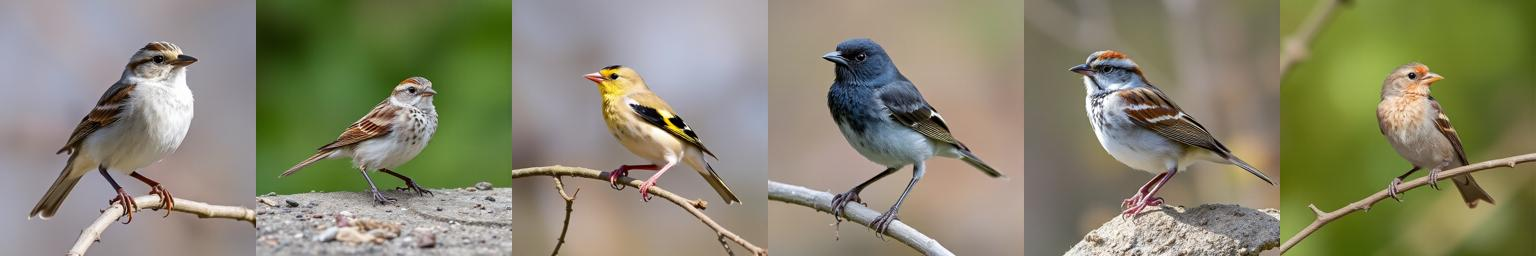

In [ ]:
STEPS = 4  # @param {type:"integer"}
IMAGES_PER_PROMPT = 1  # @param {type:"integer"}
MAX_GENERATION_PROMPTS = 12  # @param {type:"integer"}
EVAL_SEED = 0


def grid(images, path, columns=6):
    tiles = [im.resize((256, 256)) for im in images]
    rows = (len(tiles) + columns - 1) // columns
    sheet = Image.new('RGB', (256 * columns, 256 * rows), 'white')
    for i, tile in enumerate(tiles):
        sheet.paste(tile, (256 * (i % columns), 256 * (i // columns)))
    sheet.save(path)
    return path


reset_to_pretrained()
load_report = pipe.load_transformer()
print({**load_report, 'quantization': QUANTIZATION, 'parameters': count_parameters(pipe.transformer), 'lora_tensors': len(lora_parameter_names(pipe.transformer)), 'gpu_memory_gb': gpu_memory_gb()})
scorer = ClipScorer(weights_dir=SCORER_WEIGHTS_DIR, device=pipe.device)
t0 = time.perf_counter()
frozen_val = pipe.evaluate(val_records, seed=EVAL_SEED)
frozen_test = pipe.evaluate(test_records, seed=EVAL_SEED)
print({'frozen_flow_matching_mse': {'validation': frozen_val['flow_matching_mse'], 'test': frozen_test['flow_matching_mse']}, 'by_sigma_test': frozen_test['by_sigma'], 'seconds': round(time.perf_counter() - t0, 1)})

if len(prompts) > MAX_GENERATION_PROMPTS:
    print({'warning': f'{len(prompts)} distinct training captions: generating for the first {MAX_GENERATION_PROMPTS} only (each image takes several seconds per model on a T4). Raise MAX_GENERATION_PROMPTS to score more.'})
generation_prompts = [p for p in prompts[:MAX_GENERATION_PROMPTS] for _ in range(IMAGES_PER_PROMPT)]
frozen_generation = pipe.generate(generation_prompts, seed=1000, steps=STEPS)
print({'generated': len(frozen_generation['images']), 'steps': frozen_generation['steps'], 'guidance_scale': frozen_generation['guidance_scale'], 'precision': frozen_generation['precision'], 'seconds': frozen_generation['seconds'], 'adapted': frozen_generation['model']['adapted']})
frozen_scores = score_generations(scorer, frozen_generation['images'], references=test_records)
# The real held-out photographs scored the same way, LEAVE-ONE-OUT: each photo's reference is the other test photos of
# its caption, never itself. A reference line to read the generations against, not a ceiling.
real_reference = real_photo_reference(scorer, test_records)
print({'frozen_generations': {k: frozen_scores[k] for k in ('clip_prompt_similarity', 'label_accuracy', 'reference_similarity')}})
print({'real_photo_reference_leave_one_out': {k: real_reference.get(k) for k in ('clip_prompt_similarity', 'label_accuracy', 'reference_similarity')}, 'photos_without_a_reference': real_reference['n_without_reference']})
for entry in frozen_scores['per_image'][::IMAGES_PER_PROMPT]:
    print({'prompt': entry['prompt'][:42], 'clip': entry['clip_prompt_similarity'], 'nearest': entry['nearest_prompt'][13:40], 'correct': entry['correct'], 'reference_similarity': entry.get('reference_similarity')})
frozen_grid = grid([g['image'] for g in frozen_generation['images']], 'outputs/flux_schnell_generation_frozen_grid.jpg')
print({'grid': str(frozen_grid), 'columns': 'generation prompts in the order printed above', 'gpu_memory_gb': gpu_memory_gb()})
display(Image.open(frozen_grid))

## 7. Bounded QLoRA fine-tuning

**What to notice (Section 6):** the frozen generations next to the real-photo reference line, metric by metric, and the per-species rows: which birds did CLIP name correctly?

<details><summary>Check your reasoning</summary>Above, on both. In the recorded Kaggle T4 run of the previous notebook version (same model stages, 2026-09-20) the frozen generations scored prompt similarity 31.08 against the real photographs' 30.25 and reference similarity 71.95 against a leave-one-out real-photo value of 57.7, while label accuracy was 0.667 against the real photos' 0.917. That run printed 88.66 for the real photos' reference similarity because each photo was then included in its own reference; excluding it gives 57.7. So the reference line is not a ceiling on two of the three readings: the generator is conditioned on the prompt and is compared with a two-photo mean, while each photo is compared with one other photo. Label accuracy is the reading on which the frozen model sat clearly below the real photographs.</details>

`pipe.adapt` trains the 380 LoRA tensors (rank 8, 9,338,880 parameters — 0.08 % of the transformer) that `peft` attached to the image-stream query, key, value and output projections of all 57 blocks, and nothing else; the 4-bit base, the VAE and the text encoders are frozen. Each step takes one training photograph's packed latent (VAE-encoded once, seeded), draws a noise level σ uniformly from (0, 1) and a noise tensor (both seeded), mixes x_σ = (1 − σ)·x₀ + σ·ε, and minimises the MSE between the predicted velocity and ε − x₀; AdamW at a fixed learning rate on float32 LoRA masters, gradient-norm clipping at 1.0, float16 autocast with loss scaling and gradient checkpointing (the 1,280-token activations of 57 blocks would not otherwise fit). Epoch 0 records the frozen model's validation loss, and the epoch with the lowest validation flow-matching loss is kept. `reset_to_pretrained()` runs first, so re-running this cell with a different `EPOCHS` or `LEARNING_RATE` trains again from the pretrained base (`adapt` refuses to continue from an already trained adapter).

Watch the validation loss from epoch 0; three epochs over 36 images (108 steps) took 17 minutes on a T4 in the recorded Kaggle T4 run of the previous notebook version (same model stages, 2026-09-20), most of it the per-epoch validation pass. The training loss is a noisy per-step average over random noise levels and is not the quality signal — the paired held-out numbers in Section 8 are.

**Predict before running:** will the validation loss fall at every epoch? Will the training loss?

In [ ]:
EPOCHS = 3  # @param {type:"integer"}
LEARNING_RATE = 1e-4  # @param {type:"number"}
BATCH_SIZE = 1  # @param {type:"integer"}


def report(entry):
    row = {'epoch': entry['epoch'], 'train_loss': None if entry['train_loss'] is None else round(entry['train_loss'], 4), 'val_flow_matching_mse': entry['val_loss']}
    if 'note' in entry:
        row['note'] = entry['note']
    print(row)


# A re-run (an optional experiment) starts again from the pretrained base, so epoch 0 is the frozen model.
reset_to_pretrained()
t0 = time.perf_counter()
adapt_result = pipe.adapt(train_records, val_records, epochs=EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE, seed=EVAL_SEED, progress=report)
adapt_seconds = round(time.perf_counter() - t0, 1)
print({'trainable_parameters': adapt_result['n_trainable'], 'total_parameters': adapt_result['n_total'], 'steps': adapt_result['n_steps'], 'best_epoch': adapt_result['best_epoch'], 'precision': adapt_result['precision'], 'seconds': adapt_seconds, 'peak_gpu_memory_gb': round(torch.cuda.max_memory_allocated() / 1e9, 2)})

{'epoch': 0, 'train_loss': None, 'val_flow_matching_mse': 0.834244, 'note': 'frozen model (LoRA at initialisation: B = 0)'}


{'epoch': 1, 'train_loss': 0.6218, 'val_flow_matching_mse': 0.591159}


{'epoch': 2, 'train_loss': 0.665, 'val_flow_matching_mse': 0.532501}


{'epoch': 3, 'train_loss': 0.5674, 'val_flow_matching_mse': 0.523245}
{'trainable_parameters': 9338880, 'total_parameters': 11900517440, 'steps': 108, 'best_epoch': 3, 'precision': 'nf4 base, float16 autocast + GradScaler, float32 LoRA masters', 'seconds': 938.3, 'peak_gpu_memory_gb': 12.22}


## 8. Held-out evaluation: the paired comparison

**What to notice (Section 7):** the validation loss per epoch, the kept epoch and the peak GPU memory of training.

<details><summary>Check your reasoning</summary>In the recorded Kaggle T4 run of the previous notebook version (same model stages, 2026-09-20) the validation loss fell at every epoch (0.834 → 0.595 → 0.534 → 0.524) and epoch 3 was kept, while the training loss went 0.624 → 0.669 → 0.569: up, then down. Each training step draws its own random noise level, and the loss depends strongly on it (Section 6 prints the per-σ loss), so a per-epoch training average is noisy; the validation loss uses the same fixed noise every time and is the signal used to choose the epoch. Peak training memory was 12.23 GB.</details>

The test photographs were never used for training or epoch selection. The adapted model is scored exactly as the frozen model was in Section 6 — the same seed, so the same latents, noise and noise levels, and the same prompt/seed pairs for generation — and the table puts the frozen, the adapted and the real-photo reference numbers side by side. The cell asserts only what the procedure guarantees — the kept epoch's validation loss is no higher than the frozen model's (epoch 0) and the re-scored validation loss matches the history — and prints the test comparison without a directional assertion: a lower test flow-matching MSE is what to look for, not what is promised. The frozen and adapted images are displayed side by side (top row frozen, bottom row adapted; each column one prompt and seed). Six images per model from one seeded run give no dispersion estimate; these are sample-sanity numbers that show the adaptation contract works, not a benchmark, and CLIP agreement is not a human judgement of quality.

**Predict before running:** will every species' reference similarity rise after adaptation?

{'flow_matching_mse_validation': {'frozen': 0.834244, 'adapted': 0.523245}}
{'flow_matching_mse_test': {'frozen': 0.7953, 'adapted': 0.506467}}
{'flow_matching_mse_test_by_sigma': {'0.1': {'frozen': 1.072608, 'adapted': 0.724203}, '0.3': {'frozen': 0.954901, 'adapted': 0.63562}, '0.5': {'frozen': 0.749795, 'adapted': 0.479433}, '0.7': {'frozen': 0.592937, 'adapted': 0.350759}, '0.9': {'frozen': 0.606259, 'adapted': 0.34232}}}
{'clip_prompt_similarity': {'frozen': 31.078, 'adapted': 30.347, 'real_photo_reference': 30.25}}
{'label_accuracy': {'frozen': 0.6667, 'adapted': 0.6667, 'real_photo_reference': 0.9167}}
{'reference_similarity': {'frozen': 71.947, 'adapted': 71.888, 'real_photo_reference': 57.722}}
{'real_photo_reference': 'leave-one-out real-photo reference', 'reading': {'clip_prompt_similarity': 'not an upper bound: a generator conditioned on the prompt can match it more closely than a photograph does', 'label_accuracy': 'a reference: real photographs of these species are what t

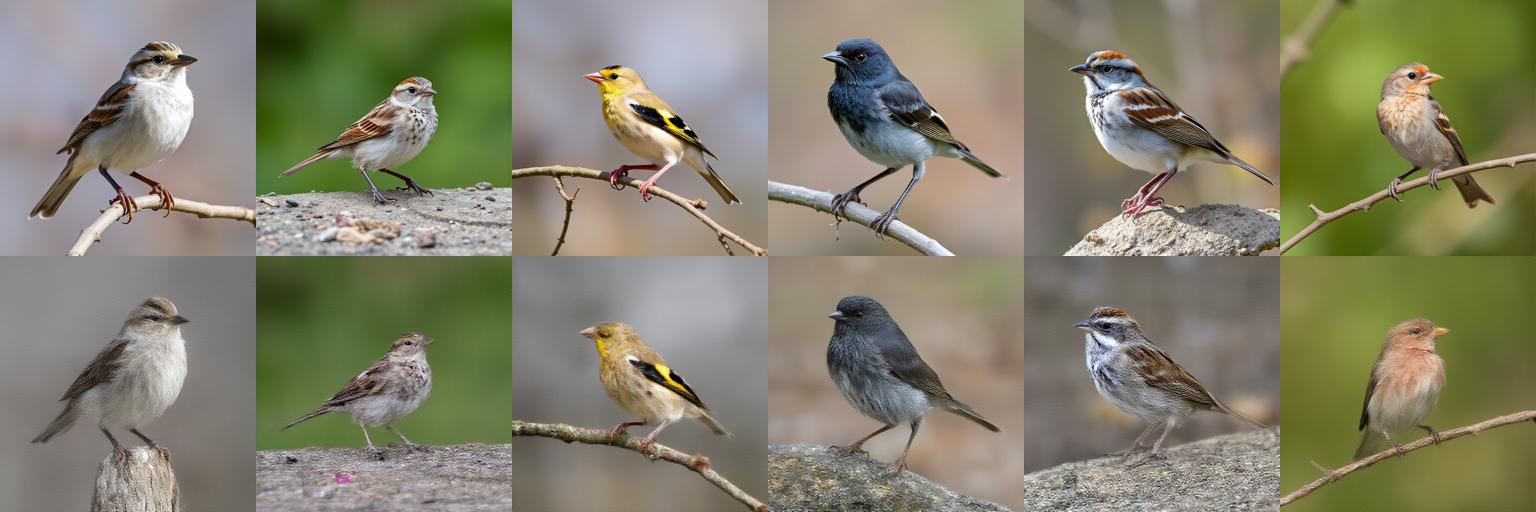

{'test_flow_matching_mse_change': -0.288833, 'note': 'held-out observation, not asserted'}
{'report': 'outputs/flux_schnell_generation_evaluation_report.json'}


In [ ]:
if pipe.adapter is None:
    raise RuntimeError('Section 8 compares the adapted model with the frozen one, and no adapted model is loaded: run Section 7 first (Section 9 releases the adapted transformer after exporting it).')
adapted_val = pipe.evaluate(val_records, seed=EVAL_SEED)
adapted_test = pipe.evaluate(test_records, seed=EVAL_SEED)
adapted_generation = pipe.generate(generation_prompts, seed=1000, steps=STEPS)
adapted_scores = score_generations(scorer, adapted_generation['images'], references=test_records)
comparison = {
    'flow_matching_mse_validation': {'frozen': frozen_val['flow_matching_mse'], 'adapted': adapted_val['flow_matching_mse']},
    'flow_matching_mse_test': {'frozen': frozen_test['flow_matching_mse'], 'adapted': adapted_test['flow_matching_mse']},
    'flow_matching_mse_test_by_sigma': {s: {'frozen': frozen_test['by_sigma'][s], 'adapted': adapted_test['by_sigma'][s]} for s in adapted_test['by_sigma']},
    'clip_prompt_similarity': {'frozen': frozen_scores['clip_prompt_similarity'], 'adapted': adapted_scores['clip_prompt_similarity'], 'real_photo_reference': real_reference['clip_prompt_similarity']},
    'label_accuracy': {'frozen': frozen_scores['label_accuracy'], 'adapted': adapted_scores['label_accuracy'], 'real_photo_reference': real_reference['label_accuracy']},
    'reference_similarity': {'frozen': frozen_scores.get('reference_similarity'), 'adapted': adapted_scores.get('reference_similarity'), 'real_photo_reference': real_reference.get('reference_similarity')},
}
for name, row in comparison.items():
    print({name: row})
print({'real_photo_reference': real_reference['reference_kind'], 'reading': real_reference['reading']})
for before, after in zip(frozen_scores['per_image'][::IMAGES_PER_PROMPT], adapted_scores['per_image'][::IMAGES_PER_PROMPT]):
    print({'prompt': before['prompt'][:42], 'reference_similarity': {'frozen': before.get('reference_similarity'), 'adapted': after.get('reference_similarity')}, 'correct': {'frozen': before['correct'], 'adapted': after['correct']}})
adapted_grid = grid([g['image'] for g in adapted_generation['images']], 'outputs/flux_schnell_generation_adapted_grid.jpg')
pair_grid = grid([g['image'] for g in frozen_generation['images']] + [g['image'] for g in adapted_generation['images']], 'outputs/flux_schnell_generation_frozen_vs_adapted.jpg', columns=len(generation_prompts))
print({'grid': str(adapted_grid), 'side_by_side': str(pair_grid), 'rows': 'top: frozen, bottom: adapted; same prompt and seed in each column'})
display(Image.open(pair_grid))
evaluation_report = {
    'model': {'id': MODEL_ID, 'revision': MODEL_REVISION, 'key': MODEL_KEY, 'staging': {'repo': STAGING_ID, 'revision': STAGING_REVISION}, 'quantization': QUANTIZATION, 'compute_dtype': pipe.compute_dtype},
    'scorer': frozen_scores['scorer'],
    'data_source': data_source,
    'dataset': dataset_report,
    'generation': {'steps': STEPS, 'guidance_scale': GUIDANCE_SCALE, 'images_per_prompt': IMAGES_PER_PROMPT, 'prompts': len(generation_prompts) // IMAGES_PER_PROMPT, 'seed': 1000},
    'frozen': {'validation': frozen_val, 'test': frozen_test, 'generations': frozen_scores},
    'adapted': {'validation': adapted_val, 'test': adapted_test, 'generations': adapted_scores},
    'real_photo_reference': real_reference,
    'comparison': comparison,
    'adaptation': {k: v for k, v in adapt_result.items() if k not in ('history', 'trainable_names')},
    'history': adapt_result['history'],
    'adaptation_seconds': adapt_seconds,
}
with open('outputs/flux_schnell_generation_evaluation_report.json', 'w', encoding='utf-8') as f:
    json.dump(evaluation_report, f, indent=2)
best = adapt_result['history'][adapt_result['best_epoch']]
assert best['val_loss'] <= adapt_result['history'][0]['val_loss']
assert abs(adapted_val['flow_matching_mse'] - best['val_loss']) < 1e-4
print({'test_flow_matching_mse_change': round(adapted_test['flow_matching_mse'] - frozen_test['flow_matching_mse'], 6), 'note': 'held-out observation, not asserted'})
print({'report': 'outputs/flux_schnell_generation_evaluation_report.json'})

## 9. A new prompt, artifact export and fresh reload

**What to notice (Section 8):** the per-species rows, not only the means — and whether the bottom row of the side-by-side grid looks more like the photographs of each species than the top row.

<details><summary>Check your reasoning</summary>Not every one. In the recorded Kaggle T4 run of the previous notebook version (same model stages, 2026-09-20) the test flow-matching MSE fell from 0.795 to 0.507 and was lower at every noise level, label accuracy rose from 0.667 to 0.833 and the mean reference similarity from 71.95 to 75.01 — but two of the six species moved the other way (Chipping Sparrow 70.24 → 68.58, Dark-eyed Junco 69.16 → 68.69). With one image per species and one seed, a single image can move a species' number either way; the paired loss on 12 photographs at five noise levels is the steadier evidence.</details>

The adapted model renders `NEW_PROMPT` — a composition that appears in no training caption — at two seeds; the CLIP prompt similarity is printed as a sanity check, not an evaluation, and both images are displayed. One more image of the first training prompt is rendered and kept for the parity check.

`pipe.save_artifact` writes the 380 trained tensors (about 37 MB in float32) as `adapter.safetensors` with a `manifest.json` recording the artifact format, the base model's id, revision, licence, staging source and quantisation, the LoRA configuration, the tensor names, the file size and SHA-256, the training configuration and the epoch history (OUT8). Two 4-bit transformers do not fit a 16 GB GPU, so the adapted pipeline then **releases** its transformer (`release_transformer`, which also forgets the adapter) before `FluxSchnellPipeline.from_artifact` re-verifies both snapshots, checks the manifest, the LoRA scope and the digest **before** deserialising, loads a fresh 4-bit transformer with the adapter attached and overlays the tensors — a new object from files, not the in-memory model (VER2). The fresh pipeline adopts the prompt embeddings already encoded (so the text encoders are not loaded again), and the cell asserts that it reproduces the held-out flow-matching loss recorded in Section 8 and the same image for the same prompt and seed (VER4: a mean absolute pixel difference below 1 on the 0..255 scale — same device, same kernels, same deterministic NF4 quantisation of the same bytes). Once parity is checked the reloaded pipeline is **released** too, so no 4-bit transformer stays resident for a later pass. The result file records the per-module SHA-256 of the carried code next to the source revision.

**Predict before running:** will the reloaded pipeline reproduce the adapted model's numbers exactly, or only closely?

{'new_prompt': 'a photo of a House Finch (Haemorhous mexicanus) perched on a snow-covered branch in winter', 'clip_prompt_similarity': 33.106, 'seconds': 13.18, 'note': 'sanity check, not an evaluation'}


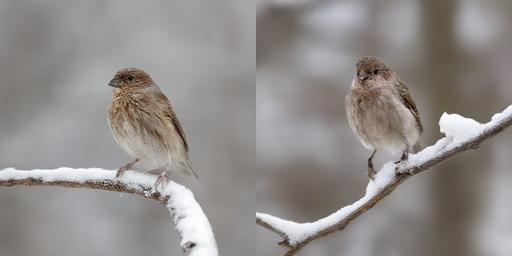

{'artifact': 'outputs/flux_schnell_generation_adapter', 'format': 'org.valcorza.flux-schnell-generation.adapter.v1', 'tensors': 380, 'bytes': 37404064, 'sha256': '738a9797daa0e6ff...', 'quantization': 'nf4'}


{'adapted_transformer_released': True, 'gpu_memory_gb': 0.96}


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:  33%|███▎      | 1/3 [00:42<01:25, 42.52s/it]

Loading checkpoint shards:  67%|██████▋   | 2/3 [01:24<00:42, 42.16s/it]

Loading checkpoint shards: 100%|██████████| 3/3 [01:41<00:00, 33.74s/it]


{'reload_parity': {'flow_matching_mse_diff': 0.0, 'mean_abs_pixel_diff': 0.0}, 'reloaded_best_epoch': 3, 'gpu_memory_gb_with_reloaded': 7.47}


{'reloaded_pipeline_released': True, 'gpu_memory_gb': 0.96}
outputs/:
  - outputs/flux_schnell_generation_adapted_grid.jpg (41.9 KB)
  - outputs/flux_schnell_generation_adapter/adapter.safetensors (36527.4 KB)
  - outputs/flux_schnell_generation_adapter/manifest.json (26.3 KB)
  - outputs/flux_schnell_generation_evaluation_report.json (19.1 KB)
  - outputs/flux_schnell_generation_frozen_grid.jpg (43.9 KB)
  - outputs/flux_schnell_generation_frozen_vs_adapted.jpg (85.2 KB)
  - outputs/flux_schnell_generation_new_prompt_0.png (280.1 KB)
  - outputs/flux_schnell_generation_new_prompt_1.png (288.4 KB)
  - outputs/flux_schnell_generation_new_prompt_grid.jpg (12.1 KB)
  - outputs/flux_schnell_generation_result.json (5.3 KB)
  - outputs/flux_schnell_generation_sample_captions.csv (2.3 KB)


In [ ]:
import platform
import shutil

if pipe.adapter is None:
    raise RuntimeError('Section 9 exports the adapted model, and no adapted model is loaded: run Section 7 (and Section 8) first.')
new_generation = pipe.generate([NEW_PROMPT, NEW_PROMPT], seed=2000, steps=STEPS)
new_scores = score_generations(scorer, new_generation['images'])
print({'new_prompt': NEW_PROMPT, 'clip_prompt_similarity': new_scores['clip_prompt_similarity'], 'seconds': new_generation['seconds'], 'note': 'sanity check, not an evaluation'})
for i, entry in enumerate(new_generation['images']):
    entry['image'].save(f'outputs/flux_schnell_generation_new_prompt_{i}.png')
display(Image.open(grid([g['image'] for g in new_generation['images']], 'outputs/flux_schnell_generation_new_prompt_grid.jpg', columns=2)))
before = pipe.generate([prompts[0]], seed=3000, steps=STEPS)['images'][0]['image']

artifact_dir = Path('outputs/flux_schnell_generation_adapter')
shutil.rmtree(artifact_dir, ignore_errors=True)
pipe.save_artifact(artifact_dir, metadata={'tutorial': 'flux_schnell_generation', 'data_source': data_source})
artifact_manifest = json.loads((artifact_dir / 'manifest.json').read_text(encoding='utf-8'))
print({'artifact': str(artifact_dir), 'format': artifact_manifest['format'], 'tensors': len(artifact_manifest['tensors']), 'bytes': artifact_manifest['files'][0]['bytes'], 'sha256': artifact_manifest['files'][0]['sha256'][:16] + '...', 'quantization': artifact_manifest['base_model']['quantization']})

print({'adapted_transformer_released': pipe.release_transformer(), 'gpu_memory_gb': gpu_memory_gb()})
reloaded = FluxSchnellPipeline.from_artifact(artifact_dir, weights_dir=WEIGHTS_DIR, device=pipe.device, prompt_cache=cache)
reloaded_test = reloaded.evaluate(test_records, seed=EVAL_SEED)
after = reloaded.generate([prompts[0]], seed=3000, steps=STEPS)['images'][0]['image']
parity = {'flow_matching_mse_diff': round(abs(reloaded_test['flow_matching_mse'] - adapted_test['flow_matching_mse']), 8), 'mean_abs_pixel_diff': round(float(np.abs(np.asarray(before, dtype=np.float32) - np.asarray(after, dtype=np.float32)).mean()), 4)}
reloaded_best_epoch = reloaded.adapter['best_epoch']
print({'reload_parity': parity, 'reloaded_best_epoch': reloaded_best_epoch, 'gpu_memory_gb_with_reloaded': gpu_memory_gb()})
assert parity['flow_matching_mse_diff'] < 1e-5 and parity['mean_abs_pixel_diff'] < 1.0
# The parity check is done: release the reloaded pipeline so nothing stays resident for a later pass (a BYOD re-run
# loads the 9.7 GB text encoders in Section 5, which do not fit beside a second 4-bit transformer on a 15 GB GPU).
reloaded.release_transformer()
del reloaded
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print({'reloaded_pipeline_released': True, 'gpu_memory_gb': gpu_memory_gb()})

result_payload = {
    'notebook_source': NOTEBOOK_SOURCE,
    'repository_revision': NOTEBOOK_SOURCE['repository_revision'],
    'module_sha256_per_file': NOTEBOOK_SOURCE['module_sha256_per_file'],
    'model': {**evaluation_report['model'], 'model_license': MODEL_LICENSE, 'device': pipe.device, 'precision': frozen_generation['precision'], 'source': pipe.source},
    'scorer': {**evaluation_report['scorer'], 'license': SCORER_LICENSE},
    'provenance': {
        'snapshots': {'model': len(MANIFEST['files']), 'scorer': len(SCORER_MANIFEST['files'])},
        'staging': MANIFEST['staging'],
        'safetensors_only': True,
        'remote_code_executed': False,
        'text_encoders_released_before_training': released,
        'transformer_loaded_after_encoding': load_report,
        'data_base_url': CORPUS_BASE_URL,
        'data_license': CORPUS_LICENSE,
    },
    'runtime': {'python': platform.python_version(), 'torch': torch.__version__, 'diffusers': diffusers.__version__, 'transformers': transformers.__version__, 'peft': peft.__version__, 'bitsandbytes': bitsandbytes.__version__, 'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None},
    'data_source': data_source,
    'comparison': comparison,
    'real_photo_reference': {'kind': real_reference['reference_kind'], 'reading': real_reference['reading']},
    'artifact': {'dir': str(artifact_dir), 'sha256': artifact_manifest['files'][0]['sha256'], 'bytes': artifact_manifest['files'][0]['bytes']},
    'reload_parity': parity,
    'reloaded_best_epoch': reloaded_best_epoch,
}
with open('outputs/flux_schnell_generation_result.json', 'w', encoding='utf-8') as f:
    json.dump(result_payload, f, indent=2)

print('outputs/:')
for path in sorted(Path('outputs').rglob('*')):
    if path.is_file():
        print(f'  - {path.as_posix()} ({path.stat().st_size / 1024:.1f} KB)')

## 10. Your turn — change one thing: the number of sampling steps

**What to notice (Section 9):** the reload parity line, the GPU memory with the reloaded pipeline and after its release, and the list of files under `outputs/`.

<details><summary>Check your reasoning</summary>Exactly, on the same runtime. In the recorded Kaggle T4 run of the previous notebook version (same model stages, 2026-09-20) both differences were 0.0: the same bytes quantised the same way, the same embeddings and the same kernels give the same arithmetic. On a different GPU, driver or library build the numbers would differ slightly, which is why parity is checked in one session. That run held 7.48 GB with the reloaded pipeline resident and did not release it; this version releases it, and the printed memory should fall back to about 1 GB (the VAE and the CLIP scorer).</details>

**Predict → Change one thing → Run → Observe → Explain.**

1. **Predict:** schnell is distilled to render in one to four steps. With one or two steps instead of four, will the CLIP prompt similarity and the label accuracy of the pretrained model's images go up, down or stay put? Write your guess down.
2. **Change one thing:** set `RUN_ACTIVITY = True` in the cell below and nothing else. It renders the same prompts with the same seed at 1, 2 and 4 steps with the **pretrained base** (an untrained LoRA; `reset_to_pretrained()` runs first).
3. **Run:** run this cell only (it loads the transformer again, a few minutes, and releases it at the end). It writes only under `outputs/activity/` and changes no earlier result.
4. **Observe:** one row per step count — prompt similarity, label accuracy, reference similarity and seconds — and a grid with one row per step count, each column one prompt.
5. **Explain:** what did fewer steps cost on each reading, what did they save in time, and how far apart must two rows be before six images make the difference believable?

<details><summary>Check your reasoning</summary>No run of this activity is recorded yet, so compare your prediction with what the cell printed rather than with a number here. Two things to check either way: the 4-step row should reproduce Section 6's frozen numbers (same model, prompts, seed and steps) when the runtime is the same, which makes it the control row; and the time should fall roughly in proportion to the steps, because every step is one pass of the 12 B transformer. Distillation is what lets few steps work at all, so a small change between rows is a plausible outcome, and with six images per row a difference of one correct label is 0.167 of label accuracy.</details>

In [ ]:
RUN_ACTIVITY = False  # @param {type:"boolean"}
ACTIVITY_STEPS = (1, 2, 4)

if not RUN_ACTIVITY:
    print('Activity not run: set RUN_ACTIVITY = True and run this cell. It writes only under outputs/activity/ and changes no earlier result.')
else:
    reset_to_pretrained()
    activity_load = pipe.load_transformer()
    activity_dir = Path('outputs/activity')
    activity_dir.mkdir(parents=True, exist_ok=True)
    activity_prompts = prompts[:MAX_GENERATION_PROMPTS]
    activity_rows = {}
    activity_images = []
    for steps in ACTIVITY_STEPS:
        generation = pipe.generate(activity_prompts, seed=1000, steps=steps)
        scores = score_generations(scorer, generation['images'], references=test_records)
        activity_rows[steps] = {'clip_prompt_similarity': scores['clip_prompt_similarity'], 'label_accuracy': scores['label_accuracy'], 'reference_similarity': scores.get('reference_similarity'), 'seconds': generation['seconds']}
        activity_images += [g['image'] for g in generation['images']]
        print({'steps': steps, **activity_rows[steps]})
    activity_grid = grid(activity_images, activity_dir / 'flux_schnell_generation_steps.jpg', columns=len(activity_prompts))
    print({'grid': str(activity_grid), 'rows': [f'{s} step(s)' for s in ACTIVITY_STEPS], 'model': 'the pretrained base (untrained LoRA)', 'real_photo_reference': {k: real_reference.get(k) for k in ('clip_prompt_similarity', 'label_accuracy', 'reference_similarity')}})
    display(Image.open(activity_grid))
    with open(activity_dir / 'flux_schnell_generation_steps.json', 'w', encoding='utf-8') as f:
        json.dump({'model': 'pretrained base, untrained LoRA', 'seed': 1000, 'prompts': activity_prompts, 'rows': activity_rows, 'load': activity_load}, f, indent=2)
    print({'activity_transformer_released': pipe.release_transformer(), 'gpu_memory_gb': gpu_memory_gb()})

Activity not run: set RUN_ACTIVITY = True and run this cell. It writes only under outputs/activity/ and changes no earlier result.


## Interpretation and limits

**What to notice (Section 10):** if you ran the activity, whether the 4-step row matches Section 6 and how the readings and the seconds changed with fewer steps.

Read your own Section 8 before concluding; the claim below is what the run is designed to test, not a result stated in advance. If the test flow-matching loss fell and the generations moved towards the held-out photographs, a LoRA of nine million parameters trained for about 17 minutes on 36 photographs over a 4-bit 12 B base has taught the rectified-flow transformer something about a narrow visual domain from a handful of captioned images on a 16 GB GPU, measured on identical inputs before and after, and the artifact that carries the change is 37 MB. Check the per-species rows: in the recorded run of the previous version two of the six species' reference similarities fell while the mean rose.

The numbers are sample-sanity evidence. A flow-matching loss is the training objective, not a quality score; CLIP similarity and CLIP's nearest-caption vote are a frozen model's opinion, not a human judgement, and CLIP itself has biases about what a species name looks like; six images per model from one seeded run give no dispersion estimate; and nothing here measures aesthetics, diversity, artefacts or prompt fidelity beyond the six captions. The real photographs are a **reference line, not a ceiling**: generated images can score above them on prompt similarity and reference similarity, so a generation that beats a photograph on a CLIP reading is not a better bird picture. Every number is the **4-bit** model's: NF4 quantisation changes the base's outputs relative to the bfloat16 checkpoint by an amount this notebook does not measure, and an adapter trained over the quantised base is meant to be served over it (the artifact manifest records `nf4`). Fine-tuning on a narrow domain can also erode the model elsewhere — the new prompt in Section 9 is a sanity check on one composition, not a test of generality.

**Pretraining overlap.** The 60 photographs are public iNaturalist images. Photographs like them — possibly these ones — may be in the web-scale data behind the LAION-2B CLIP scorer and in FLUX's undisclosed training set, so both the frozen generator's and the scorer's familiarity with these species can be inflated; nothing here measures that.

**Run-to-run variability.** The seeds fix the data split, the noise, the noise levels and the generation seeds, not the arithmetic: 4-bit matrix multiplications, attention and float16 autocast are not bit-reproducible across GPU models, drivers and library builds. A run on another runtime gives slightly different losses, images and CLIP readings — enough to flip a borderline nearest-caption vote — while reload parity within one session stays exact.

Three things to carry to real data. **Captions are the contract:** the adapter learns the association between the caption text and the images; a caption that does not describe its image, or one caption for very different images, teaches noise. **Held-out photographs, known captions:** the split is stratified within each caption, so every held-out caption also appears in training and the held-out loss measures generalisation to new photographs of known captions, not to new captions; a caption with fewer than three images is used for training only. **Licences travel with the outputs:** FLUX.1 [schnell] is Apache-2.0 and the training photographs here are CC0 — with your own data, the rights to the images and to what the adapter produces are yours to establish.

A successful default run **proves** that the pipeline modules carried in this standalone notebook (their per-module SHA-256 values are in the result file) can stage a pinned safetensors snapshot from a mirror and digest-verify it against a committed manifest, fetch and validate digest-pinned real photographs, encode prompts and release the encoders, load a 12 B transformer 4-bit, execute bounded QLoRA fine-tuning, evaluate the frozen and the adapted model on identical held-out inputs beside a leave-one-out real-photo reference, and emit the shown machine-readable artifacts — without the repository being reachable. It does **not** establish benchmark superiority, production fitness, or image quality beyond the checks shown.

**Next experiments** (each starts after the default Run all; Sections 6 and 7 always start again from the pretrained base):

1. **Sampling steps:** the Section 10 activity (`RUN_ACTIVITY = True`), run that cell only.
2. **Training length or rate:** in Section 7 set `EPOCHS` or `LEARNING_RATE`, then select Section 7 and choose **Runtime → Run after** (Sections 7–10 are recomputed; the frozen numbers of Section 6 stay valid). Watch the validation loss for the epoch where it turns.
3. **Steps for the whole comparison:** in Section 6 set `STEPS = 1` or `2`, then **Run after** from Section 6. The frozen and adapted models are both scored at that step count.
4. **A less noisy label accuracy:** in Section 6 set `IMAGES_PER_PROMPT = 2`, then **Run after** from Section 6.
5. **Your own captioned photographs:** in Section 4 set `USE_BYOD = True` (upload, or set `BYOD_PATH`), then **Run after** from Section 4. Section 5 frees the GPU first; compare the adapted numbers with your photographs' leave-one-out reference line.

## Troubleshooting

- **Section 1 stops with "needs a Linux x86_64 runtime".** The locked environment is built from manylinux wheels; use Colab, Kaggle or a Linux Jupyter server with a CUDA GPU.
- **Section 1 fails to download `uv`, Python or a package.** The runtime needs `pypi.org`, `files.pythonhosted.org` and the python-build-standalone release host. Re-run the cell; a size or SHA-256 mismatch is refused on purpose.
- **Section 3 is slow or stops while downloading.** It fetches about 34 GB from the Hub; an anonymous download can be rate-limited. Run Section 3 again: files already staged and verified are not fetched twice. A size or SHA-256 mismatch is refused; delete the named file under `weights/` and run Section 3 again.
- **"No space left on device".** The snapshots need about 36 GB and the isolated environment several more; free disk or use a runtime with more of it.
- **"The isolated environment's Python process exited".** Usually out of host or GPU memory. Restart the session and choose **Run all** again.
- **CUDA out of memory.** The encoders (Section 5) and a 4-bit transformer never fit together. Re-run from Section 5 (**Run after**), which releases every resident first; if it persists, restart the session and choose **Run all**. Keep `BATCH_SIZE = 1` on a 16 GB GPU.
- **Section 4: "Upload exactly one .zip … (got 0 files)".** The upload was cancelled or empty. Run Section 4 again and pick one zip, or set `BYOD_PATH`.
- **Section 4 refuses a BYOD dataset.** The message names the file or the rule — a member missing from the zip, an unreadable image, a side outside 256..4096 px, a missing column, or too few images for the split (six distinct images, one caption with three or more). Fix the zip and run Section 4 again.
- **Section 8 or 9: "no adapted model is loaded".** Section 9 released the adapted transformer after exporting it; run Section 7 first (**Run after** from Section 7).
- **Section 9's parity assertion fails.** The export or reload is broken; do not use that artifact. Run Sections 7–9 again.

## Glossary

- **Rectified flow / velocity:** the model learns to move a noisy latent towards a clean one along a straight line; at each step it predicts the direction and speed of that move (the *velocity*), whose target is ε − x₀.
- **Noise level σ:** how much noise is mixed in, x_σ = (1 − σ)·x₀ + σ·ε; σ = 0 is the clean latent, σ = 1 pure noise.
- **Flow-matching loss:** the mean squared error between the predicted and the target velocity; the training objective, here also measured on held-out photographs at five fixed σ.
- **Latent / VAE / packed tokens:** the VAE compresses a 512 × 512 image to a 16-channel 64 × 64 latent and decodes it back; FLUX packs 2 × 2 latent patches into 64-channel tokens.
- **Guidance distillation:** schnell was trained to produce in one to four steps without classifier-free guidance, so there is no negative prompt and the guidance scale is 0.
- **NF4 / double quantisation:** a 4-bit number format for weights (NormalFloat), with the quantisation constants themselves quantised; the transformer shrinks from 23.8 GB to about 6.6 GB.
- **LoRA / QLoRA:** low-rank matrices A and B added beside frozen weight matrices; only A and B are trained. QLoRA is LoRA trained over a quantised base.
- **CLIP prompt similarity:** the cosine (× 100) between a CLIP image embedding and the CLIP text embedding of its prompt.
- **Zero-shot label accuracy:** the share of images whose nearest caption, by CLIP cosine among the dataset's captions, is their own (an argmax, no threshold).
- **Reference similarity:** the cosine (× 100) between an image and the mean embedding of the held-out real photographs of its caption.
- **Leave-one-out reference:** the same readings on the real photographs, each compared with the others of its caption and never with itself; a reference line, not an upper bound.
- **Held-out / paired comparison:** photographs never used for training or epoch selection, scored before and after with identical latents, noise and noise levels.
- **Adapter / safetensors / reload parity:** the saved trained tensors / a code-free tensor file format / the check that base + adapter reproduces the in-memory model's loss and image.
- **Isolated environment:** the separate Python environment Section 1 builds from hash-locked packages, where every later cell runs.

## Conclusion (your notes)

Fill in from the numbers this run printed; keep each claim to what the evidence shows.

- **Task:** which photographs, which captions, which split sizes?
- **Principal result:** the test flow-matching MSE before and after, with `n` photographs and five noise levels.
- **Instrument readings:** prompt similarity, label accuracy and reference similarity, frozen and adapted, beside the leave-one-out real-photo reference line. Which reading moved, and on how many images?
- **Uncertainty or failure mode:** which species moved the other way? What did your Section 10 run change?
- **Limitations:** what does this run *not* show (see Interpretation and limits)?

## References

- Repository README: https://github.com/kurtvalcorza/flux-schnell-generation-pipeline/blob/main/README.md
- Repository model card: https://github.com/kurtvalcorza/flux-schnell-generation-pipeline/blob/main/MODEL_CARD.md
- Weights notes (identity, mirror staging, byte-identity evidence): https://github.com/kurtvalcorza/flux-schnell-generation-pipeline/blob/main/docs/WEIGHTS.md
- Hugging Face model repository (identity of record): https://huggingface.co/black-forest-labs/FLUX.1-schnell (revision `741f7c3ce8b383c54771c7003378a50191e9efe9`)
- Ungated mirror the bytes are staged from: https://huggingface.co/unsloth/FLUX.1-schnell (revision `9df3faa7ae3b6ddf0b2b69bb78616372897cc65c`)
- Black Forest Labs (2024). Announcing Black Forest Labs — FLUX.1: https://blackforestlabs.ai/announcing-black-forest-labs/ ; reference code: https://github.com/black-forest-labs/flux
- Liu, X., Gong, C., Liu, Q. (2023). Flow straight and fast: Learning to generate and transfer data with rectified flow. ICLR: https://arxiv.org/abs/2209.03003
- Sauer, A., et al. (2024). Fast high-resolution image synthesis with latent adversarial diffusion distillation: https://arxiv.org/abs/2403.12015
- Dettmers, T., et al. (2023). QLoRA: Efficient finetuning of quantized LLMs. NeurIPS: https://arxiv.org/abs/2305.14314
- Hu, E. J., et al. (2022). LoRA: Low-rank adaptation of large language models. ICLR: https://arxiv.org/abs/2106.09685
- Cherti, M., et al. (2023). Reproducible scaling laws for contrastive language-image learning. CVPR (the LAION CLIP scorer): https://arxiv.org/abs/2212.07143
- DIMER Notebook Specification 2.2 and Model Card Specification 1.1 (fleet specs in the ml-worker repository)